# 서울시 공공자전거 군집별 수요예측 모델링 및 평가

## 분석 목적

본 노트북에서는 공간 군집화 단계에서 생성한 3개 군집의 시간당 공공자전거 대여 수요를 예측한다.

각 군집의 다음 1시간 수요를 예측하는 문제로 정의하고, 다음 네 가지 모델의 성능을 비교한다.

* 일간 나이브 모델: 전일 같은 시간의 수요 사용
* 주간 나이브 모델: 전주 같은 요일·시간의 수요 사용
* 통계적 시계열 모형: SARIMA
* 머신러닝 모형: LightGBM

모든 모델은 동일한 학습·검증·테스트 기간과 동일한 예측 정보 조건에서 평가한다. 예측 시점 이전에 관측된 과거 수요와 사전에 알 수 있는 달력 정보만 사용하여 미래 정보 누출을 방지한다.

주요 분석 과정은 다음과 같다.

1. 군집별 시간대 수요 데이터의 무결성을 확인한다.
2. 수요의 시간대·요일·월별 패턴과 자기상관 구조를 분석한다.
3. 시간 순서를 유지하여 학습·검증·테스트 기간을 분할한다.
4. 일간·주간 나이브 모델을 기준선으로 평가한다.
5. 검증 데이터에서 SARIMA 후보를 비교하고 최종 설정을 선택한다.
6. 시차 변수와 달력 변수를 이용해 LightGBM을 학습하고 검증한다.
7. 검증 단계에서 확정한 설정으로 테스트 기간을 최종 평가한다.
8. RMSE와 MAE를 이용하여 모델 성능을 비교한다.
9. 최종 산출물과 데이터 누출 방지 조건을 검증한다.

주 평가 방식은 1시간 앞 순차 예측이다. 각 시점의 실제 수요는 해당 시점의 예측이 완료된 이후에만 다음 시점 예측을 위한 과거 정보로 사용한다.

기온, 강수량, 풍속과 같은 기상 변수는 최종 기본 모델에 포함하지 않는다. 미래 시점의 실제 관측 날씨를 사용하는 정보 누출을 피하고, 모든 모델을 동일한 정보 조건에서 비교하기 위해 과거 수요와 달력 정보만 사용한다.


## 1. 분석 환경 및 입력 경로 설정

모델링에 필요한 라이브러리와 프로젝트 경로를 설정한다.

공간 군집화 단계에서 생성한 다음 네 개의 필수 산출물이 존재하는지 확인한다.

* `data/processed/cluster_hourly_demand.csv`
* `data/processed/station_cluster_map.csv`
* `outputs/metrics/spatial_clustering_final_summary.csv`
* `outputs/metrics/spatial_clustering_final_validation.csv`

특히 공간 군집화 최종 검증 결과에 실패 항목이 존재하면 모델링을 중단한다. 이를 통해 앞 단계의 데이터 처리와 군집화가 정상적으로 완료된 경우에만 예측 모델을 학습하도록 한다.

또한 다음 출력 폴더를 준비한다.

* 대표 시각화: `outputs/figures/`
* 평가 지표: `outputs/metrics/`
* 상세 보고서: `outputs/reports/`
* 학습 모델: `outputs/models/`
* 예측 결과: `outputs/predictions/`

통계적 시계열 모델은 `statsmodels`의 `SARIMAX` 클래스로 구현한다. 다만 이번 프로젝트에서는 외생변수를 입력하지 않으므로 실제 모델 구조는 SARIMA이다.

코드에서는 프로젝트 내부에 기상 관련 파일이 존재하는지 참고 목적으로 탐색하지만, 기상 데이터는 필수 입력이 아니며 최종 모델 학습과 평가에도 사용하지 않는다.


In [1]:
# 1. 기본 라이브러리와 환경을 설정한다.

from pathlib import Path
import gc
import json
import os
import sys
import warnings

# 불필요한 경고를 출력하는 현상을 방지한다.
os.environ.setdefault(
    "LOKY_MAX_CPU_COUNT",
    str(os.cpu_count() or 1),
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor

    LIGHTGBM_AVAILABLE = True
    LIGHTGBM_IMPORT_ERROR = None

except Exception as error:
    LIGHTGBM_AVAILABLE = False
    LIGHTGBM_IMPORT_ERROR = str(error)


warnings.filterwarnings("ignore")


# 2. 프로젝트 루트를 탐색한다.

current_path = Path.cwd().resolve()

root_candidates = [
    current_path,
    current_path.parent,
    current_path.parent.parent,
]


ROOT = None


for candidate in root_candidates:
    if (
        (candidate / "data").exists()
        and (candidate / "notebooks").exists()
    ):
        ROOT = candidate
        break


if ROOT is None:
    raise FileNotFoundError(
        "프로젝트 루트를 찾지 못했다. "
        "notebooks 폴더에서 노트북을 실행해야 한다."
    )


# 3. 입력 및 출력 경로를 설정한다.

DATA_DIR = (
    ROOT
    / "data"
)

RAW_DIR = (
    DATA_DIR
    / "raw"
)

PROCESSED_DIR = (
    DATA_DIR
    / "processed"
)


CLUSTER_HOURLY_PATH = (
    PROCESSED_DIR
    / "cluster_hourly_demand.csv"
)

STATION_CLUSTER_MAP_PATH = (
    PROCESSED_DIR
    / "station_cluster_map.csv"
)

SPATIAL_SUMMARY_PATH = (
    ROOT
    / "outputs"
    / "metrics"
    / "spatial_clustering_final_summary.csv"
)

SPATIAL_VALIDATION_PATH = (
    ROOT
    / "outputs"
    / "metrics"
    / "spatial_clustering_final_validation.csv"
)


OUTPUTS_DIR = (
    ROOT
    / "outputs"
)

FIGURES_DIR = (
    OUTPUTS_DIR
    / "figures"
)

METRICS_DIR = (
    OUTPUTS_DIR
    / "metrics"
)

REPORTS_DIR = (
    OUTPUTS_DIR
    / "reports"
)

MODELS_DIR = (
    OUTPUTS_DIR
    / "models"
)

PREDICTIONS_DIR = (
    OUTPUTS_DIR
    / "predictions"
)


for directory in [
    OUTPUTS_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    REPORTS_DIR,
    MODELS_DIR,
    PREDICTIONS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# 4. 필수 입력 산출물의 존재 여부를 확인한다.

required_input_paths = {
    "군집별 시간대 수요": (
        CLUSTER_HOURLY_PATH
    ),
    "대여소 군집 매핑": (
        STATION_CLUSTER_MAP_PATH
    ),
    "공간 군집화 최종 요약": (
        SPATIAL_SUMMARY_PATH
    ),
    "공간 군집화 최종 검증": (
        SPATIAL_VALIDATION_PATH
    ),
}


missing_input_paths = [
    input_name
    for input_name, input_path
    in required_input_paths.items()
    if not input_path.exists()
]


if missing_input_paths:
    raise FileNotFoundError(
        "필수 모델링 입력 파일이 존재하지 않는다: "
        f"{missing_input_paths}"
    )


# 5. 공간 군집화 최종 검증 상태를 확인한다.

spatial_validation = pd.read_csv(
    SPATIAL_VALIDATION_PATH,
    encoding="utf-8-sig",
)


required_validation_columns = {
    "validation_item",
    "status",
    "passed",
}


missing_validation_columns = sorted(
    required_validation_columns
    - set(spatial_validation.columns)
)


if missing_validation_columns:
    raise KeyError(
        "공간 군집화 최종 검증 파일에 "
        "필수 컬럼이 없다: "
        f"{missing_validation_columns}"
    )


spatial_validation_status = (
    spatial_validation[
        "status"
    ]
    .astype("string")
    .str.strip()
    .str.upper()
)


spatial_validation_failed_count = int(
    spatial_validation_status
    .ne("PASS")
    .sum()
)


if spatial_validation_failed_count != 0:
    failed_items = (
        spatial_validation.loc[
            spatial_validation_status
            .ne("PASS")
        ]
        .reset_index(drop=True)
    )

    print(
        "[공간 군집화 검증 실패 항목]"
    )

    display(
        failed_items
    )

    raise ValueError(
        "공간 군집화 최종 검증에 "
        "실패한 항목이 있으므로 "
        "모델링을 진행할 수 없다."
    )


# 6. 선택적 외생변수로 활용할 기상 데이터 후보를 탐색한다.

weather_keywords = [
    "weather",
    "기상",
    "날씨",
    "temperature",
    "temp",
    "rain",
    "precipitation",
    "wind",
]


allowed_weather_extensions = {
    ".csv",
    ".xlsx",
    ".xls",
    ".parquet",
}


weather_candidate_records = []


for search_directory in [
    RAW_DIR,
    PROCESSED_DIR,
]:
    if not search_directory.exists():
        continue

    for file_path in search_directory.rglob("*"):
        if not file_path.is_file():
            continue

        if (
            file_path.suffix.lower()
            not in allowed_weather_extensions
        ):
            continue

        relative_text = str(
            file_path.relative_to(ROOT)
        )

        lowercase_text = (
            relative_text.lower()
        )

        matched_keywords = [
            keyword
            for keyword in weather_keywords
            if keyword in lowercase_text
        ]

        if not matched_keywords:
            continue

        weather_candidate_records.append(
            {
                "relative_path": relative_text,
                "extension": (
                    file_path.suffix.lower()
                ),
                "file_size_mb": round(
                    file_path.stat().st_size
                    / (1024 ** 2),
                    3,
                ),
                "matched_keywords": (
                    ", ".join(
                        matched_keywords
                    )
                ),
            }
        )


weather_candidate_files = (
    pd.DataFrame(
        weather_candidate_records
    )
)


if not weather_candidate_files.empty:
    weather_candidate_files = (
        weather_candidate_files
        .sort_values(
            [
                "relative_path",
            ]
        )
        .reset_index(drop=True)
    )


# 7. 분석 환경과 입력 파일을 출력한다.

print("[프로젝트 경로]")
print(
    f"ROOT: {ROOT}"
)
print(
    "모델링 입력 데이터: "
    f"{CLUSTER_HOURLY_PATH.relative_to(ROOT)}"
)
print(
    "모델 저장 폴더: "
    f"{MODELS_DIR.relative_to(ROOT)}"
)
print(
    "예측 결과 폴더: "
    f"{PREDICTIONS_DIR.relative_to(ROOT)}"
)


print("\n[라이브러리 버전]")
print(
    f"Python: {sys.version.split()[0]}"
)
print(
    f"pandas: {pd.__version__}"
)
print(
    f"NumPy: {np.__version__}"
)
print(
    f"scikit-learn: {sklearn.__version__}"
)
print(
    f"statsmodels: {statsmodels.__version__}"
)

if LIGHTGBM_AVAILABLE:
    print(
        f"LightGBM: {lgb.__version__}"
    )

else:
    print(
        "LightGBM: 불러오기 실패"
    )
    print(
        f"오류: {LIGHTGBM_IMPORT_ERROR}"
    )


print("\n[공간 군집화 검증 확인]")
print(
    f"전체 검증 항목: "
    f"{len(spatial_validation):,}개"
)
print(
    f"통과 항목: "
    f"{spatial_validation_status.eq('PASS').sum():,}개"
)
print(
    f"실패 항목: "
    f"{spatial_validation_failed_count:,}개"
)
print(
    "최종 상태: PASS"
)


print("\n[필수 입력 파일]")

for input_name, input_path in (
    required_input_paths.items()
):
    print(
        f"- {input_name}: "
        f"{input_path.relative_to(ROOT)}"
    )


print("\n[선택적 기상 데이터 후보 파일]")

if weather_candidate_files.empty:
    print(
        "파일명 또는 경로에서 기상 관련 "
        "후보 파일을 찾지 못했다."
    )

else:
    display(
        weather_candidate_files
    )


if not LIGHTGBM_AVAILABLE:
    raise ImportError(
        "LightGBM을 불러오지 못했다. "
        "오류 내용을 확인한 후 설치 또는 "
        "환경 설정을 수정해야 한다."
    )

[프로젝트 경로]
ROOT: C:\Users\user\Desktop\주진호\05.ICT 인턴십\02.공공자전거
모델링 입력 데이터: data\processed\cluster_hourly_demand.csv
모델 저장 폴더: outputs\models
예측 결과 폴더: outputs\predictions

[라이브러리 버전]
Python: 3.13.5
pandas: 2.2.3
NumPy: 2.1.3
scikit-learn: 1.6.1
statsmodels: 0.14.4
LightGBM: 4.6.0

[공간 군집화 검증 확인]
전체 검증 항목: 87개
통과 항목: 87개
실패 항목: 0개
최종 상태: PASS

[필수 입력 파일]
- 군집별 시간대 수요: data\processed\cluster_hourly_demand.csv
- 대여소 군집 매핑: data\processed\station_cluster_map.csv
- 공간 군집화 최종 요약: outputs\metrics\spatial_clustering_final_summary.csv
- 공간 군집화 최종 검증: outputs\metrics\spatial_clustering_final_validation.csv

[선택적 기상 데이터 후보 파일]
파일명 또는 경로에서 기상 관련 후보 파일을 찾지 못했다.


## 2. 군집별 시간대 수요 데이터 구조 확인

공간 군집화 단계에서 생성된 `cluster_hourly_demand.csv`를 모델링에 사용하기 전에 실제 데이터 구조를 확인한다.

이 단계에서는 파일을 불러온 뒤 다음 항목을 점검한다.

* 전체 행 수와 열 수
* 컬럼명과 자료형
* 결측치와 중복 행
* 수치형 변수의 기초통계량
* 시간, 군집, 수요 컬럼으로 추정되는 후보

아직 시간 컬럼, 군집 컬럼, 수요 컬럼의 이름을 임의로 가정하지 않는다. 실제 컬럼명과 값의 형태를 확인한 후 모델링에 사용할 기준 컬럼을 결정한다.

또한 이 단계에서는 데이터 변환, 파생변수 생성, 모델 학습을 수행하지 않고 입력 데이터의 구조와 품질만 확인한다.


In [2]:
# 2. 군집별 시간대 수요 데이터의 실제 구조를 확인한다.

from IPython.display import display


# 1) 군집별 시간대 수요 데이터를 불러온다.

if not CLUSTER_HOURLY_PATH.exists():
    raise FileNotFoundError(
        "군집별 시간대 수요 데이터가 존재하지 않는다: "
        f"{CLUSTER_HOURLY_PATH}"
    )


cluster_hourly_raw = pd.read_csv(
    CLUSTER_HOURLY_PATH,
    encoding="utf-8-sig",
    low_memory=False,
)


# 2) 데이터의 기본 크기와 메모리 사용량을 확인한다.

row_count = len(
    cluster_hourly_raw
)

column_count = len(
    cluster_hourly_raw.columns
)

memory_usage_mb = (
    cluster_hourly_raw
    .memory_usage(
        deep=True,
    )
    .sum()
    / (1024 ** 2)
)


print("[데이터 기본 정보]")

print(
    "파일 경로: "
    f"{CLUSTER_HOURLY_PATH.relative_to(ROOT)}"
)

print(
    f"행 수: {row_count:,}행"
)

print(
    f"열 수: {column_count:,}개"
)

print(
    f"메모리 사용량: "
    f"{memory_usage_mb:,.3f} MB"
)


# 3) 데이터 앞부분을 확인한다.

print("\n[데이터 앞부분]")

display(
    cluster_hourly_raw.head(10)
)


# 4) 컬럼별 자료형, 결측치, 고유값과 예시 값을 정리한다.

column_summary_records = []


for column_name in cluster_hourly_raw.columns:

    series = (
        cluster_hourly_raw[
            column_name
        ]
    )

    sample_values = (
        series
        .dropna()
        .astype("string")
        .drop_duplicates()
        .head(5)
        .tolist()
    )

    column_summary_records.append(
        {
            "column": column_name,
            "dtype": str(
                series.dtype
            ),
            "non_null_count": int(
                series.notna().sum()
            ),
            "missing_count": int(
                series.isna().sum()
            ),
            "missing_rate_pct": round(
                series.isna().mean()
                * 100,
                6,
            ),
            "unique_count": int(
                series.nunique(
                    dropna=True,
                )
            ),
            "sample_values": (
                " | ".join(
                    sample_values
                )
            ),
        }
    )


column_summary = pd.DataFrame(
    column_summary_records
)


print("\n[컬럼별 구조 요약]")

display(
    column_summary
)


# 5) 전체 중복 행과 완전 결측 행을 확인한다.

duplicate_row_count = int(
    cluster_hourly_raw
    .duplicated()
    .sum()
)

fully_missing_row_count = int(
    cluster_hourly_raw
    .isna()
    .all(axis=1)
    .sum()
)

columns_with_missing = int(
    cluster_hourly_raw
    .isna()
    .any()
    .sum()
)


print("\n[기본 품질 점검]")

print(
    "전체 컬럼 기준 완전 중복 행: "
    f"{duplicate_row_count:,}행"
)

print(
    "모든 값이 결측인 행: "
    f"{fully_missing_row_count:,}행"
)

print(
    "결측치가 하나 이상 존재하는 컬럼: "
    f"{columns_with_missing:,}개"
)


# 6) 수치형 컬럼의 기초통계량을 확인한다.

numeric_columns = (
    cluster_hourly_raw
    .select_dtypes(
        include=[
            np.number,
        ]
    )
    .columns
    .tolist()
)


print("\n[수치형 컬럼 기초통계량]")

print(
    f"수치형 컬럼 수: "
    f"{len(numeric_columns):,}개"
)


if numeric_columns:

    numeric_summary = (
        cluster_hourly_raw[
            numeric_columns
        ]
        .describe()
        .T
        .reset_index()
        .rename(
            columns={
                "index": "column",
            }
        )
    )

    display(
        numeric_summary
    )

else:
    print(
        "수치형으로 인식된 컬럼이 없다."
    )


# 7) 컬럼명만을 기준으로 시간, 군집, 수요 컬럼 후보를 탐색한다.
# 이 단계에서는 후보만 확인하며 실제 분석 컬럼으로 확정하지 않는다.

time_keywords = [
    "datetime",
    "timestamp",
    "date",
    "time",
    "hour",
    "일시",
    "날짜",
    "시간",
]

cluster_keywords = [
    "cluster",
    "group",
    "군집",
]

demand_keywords = [
    "demand",
    "rental",
    "rent",
    "usage",
    "count",
    "trip",
    "수요",
    "대여",
    "이용",
    "건수",
]


def find_column_candidates(
    columns,
    keywords,
):
    """
    컬럼명에 지정된 키워드가 포함된 컬럼을 탐색한다.
    """

    candidates = []

    for column_name in columns:

        lowercase_name = str(
            column_name
        ).lower()

        if any(
            keyword in lowercase_name
            for keyword in keywords
        ):
            candidates.append(
                column_name
            )

    return candidates


time_column_candidates = (
    find_column_candidates(
        cluster_hourly_raw.columns,
        time_keywords,
    )
)

cluster_column_candidates = (
    find_column_candidates(
        cluster_hourly_raw.columns,
        cluster_keywords,
    )
)

demand_column_candidates = (
    find_column_candidates(
        cluster_hourly_raw.columns,
        demand_keywords,
    )
)


print("\n[컬럼 역할 후보]")

print(
    "시간 컬럼 후보: "
    f"{time_column_candidates}"
)

print(
    "군집 컬럼 후보: "
    f"{cluster_column_candidates}"
)

print(
    "수요 컬럼 후보: "
    f"{demand_column_candidates}"
)

print(
    "\n위 결과는 컬럼명만을 이용한 후보 탐색 결과이며, "
    "아직 실제 모델링 컬럼으로 확정하지 않는다."
)

[데이터 기본 정보]
파일 경로: data\processed\cluster_hourly_demand.csv
행 수: 52,632행
열 수: 5개
메모리 사용량: 9.938 MB

[데이터 앞부분]


,datetime,cluster_id,cluster_label,rental_count,year_month
0,2023-01-01 00:00:00,0,cluster_0,641,2023-01
1,2023-01-01 00:00:00,1,cluster_1,521,2023-01
2,2023-01-01 00:00:00,2,cluster_2,399,2023-01
3,2023-01-01 01:00:00,0,cluster_0,822,2023-01
4,2023-01-01 01:00:00,1,cluster_1,440,2023-01
5,2023-01-01 01:00:00,2,cluster_2,387,2023-01
6,2023-01-01 02:00:00,0,cluster_0,515,2023-01
7,2023-01-01 02:00:00,1,cluster_1,343,2023-01
8,2023-01-01 02:00:00,2,cluster_2,288,2023-01
9,2023-01-01 03:00:00,0,cluster_0,392,2023-01



[컬럼별 구조 요약]


,column,dtype,non_null_count,missing_count,missing_rate_pct,unique_count,sample_values
0,datetime,object,52632,0,0.0,17544,2023-01-01 00:00:00 | 2023-01-01 01:00:00 | 20...
1,cluster_id,int64,52632,0,0.0,3,0 | 1 | 2
2,cluster_label,object,52632,0,0.0,3,cluster_0 | cluster_1 | cluster_2
3,rental_count,int64,52632,0,0.0,6480,641 | 521 | 399 | 822 | 440
4,year_month,object,52632,0,0.0,24,2023-01 | 2023-02 | 2023-03 | 2023-04 | 2023-05



[기본 품질 점검]
전체 컬럼 기준 완전 중복 행: 0행
모든 값이 결측인 행: 0행
결측치가 하나 이상 존재하는 컬럼: 0개

[수치형 컬럼 기초통계량]
수치형 컬럼 수: 2개


,column,count,mean,std,min,25%,50%,75%,max
0,cluster_id,52632.0,1.000000,0.816504,0.0,0.0,1.0,2.0,2.0
1,rental_count,52632.0,1685.455179,1561.367558,7.0,500.0,1290.0,2346.0,12325.0



[컬럼 역할 후보]
시간 컬럼 후보: ['datetime']
군집 컬럼 후보: ['cluster_id', 'cluster_label']
수요 컬럼 후보: ['rental_count']

위 결과는 컬럼명만을 이용한 후보 탐색 결과이며, 아직 실제 모델링 컬럼으로 확정하지 않는다.


## 3. 시간 연속성과 군집별 수요 데이터 무결성 검증

군집별 시간대 수요 데이터의 기본 구조가 확인되었으므로, 모델링에 앞서 시계열 데이터의 무결성을 검증한다.

분석 기간은 2023년 1월 1일 00시부터 2024년 12월 31일 23시까지이며, 해당 기간은 총 17,544시간으로 구성된다. 최종 군집 수가 3개이므로 정상적인 데이터라면 각 시간마다 세 개 군집의 관측값이 존재하고 전체 행 수는 52,632행이어야 한다.

이 단계에서는 다음 항목을 확인한다.

* `datetime` 컬럼의 날짜·시간 형식 변환 가능 여부
* 실제 최소·최대 시점과 목표 분석 기간의 일치 여부
* 전체 시간대의 1시간 간격 연속성
* 각 군집의 관측 시간 수가 17,544개인지 여부
* `datetime`과 `cluster_id` 조합의 중복 여부
* 각 시간대에 정확히 3개 군집이 존재하는지 여부
* 군집 번호와 군집 라벨의 일관성
* 수요값의 결측치, 음수, 비정상 자료형 여부
* 전체 및 군집별 이용건수 합계
* 이전 공간 군집화 단계에서 산출한 이용건수와의 일치 여부

검증 과정에서는 원본 데이터를 직접 수정하지 않고 복사본을 사용한다. 모든 검증 결과를 확인한 후 모델링용 시계열 데이터의 기준 컬럼과 정렬 순서를 확정한다.


In [3]:
# 3. 시간 연속성과 군집별 수요 데이터 무결성을 검증한다.

from IPython.display import display

# 1) 검증용 복사본을 생성한다.
# 원본 데이터 cluster_hourly_raw은 변경하지 않는다.

cluster_hourly_check = (
    cluster_hourly_raw
    .copy()
)


# 2) 모델링 기준값을 설정한다.
# 분석 기간과 군집 수는 이전 단계에서 확정된 값을 사용한다.

EXPECTED_START = pd.Timestamp(
    "2023-01-01 00:00:00"
)

EXPECTED_END = pd.Timestamp(
    "2024-12-31 23:00:00"
)

EXPECTED_CLUSTER_IDS = [
    0,
    1,
    2,
]

EXPECTED_CLUSTER_COUNT = len(
    EXPECTED_CLUSTER_IDS
)

EXPECTED_TOTAL_DEMAND = 88_708_877

EXPECTED_CLUSTER_DEMAND = {
    0: 42_011_493,
    1: 22_855_516,
    2: 23_841_868,
}


expected_datetimes = pd.date_range(
    start=EXPECTED_START,
    end=EXPECTED_END,
    freq="h",
)

EXPECTED_HOUR_COUNT = len(
    expected_datetimes
)

EXPECTED_ROW_COUNT = (
    EXPECTED_HOUR_COUNT
    * EXPECTED_CLUSTER_COUNT
)


print("[모델링 기준값]")

print(
    f"목표 분석 시작 시점: "
    f"{EXPECTED_START}"
)

print(
    f"목표 분석 종료 시점: "
    f"{EXPECTED_END}"
)

print(
    f"목표 시간 수: "
    f"{EXPECTED_HOUR_COUNT:,}시간"
)

print(
    f"목표 군집 수: "
    f"{EXPECTED_CLUSTER_COUNT:,}개"
)

print(
    f"목표 행 수: "
    f"{EXPECTED_ROW_COUNT:,}행"
)


# 3) datetime과 rental_count의 형식을 안전하게 변환한다.
# 변환할 수 없는 값은 NaT 또는 NaN으로 처리하여
# 변환 실패 건수를 별도로 확인한다.

cluster_hourly_check[
    "datetime_parsed"
] = pd.to_datetime(
    cluster_hourly_check[
        "datetime"
    ],
    errors="coerce",
)

cluster_hourly_check[
    "rental_count_numeric"
] = pd.to_numeric(
    cluster_hourly_check[
        "rental_count"
    ],
    errors="coerce",
)


datetime_parse_failure_count = int(
    cluster_hourly_check[
        "datetime_parsed"
    ]
    .isna()
    .sum()
)

rental_parse_failure_count = int(
    cluster_hourly_check[
        "rental_count_numeric"
    ]
    .isna()
    .sum()
)


print("\n[형식 변환 결과]")

print(
    "datetime 변환 실패: "
    f"{datetime_parse_failure_count:,}건"
)

print(
    "rental_count 숫자 변환 실패: "
    f"{rental_parse_failure_count:,}건"
)


# 4) 유효한 시점과 실제 분석 기간을 확인한다.

valid_datetime_data = (
    cluster_hourly_check
    .loc[
        cluster_hourly_check[
            "datetime_parsed"
        ]
        .notna()
    ]
    .copy()
)


actual_start = (
    valid_datetime_data[
        "datetime_parsed"
    ]
    .min()
)

actual_end = (
    valid_datetime_data[
        "datetime_parsed"
    ]
    .max()
)

actual_unique_hour_count = int(
    valid_datetime_data[
        "datetime_parsed"
    ]
    .nunique()
)


print("\n[실제 시간 범위]")

print(
    f"실제 시작 시점: "
    f"{actual_start}"
)

print(
    f"실제 종료 시점: "
    f"{actual_end}"
)

print(
    f"고유 시간 수: "
    f"{actual_unique_hour_count:,}시간"
)


# 5) 전체 시간대의 누락과 초과 시점을 확인한다.

actual_datetime_index = pd.DatetimeIndex(
    valid_datetime_data[
        "datetime_parsed"
    ]
    .drop_duplicates()
    .sort_values()
)

missing_datetimes = (
    expected_datetimes
    .difference(
        actual_datetime_index
    )
)

unexpected_datetimes = (
    actual_datetime_index
    .difference(
        expected_datetimes
    )
)


print("\n[전체 시간 연속성]")

print(
    f"누락된 시간: "
    f"{len(missing_datetimes):,}개"
)

print(
    f"목표 기간 밖의 시간: "
    f"{len(unexpected_datetimes):,}개"
)


if len(missing_datetimes) > 0:
    print(
        "누락 시간 예시:"
    )

    display(
        pd.DataFrame(
            {
                "missing_datetime": (
                    missing_datetimes[:20]
                ),
            }
        )
    )


if len(unexpected_datetimes) > 0:
    print(
        "목표 기간 밖 시간 예시:"
    )

    display(
        pd.DataFrame(
            {
                "unexpected_datetime": (
                    unexpected_datetimes[:20]
                ),
            }
        )
    )


# 6) datetime과 cluster_id 조합의 중복 여부를 확인한다.

duplicate_key_mask = (
    valid_datetime_data
    .duplicated(
        subset=[
            "datetime_parsed",
            "cluster_id",
        ],
        keep=False,
    )
)

duplicate_key_rows = (
    valid_datetime_data
    .loc[
        duplicate_key_mask,
        [
            "datetime",
            "datetime_parsed",
            "cluster_id",
            "cluster_label",
            "rental_count",
        ],
    ]
    .sort_values(
        [
            "datetime_parsed",
            "cluster_id",
        ]
    )
)

duplicate_key_count = int(
    valid_datetime_data
    .duplicated(
        subset=[
            "datetime_parsed",
            "cluster_id",
        ]
    )
    .sum()
)


print("\n[시간 × 군집 키 중복 점검]")

print(
    "datetime과 cluster_id 조합 중복: "
    f"{duplicate_key_count:,}건"
)


if not duplicate_key_rows.empty:
    display(
        duplicate_key_rows.head(20)
    )


# 7) 각 시간대에 정확히 3개 군집이 존재하는지 확인한다.

cluster_count_by_datetime = (
    valid_datetime_data
    .groupby(
        "datetime_parsed"
    )[
        "cluster_id"
    ]
    .nunique()
    .rename(
        "cluster_count"
    )
    .reset_index()
)


invalid_datetime_cluster_counts = (
    cluster_count_by_datetime
    .loc[
        cluster_count_by_datetime[
            "cluster_count"
        ]
        .ne(
            EXPECTED_CLUSTER_COUNT
        )
    ]
    .reset_index(
        drop=True
    )
)


print("\n[시간대별 군집 수 점검]")

print(
    "군집 수가 3개가 아닌 시간대: "
    f"{len(invalid_datetime_cluster_counts):,}개"
)


if not invalid_datetime_cluster_counts.empty:
    display(
        invalid_datetime_cluster_counts.head(20)
    )


# 8) 군집별 관측 시간 수와 누락 시점을 확인한다.

cluster_observation_summary = (
    valid_datetime_data
    .groupby(
        [
            "cluster_id",
            "cluster_label",
        ],
        as_index=False,
    )
    .agg(
        observation_count=(
            "datetime_parsed",
            "size",
        ),
        unique_hour_count=(
            "datetime_parsed",
            "nunique",
        ),
        start_datetime=(
            "datetime_parsed",
            "min",
        ),
        end_datetime=(
            "datetime_parsed",
            "max",
        ),
    )
)


cluster_observation_summary[
    "expected_hour_count"
] = EXPECTED_HOUR_COUNT

cluster_observation_summary[
    "missing_hour_count"
] = (
    EXPECTED_HOUR_COUNT
    - cluster_observation_summary[
        "unique_hour_count"
    ]
)


print("\n[군집별 관측 시간 요약]")

display(
    cluster_observation_summary
)


# 9) 군집 번호와 군집 라벨의 대응 관계를 확인한다.

cluster_id_to_label_count = (
    valid_datetime_data
    .groupby(
        "cluster_id"
    )[
        "cluster_label"
    ]
    .nunique()
)

cluster_label_to_id_count = (
    valid_datetime_data
    .groupby(
        "cluster_label"
    )[
        "cluster_id"
    ]
    .nunique()
)


invalid_cluster_id_mapping_count = int(
    cluster_id_to_label_count
    .ne(1)
    .sum()
)

invalid_cluster_label_mapping_count = int(
    cluster_label_to_id_count
    .ne(1)
    .sum()
)


cluster_mapping = (
    valid_datetime_data[
        [
            "cluster_id",
            "cluster_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "cluster_id",
            "cluster_label",
        ]
    )
    .reset_index(
        drop=True
    )
)


print("\n[군집 번호와 라벨 대응 관계]")

display(
    cluster_mapping
)

print(
    "하나의 cluster_id가 여러 라벨과 연결된 경우: "
    f"{invalid_cluster_id_mapping_count:,}개"
)

print(
    "하나의 cluster_label이 여러 번호와 연결된 경우: "
    f"{invalid_cluster_label_mapping_count:,}개"
)


# 10) year_month와 datetime의 일치 여부를 확인한다.

derived_year_month = (
    valid_datetime_data[
        "datetime_parsed"
    ]
    .dt
    .to_period(
        "M"
    )
    .astype(
        "string"
    )
)

year_month_mismatch_mask = (
    valid_datetime_data[
        "year_month"
    ]
    .astype(
        "string"
    )
    .ne(
        derived_year_month
    )
)

year_month_mismatch_count = int(
    year_month_mismatch_mask
    .sum()
)


print("\n[연월 정보 일치 점검]")

print(
    "datetime과 year_month가 일치하지 않는 행: "
    f"{year_month_mismatch_count:,}행"
)


if year_month_mismatch_count > 0:
    display(
        valid_datetime_data.loc[
            year_month_mismatch_mask,
            [
                "datetime",
                "year_month",
                "datetime_parsed",
            ],
        ]
        .head(20)
    )


# 11) 수요값의 결측치, 음수, 정수 여부를 확인한다.

rental_missing_count = int(
    cluster_hourly_check[
        "rental_count_numeric"
    ]
    .isna()
    .sum()
)

negative_rental_count = int(
    cluster_hourly_check[
        "rental_count_numeric"
    ]
    .lt(0)
    .sum()
)

non_integer_rental_count = int(
    (
        cluster_hourly_check[
            "rental_count_numeric"
        ]
        .dropna()
        % 1
    )
    .ne(0)
    .sum()
)

zero_rental_count = int(
    cluster_hourly_check[
        "rental_count_numeric"
    ]
    .eq(0)
    .sum()
)


print("\n[수요값 품질 점검]")

print(
    f"수요 결측치: "
    f"{rental_missing_count:,}건"
)

print(
    f"음수 수요: "
    f"{negative_rental_count:,}건"
)

print(
    f"정수가 아닌 수요: "
    f"{non_integer_rental_count:,}건"
)

print(
    f"수요가 0인 시간×군집 관측값: "
    f"{zero_rental_count:,}건"
)


# 12) 전체 및 군집별 이용건수 합계를 검증한다.

actual_total_demand = int(
    cluster_hourly_check[
        "rental_count_numeric"
    ]
    .sum()
)


cluster_demand_summary = (
    cluster_hourly_check
    .groupby(
        [
            "cluster_id",
            "cluster_label",
        ],
        as_index=False,
    )
    .agg(
        actual_demand=(
            "rental_count_numeric",
            "sum",
        )
    )
)


cluster_demand_summary[
    "actual_demand"
] = (
    cluster_demand_summary[
        "actual_demand"
    ]
    .astype(
        "int64"
    )
)

cluster_demand_summary[
    "expected_demand"
] = (
    cluster_demand_summary[
        "cluster_id"
    ]
    .map(
        EXPECTED_CLUSTER_DEMAND
    )
)

cluster_demand_summary[
    "difference"
] = (
    cluster_demand_summary[
        "actual_demand"
    ]
    - cluster_demand_summary[
        "expected_demand"
    ]
)

cluster_demand_summary[
    "match"
] = (
    cluster_demand_summary[
        "difference"
    ]
    .eq(0)
)


print("\n[전체 이용건수 합계]")

print(
    f"이전 단계 확인값: "
    f"{EXPECTED_TOTAL_DEMAND:,}건"
)

print(
    f"현재 데이터 합계: "
    f"{actual_total_demand:,}건"
)

print(
    f"차이: "
    f"{actual_total_demand - EXPECTED_TOTAL_DEMAND:,}건"
)


print("\n[군집별 이용건수 합계]")

display(
    cluster_demand_summary
)


# 13) 전체 검증 결과를 하나의 표로 정리한다.

actual_cluster_ids = sorted(
    valid_datetime_data[
        "cluster_id"
    ]
    .dropna()
    .unique()
    .tolist()
)


validation_records = [
    {
        "validation_item": "전체 행 수",
        "expected": EXPECTED_ROW_COUNT,
        "actual": len(cluster_hourly_check),
        "status": (
            "PASS"
            if len(cluster_hourly_check)
            == EXPECTED_ROW_COUNT
            else "FAIL"
        ),
    },
    {
        "validation_item": "datetime 변환 실패",
        "expected": 0,
        "actual": datetime_parse_failure_count,
        "status": (
            "PASS"
            if datetime_parse_failure_count == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "rental_count 변환 실패",
        "expected": 0,
        "actual": rental_parse_failure_count,
        "status": (
            "PASS"
            if rental_parse_failure_count == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "분석 시작 시점",
        "expected": str(EXPECTED_START),
        "actual": str(actual_start),
        "status": (
            "PASS"
            if actual_start == EXPECTED_START
            else "FAIL"
        ),
    },
    {
        "validation_item": "분석 종료 시점",
        "expected": str(EXPECTED_END),
        "actual": str(actual_end),
        "status": (
            "PASS"
            if actual_end == EXPECTED_END
            else "FAIL"
        ),
    },
    {
        "validation_item": "고유 시간 수",
        "expected": EXPECTED_HOUR_COUNT,
        "actual": actual_unique_hour_count,
        "status": (
            "PASS"
            if actual_unique_hour_count
            == EXPECTED_HOUR_COUNT
            else "FAIL"
        ),
    },
    {
        "validation_item": "누락 시간 수",
        "expected": 0,
        "actual": len(missing_datetimes),
        "status": (
            "PASS"
            if len(missing_datetimes) == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "목표 기간 밖 시간 수",
        "expected": 0,
        "actual": len(unexpected_datetimes),
        "status": (
            "PASS"
            if len(unexpected_datetimes) == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "시간×군집 중복 키",
        "expected": 0,
        "actual": duplicate_key_count,
        "status": (
            "PASS"
            if duplicate_key_count == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "시간대별 군집 수 오류",
        "expected": 0,
        "actual": len(
            invalid_datetime_cluster_counts
        ),
        "status": (
            "PASS"
            if len(
                invalid_datetime_cluster_counts
            ) == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "군집 ID 구성",
        "expected": str(
            EXPECTED_CLUSTER_IDS
        ),
        "actual": str(
            actual_cluster_ids
        ),
        "status": (
            "PASS"
            if actual_cluster_ids
            == EXPECTED_CLUSTER_IDS
            else "FAIL"
        ),
    },
    {
        "validation_item": "군집 ID-라벨 대응 오류",
        "expected": 0,
        "actual": (
            invalid_cluster_id_mapping_count
            + invalid_cluster_label_mapping_count
        ),
        "status": (
            "PASS"
            if (
                invalid_cluster_id_mapping_count
                + invalid_cluster_label_mapping_count
            ) == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "year_month 불일치",
        "expected": 0,
        "actual": year_month_mismatch_count,
        "status": (
            "PASS"
            if year_month_mismatch_count == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "수요 결측치",
        "expected": 0,
        "actual": rental_missing_count,
        "status": (
            "PASS"
            if rental_missing_count == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "음수 수요",
        "expected": 0,
        "actual": negative_rental_count,
        "status": (
            "PASS"
            if negative_rental_count == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "정수가 아닌 수요",
        "expected": 0,
        "actual": non_integer_rental_count,
        "status": (
            "PASS"
            if non_integer_rental_count == 0
            else "FAIL"
        ),
    },
    {
        "validation_item": "전체 이용건수 합계",
        "expected": EXPECTED_TOTAL_DEMAND,
        "actual": actual_total_demand,
        "status": (
            "PASS"
            if actual_total_demand
            == EXPECTED_TOTAL_DEMAND
            else "FAIL"
        ),
    },
    {
        "validation_item": "군집별 이용건수 합계",
        "expected": "모든 군집 일치",
        "actual": (
            f"{int(cluster_demand_summary['match'].sum())}"
            f"/{len(cluster_demand_summary)}개 일치"
        ),
        "status": (
            "PASS"
            if cluster_demand_summary[
                "match"
            ]
            .all()
            else "FAIL"
        ),
    },
]


demand_integrity_validation = pd.DataFrame(
    validation_records
)


failed_validation_count = int(
    demand_integrity_validation[
        "status"
    ]
    .ne(
        "PASS"
    )
    .sum()
)


print("\n[최종 무결성 검증 결과]")

display(
    demand_integrity_validation
)

print(
    f"전체 검증 항목: "
    f"{len(demand_integrity_validation):,}개"
)

print(
    "통과 항목: "
    f"{demand_integrity_validation['status'].eq('PASS').sum():,}개"
)

print(
    f"실패 항목: "
    f"{failed_validation_count:,}개"
)


if failed_validation_count == 0:
    print(
        "최종 상태: PASS"
    )

    print(
        "군집별 시간대 수요 데이터는 "
        "모델링 입력 자료로 사용할 수 있다."
    )

else:
    print(
        "최종 상태: FAIL"
    )

    print(
        "실패 항목의 원인을 확인하기 전에는 "
        "다음 모델링 단계로 진행하지 않는다."
    )

[모델링 기준값]
목표 분석 시작 시점: 2023-01-01 00:00:00
목표 분석 종료 시점: 2024-12-31 23:00:00
목표 시간 수: 17,544시간
목표 군집 수: 3개
목표 행 수: 52,632행

[형식 변환 결과]
datetime 변환 실패: 0건
rental_count 숫자 변환 실패: 0건

[실제 시간 범위]
실제 시작 시점: 2023-01-01 00:00:00
실제 종료 시점: 2024-12-31 23:00:00
고유 시간 수: 17,544시간

[전체 시간 연속성]
누락된 시간: 0개
목표 기간 밖의 시간: 0개

[시간 × 군집 키 중복 점검]
datetime과 cluster_id 조합 중복: 0건

[시간대별 군집 수 점검]
군집 수가 3개가 아닌 시간대: 0개

[군집별 관측 시간 요약]


,cluster_id,cluster_label,observation_count,unique_hour_count,start_datetime,end_datetime,expected_hour_count,missing_hour_count
0,0,cluster_0,17544,17544,2023-01-01,2024-12-31 23:00:00,17544,0
1,1,cluster_1,17544,17544,2023-01-01,2024-12-31 23:00:00,17544,0
2,2,cluster_2,17544,17544,2023-01-01,2024-12-31 23:00:00,17544,0



[군집 번호와 라벨 대응 관계]


,cluster_id,cluster_label
0,0,cluster_0
1,1,cluster_1
2,2,cluster_2


하나의 cluster_id가 여러 라벨과 연결된 경우: 0개
하나의 cluster_label이 여러 번호와 연결된 경우: 0개

[연월 정보 일치 점검]
datetime과 year_month가 일치하지 않는 행: 0행

[수요값 품질 점검]
수요 결측치: 0건
음수 수요: 0건
정수가 아닌 수요: 0건
수요가 0인 시간×군집 관측값: 0건

[전체 이용건수 합계]
이전 단계 확인값: 88,708,877건
현재 데이터 합계: 88,708,877건
차이: 0건

[군집별 이용건수 합계]


,cluster_id,cluster_label,actual_demand,expected_demand,difference,match
0,0,cluster_0,42011493,42011493,0,True
1,1,cluster_1,22855516,22855516,0,True
2,2,cluster_2,23841868,23841868,0,True



[최종 무결성 검증 결과]


,validation_item,expected,actual,status
0,전체 행 수,52632,52632,PASS
1,datetime 변환 실패,0,0,PASS
2,rental_count 변환 실패,0,0,PASS
3,분석 시작 시점,2023-01-01 00:00:00,2023-01-01 00:00:00,PASS
4,분석 종료 시점,2024-12-31 23:00:00,2024-12-31 23:00:00,PASS
5,고유 시간 수,17544,17544,PASS
6,누락 시간 수,0,0,PASS
7,목표 기간 밖 시간 수,0,0,PASS
8,시간×군집 중복 키,0,0,PASS
9,시간대별 군집 수 오류,0,0,PASS


전체 검증 항목: 18개
통과 항목: 18개
실패 항목: 0개
최종 상태: PASS
군집별 시간대 수요 데이터는 모델링 입력 자료로 사용할 수 있다.


## 4. 모델링 범위 및 외생변수 활용 기준 설정

군집별 시간대 수요 데이터의 무결성 검증을 완료했으므로, 기준모델·SARIMA·LightGBM을 비교하기 위한 모델링 범위를 설정한다.

본 프로젝트의 예측 대상은 각 공간 군집의 다음 1시간 공공자전거 대여 수요이다. 모든 모델은 동일한 학습·검증·테스트 기간과 동일한 정보 조건에서 평가한다.

예측에 사용하는 정보는 다음과 같다.

* 군집 정보: `cluster_id`
* 달력 정보: `hour`, `weekday`, `month`, `is_weekend`
* 단기 시차: `lag_1`, `lag_2`, `lag_3`
* 일간 시차: `lag_24`, `lag_48`
* 주간 시차: `lag_168`

모든 시차 변수는 예측 대상 시점보다 이전에 관측된 실제 수요만 사용한다. 예측 시점 이후의 수요값이나 테스트 기간 전체의 통계량은 입력 변수 생성에 사용하지 않는다.

통계적 시계열 모델인 SARIMA는 군집별 수요 시계열과 24시간 계절 주기를 사용한다. LightGBM은 세 군집의 데이터를 결합한 하나의 모델로 학습하며, 군집 번호와 달력 변수, 과거 수요 시차를 입력 변수로 사용한다.

기온, 강수량, 풍속과 같은 기상 변수는 최종 모델에 포함하지 않는다. 실제 운영 시 미래의 관측 날씨는 사전에 알 수 없으며, 이를 그대로 사용할 경우 미래 정보 누출이 발생할 수 있기 때문이다.

기상예보 데이터를 별도로 구축할 수도 있지만, 이번 프로젝트에서는 모델 간 기본 예측 성능을 동일한 정보 조건에서 비교하는 데 집중한다. 따라서 모든 최종 모델은 과거 수요와 사전에 알 수 있는 달력 정보만 사용한다.


In [4]:
# 4. 모델링 범위와 입력정보 활용 기준을 설정한다.


# 1) 이전 단계의 데이터 무결성 검증 결과를 확인한다.
# 검증에 실패한 항목이 있으면 모델링 기준 데이터를 생성하지 않는다.

if "demand_integrity_validation" not in globals():
    raise NameError(
        "수요 데이터 무결성 검증 결과가 존재하지 않는다. "
        "이전 검증 셀을 먼저 실행해야 한다."
    )


failed_integrity_count = int(
    demand_integrity_validation[
        "status"
    ]
    .astype("string")
    .str.strip()
    .str.upper()
    .ne("PASS")
    .sum()
)


if failed_integrity_count != 0:
    failed_integrity_items = (
        demand_integrity_validation
        .loc[
            demand_integrity_validation[
                "status"
            ]
            .astype("string")
            .str.strip()
            .str.upper()
            .ne("PASS")
        ]
        .reset_index(drop=True)
    )

    print(
        "[수요 데이터 무결성 검증 실패 항목]"
    )

    display(
        failed_integrity_items
    )

    raise ValueError(
        "수요 데이터 무결성 검증에 실패한 항목이 있어 "
        "모델링 기준 데이터를 생성할 수 없다."
    )


# 2) 모델링 기준 컬럼을 확정한다.
# 앞선 구조 점검을 통해 실제 컬럼명이 확인되었으므로
# 시간, 군집, 수요 컬럼을 명시적으로 설정한다.

DATETIME_COLUMN = "datetime"
CLUSTER_ID_COLUMN = "cluster_id"
CLUSTER_LABEL_COLUMN = "cluster_label"
TARGET_COLUMN = "rental_count"


MODELING_COLUMNS = [
    DATETIME_COLUMN,
    CLUSTER_ID_COLUMN,
    CLUSTER_LABEL_COLUMN,
    TARGET_COLUMN,
]


missing_modeling_columns = sorted(
    set(MODELING_COLUMNS)
    - set(cluster_hourly_raw.columns)
)


if missing_modeling_columns:
    raise KeyError(
        "모델링 기준 데이터에 필요한 컬럼이 없다: "
        f"{missing_modeling_columns}"
    )


# 3) 모델링 기준 데이터 복사본을 생성한다.
# 원본 데이터는 변경하지 않는다.
# datetime은 날짜·시간형으로 변환하고,
# 수요는 정수형으로 확정한 뒤 시간순으로 정렬한다.

modeling_base = (
    cluster_hourly_raw[
        MODELING_COLUMNS
    ]
    .copy()
)


modeling_base[
    DATETIME_COLUMN
] = pd.to_datetime(
    modeling_base[
        DATETIME_COLUMN
    ],
    errors="raise",
)


modeling_base[
    CLUSTER_ID_COLUMN
] = pd.to_numeric(
    modeling_base[
        CLUSTER_ID_COLUMN
    ],
    errors="raise",
).astype(
    "int64"
)


modeling_base[
    TARGET_COLUMN
] = pd.to_numeric(
    modeling_base[
        TARGET_COLUMN
    ],
    errors="raise",
).astype(
    "int64"
)


modeling_base[
    CLUSTER_LABEL_COLUMN
] = (
    modeling_base[
        CLUSTER_LABEL_COLUMN
    ]
    .astype("string")
)


modeling_base = (
    modeling_base
    .sort_values(
        [
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
        ]
    )
    .reset_index(drop=True)
)


# 4) 모델링 기준 데이터의 정렬과 구조를 재확인한다.

modeling_duplicate_key_count = int(
    modeling_base
    .duplicated(
        subset=[
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
        ]
    )
    .sum()
)


modeling_missing_count = int(
    modeling_base
    .isna()
    .sum()
    .sum()
)


modeling_negative_target_count = int(
    modeling_base[
        TARGET_COLUMN
    ]
    .lt(0)
    .sum()
)


is_time_sorted = bool(
    modeling_base[
        [
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
        ]
    ]
    .equals(
        modeling_base[
            [
                DATETIME_COLUMN,
                CLUSTER_ID_COLUMN,
            ]
        ]
        .sort_values(
            [
                DATETIME_COLUMN,
                CLUSTER_ID_COLUMN,
            ]
        )
        .reset_index(drop=True)
    )
)


if modeling_duplicate_key_count != 0:
    raise ValueError(
        "모델링 기준 데이터에 "
        "datetime과 cluster_id 중복 키가 존재한다."
    )


if modeling_missing_count != 0:
    raise ValueError(
        "모델링 기준 데이터에 결측치가 존재한다."
    )


if modeling_negative_target_count != 0:
    raise ValueError(
        "모델링 기준 데이터에 음수 수요가 존재한다."
    )


if not is_time_sorted:
    raise ValueError(
        "모델링 기준 데이터가 시간순으로 정렬되지 않았다."
    )


# 5) 모델별 입력정보 활용 원칙을 정의한다.

# known_at_prediction_time:
# 실제 예측 시점에 해당 정보를 미리 알 수 있는지를 의미한다.
#
# basic_model_included:
# 본 프로젝트의 기본 모델에 포함할 정보인지를 의미한다.
#
# 구체적인 lag와 rolling 기간은 다음 EDA 결과를 확인한 뒤 결정한다.

feature_policy = pd.DataFrame(
    [
        {
            "information_group": "과거 수요",
            "examples": (
                "이전 시점 rental_count, "
                "lag, 과거값 기반 rolling 통계"
            ),
            "known_at_prediction_time": True,
            "basic_model_included": True,
            "applicable_model": "LightGBM",
            "note": (
                "예측 대상 시점보다 이전에 관측된 값만 사용한다."
            ),
        },
        {
            "information_group": "시계열 자체 구조",
            "examples": (
                "자기회귀항, 일간·주간 계절성"
            ),
            "known_at_prediction_time": True,
            "basic_model_included": True,
            "applicable_model": "SARIMAX",
            "note": (
                "실제 수요 패턴을 확인한 후 차수와 계절 주기를 결정한다."
            ),
        },
        {
            "information_group": "달력 정보",
            "examples": (
                "시간대, 요일, 주말, 월, 계절"
            ),
            "known_at_prediction_time": True,
            "basic_model_included": True,
            "applicable_model": "LightGBM",
            "note": (
                "예측 시점 이전에 확정되어 있는 정보만 사용한다."
            ),
        },
        {
            "information_group": "기상 실측값",
            "examples": (
                "실제 기온, 실제 강수량, 실제 풍속"
            ),
            "known_at_prediction_time": False,
            "basic_model_included": False,
            "applicable_model": "기본 모델 제외",
            "note": (
                "미래 실측값을 사전에 아는 것으로 처리하면 "
                "정보 누수가 발생할 수 있다."
            ),
        },
        {
            "information_group": "기상 예보값",
            "examples": (
                "예보 기온, 예보 강수량, 예보 풍속"
            ),
            "known_at_prediction_time": True,
            "basic_model_included": False,
            "applicable_model": "선택적 확장",
            "note": (
                "기본 모델 완성 후 별도의 확장 실험에서 검토한다."
            ),
        },
    ]
)


# 6) 모델 비교 원칙을 정의한다.

comparison_policy = pd.DataFrame(
    [
        {
            "comparison_item": "데이터 분할",
            "policy": (
                "무작위 분할을 사용하지 않고 "
                "시간 순서를 유지한다."
            ),
        },
        {
            "comparison_item": "예측 기간",
            "policy": (
                "SARIMAX와 LightGBM에 "
                "동일한 테스트 기간을 적용한다."
            ),
        },
        {
            "comparison_item": "평가 단위",
            "policy": (
                "군집별 시간 단위 수요를 "
                "동일한 기준으로 평가한다."
            ),
        },
        {
            "comparison_item": "정보 가용성",
            "policy": (
                "예측 시점에 알 수 없는 미래 정보를 "
                "입력 변수로 사용하지 않는다."
            ),
        },
        {
            "comparison_item": "지연변수",
            "policy": (
                "테스트 기간의 실제 수요를 "
                "미리 알고 있는 것처럼 사용하지 않는다."
            ),
        },
        {
            "comparison_item": "평가지표",
            "policy": (
                "MAE, RMSE, R²를 공통 지표로 사용하고 "
                "필요한 보조지표는 이후 확정한다."
            ),
        },
    ]
)


# 7) 모델링 기준 데이터와 정책을 출력한다.

print("[모델링 기준 데이터]")

print(
    f"행 수: "
    f"{len(modeling_base):,}행"
)

print(
    f"열 수: "
    f"{modeling_base.shape[1]:,}개"
)

print(
    f"분석 시작 시점: "
    f"{modeling_base[DATETIME_COLUMN].min()}"
)

print(
    f"분석 종료 시점: "
    f"{modeling_base[DATETIME_COLUMN].max()}"
)

print(
    f"군집 수: "
    f"{modeling_base[CLUSTER_ID_COLUMN].nunique():,}개"
)

print(
    f"전체 이용건수: "
    f"{modeling_base[TARGET_COLUMN].sum():,}건"
)

print(
    f"중복 키: "
    f"{modeling_duplicate_key_count:,}건"
)

print(
    f"전체 결측치: "
    f"{modeling_missing_count:,}개"
)

print(
    f"시간순 정렬 여부: "
    f"{is_time_sorted}"
)


print("\n[모델링 기준 데이터 앞부분]")

display(
    modeling_base.head(10)
)


print("\n[입력정보 활용 원칙]")

display(
    feature_policy
)


print("\n[모델 비교 원칙]")

display(
    comparison_policy
)


print(
    "\n기상데이터는 기본 모델에서 제외하고, "
    "예측 시점에 이용 가능한 과거 수요와 달력 정보를 중심으로 "
    "모델링을 진행한다."
)

print(
    "구체적인 계절 주기, lag, rolling 변수와 데이터 분할 기간은 "
    "수요 패턴 탐색 결과를 확인한 후 결정한다."
)

[모델링 기준 데이터]
행 수: 52,632행
열 수: 4개
분석 시작 시점: 2023-01-01 00:00:00
분석 종료 시점: 2024-12-31 23:00:00
군집 수: 3개
전체 이용건수: 88,708,877건
중복 키: 0건
전체 결측치: 0개
시간순 정렬 여부: True

[모델링 기준 데이터 앞부분]


,datetime,cluster_id,cluster_label,rental_count
0,2023-01-01 00:00:00,0,cluster_0,641
1,2023-01-01 00:00:00,1,cluster_1,521
2,2023-01-01 00:00:00,2,cluster_2,399
3,2023-01-01 01:00:00,0,cluster_0,822
4,2023-01-01 01:00:00,1,cluster_1,440
5,2023-01-01 01:00:00,2,cluster_2,387
6,2023-01-01 02:00:00,0,cluster_0,515
7,2023-01-01 02:00:00,1,cluster_1,343
8,2023-01-01 02:00:00,2,cluster_2,288
9,2023-01-01 03:00:00,0,cluster_0,392



[입력정보 활용 원칙]


,information_group,examples,known_at_prediction_time,basic_model_included,applicable_model,note
0,과거 수요,"이전 시점 rental_count, lag, 과거값 기반 rolling 통계",True,True,LightGBM,예측 대상 시점보다 이전에 관측된 값만 사용한다.
1,시계열 자체 구조,"자기회귀항, 일간·주간 계절성",True,True,SARIMAX,실제 수요 패턴을 확인한 후 차수와 계절 주기를 결정한다.
2,달력 정보,"시간대, 요일, 주말, 월, 계절",True,True,LightGBM,예측 시점 이전에 확정되어 있는 정보만 사용한다.
3,기상 실측값,"실제 기온, 실제 강수량, 실제 풍속",False,False,기본 모델 제외,미래 실측값을 사전에 아는 것으로 처리하면 정보 누수가 발생할 수 있다.
4,기상 예보값,"예보 기온, 예보 강수량, 예보 풍속",True,False,선택적 확장,기본 모델 완성 후 별도의 확장 실험에서 검토한다.



[모델 비교 원칙]


,comparison_item,policy
0,데이터 분할,무작위 분할을 사용하지 않고 시간 순서를 유지한다.
1,예측 기간,SARIMAX와 LightGBM에 동일한 테스트 기간을 적용한다.
2,평가 단위,군집별 시간 단위 수요를 동일한 기준으로 평가한다.
3,정보 가용성,예측 시점에 알 수 없는 미래 정보를 입력 변수로 사용하지 않는다.
4,지연변수,테스트 기간의 실제 수요를 미리 알고 있는 것처럼 사용하지 않는다.
5,평가지표,"MAE, RMSE, R²를 공통 지표로 사용하고 필요한 보조지표는 이후 확정한다."



기상데이터는 기본 모델에서 제외하고, 예측 시점에 이용 가능한 과거 수요와 달력 정보를 중심으로 모델링을 진행한다.
구체적인 계절 주기, lag, rolling 변수와 데이터 분할 기간은 수요 패턴 탐색 결과를 확인한 후 결정한다.


## 5. 탐색적 데이터 분석과 모델링 시사점

모델링에 앞서 군집별 수요 규모와 시간적 패턴을 확인하고, 극단적인 관측값이 일반적인 이용 변동인지 데이터 품질 이상 가능성이 있는지 점검한다. 또한 자기상관 구조를 분석하여 LightGBM의 시차 변수와 SARIMA의 계절 주기를 설정할 근거를 마련한다.

### 5.1 군집별 수요 패턴

각 군집의 총수요, 평균과 중앙값을 확인하고 월·시간대·요일별 수요 변화를 비교한다.

주요 확인 항목은 다음과 같다.

* 군집별 수요 규모와 분포
* 월별 수요 변화
* 시간대별 출퇴근 수요 패턴
* 요일별 수요 차이
* 평일과 주말의 시간대별 패턴 차이

월별 일수와 평일·주말 일수가 서로 다르므로 기간 간 패턴을 비교할 때는 총수요뿐 아니라 시간당 평균 수요도 함께 확인한다.

### 5.2 극단값과 데이터 품질 점검

수요가 비정상적으로 크거나 작은 값은 실제 이용 변동, 기상 상황, 공휴일, 행사 또는 서비스 운영 문제 등 다양한 원인으로 발생할 수 있다. 그러나 관측 데이터만으로 원인을 확정할 수 없으므로 값이 극단적이라는 이유만으로 삭제하거나 보정하지 않는다.

다음 조건을 이용해 우선 점검 대상 구간을 찾는다.

* 여러 군집에서 같은 시간에 수요가 동시에 감소했는지
* 동일 군집·월·평일주말·시간대의 일반적인 수요보다 현저히 낮은지
* 저수요가 여러 시간 연속으로 발생했는지
* 저수요 구간 이후 수요가 빠르게 정상 수준으로 회복했는지

조건부 기준 수요는 같은 군집과 유사한 달력 조건에서 관측된 수요의 중앙값을 이용해 계산한다. 실제 수요가 조건부 기준보다 현저히 낮은 구간은 데이터 품질 점검 대상으로 표시하지만, 자동 삭제나 대체 기준으로 사용하지 않는다.

분석 결과 `2023-09-07 08:00~10:00`에 세 군집의 수요가 동시에 조건부 기준의 약 1% 이하 수준까지 감소한 뒤 11시에 회복되는 패턴이 확인되었다. 이 구간은 데이터 품질 이상 의심 구간으로 별도 기록하되, 명확한 원인을 확인할 수 없으므로 원본 수요를 그대로 유지한다.

### 5.3 반복 주기와 모델링 변수 근거

시간 단위 수요의 자기상관을 이용해 다음 반복 구조를 확인한다.

* `lag_1`: 직전 시간과의 단기 연속성
* `lag_24`: 전일 같은 시간의 일간 반복성
* `lag_168`: 전주 같은 요일·시간의 주간 반복성

원수요의 자기상관과 24시간 차분 후 자기상관을 함께 비교하여 일간 반복을 제거한 이후에도 주간 반복성이 남아 있는지 점검한다.

최종 모델에는 다음과 같이 분석 결과를 반영한다.

* LightGBM: `lag_1`, `lag_2`, `lag_3`, `lag_24`, `lag_48`, `lag_168`과 달력 변수 사용
* SARIMA: 24시간 계절 주기를 적용
* 데이터 품질 이상 의심 구간: 원본 값을 유지하고 별도의 점검 결과로 기록
* 모델과 변수 설정: 시간 순서를 유지한 검증 데이터 성능을 이용해 확정

자기상관과 변수 중요도는 예측에 유용한 반복 패턴을 설명하지만, 특정 변수가 수요 변화를 직접 일으킨다는 인과관계를 의미하지는 않는다.


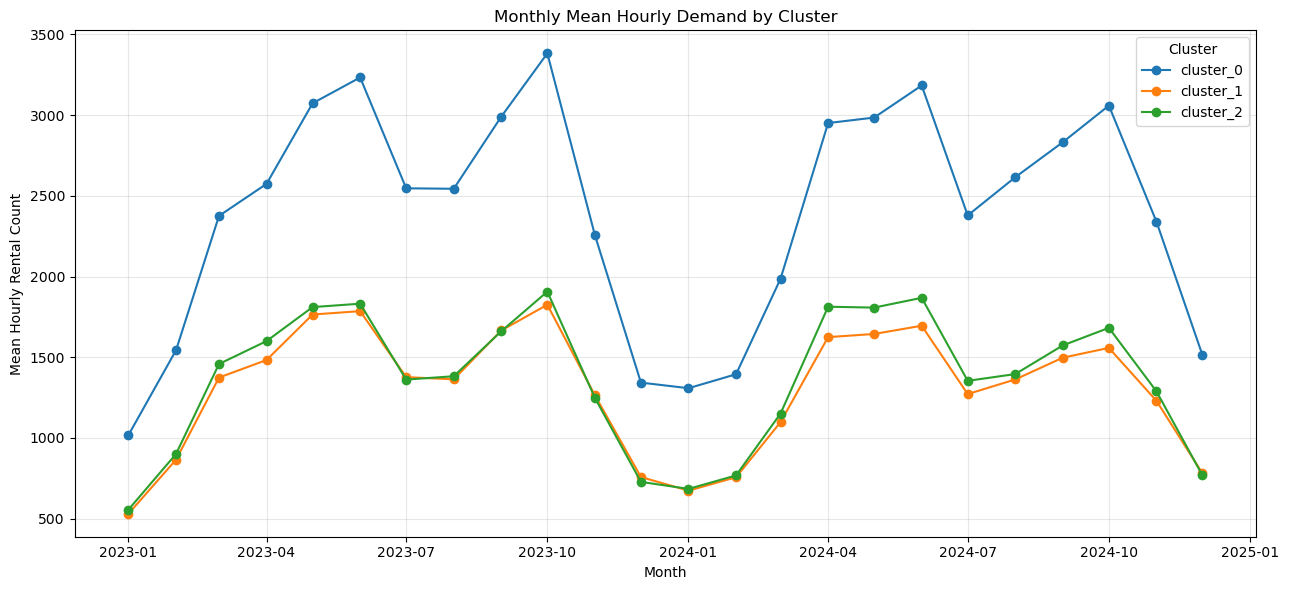

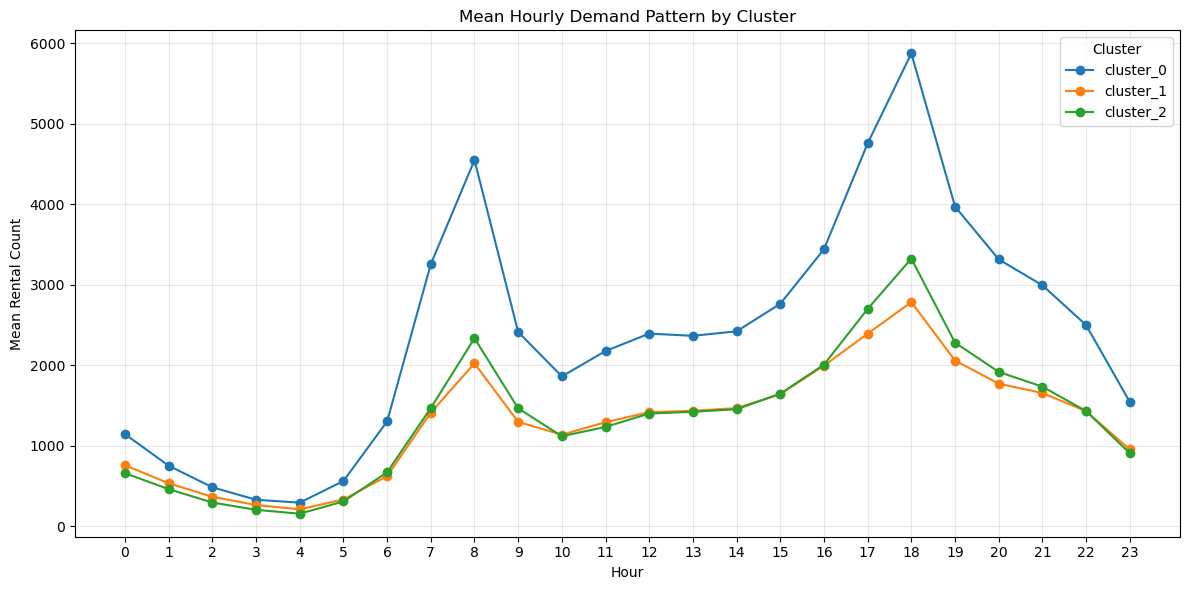

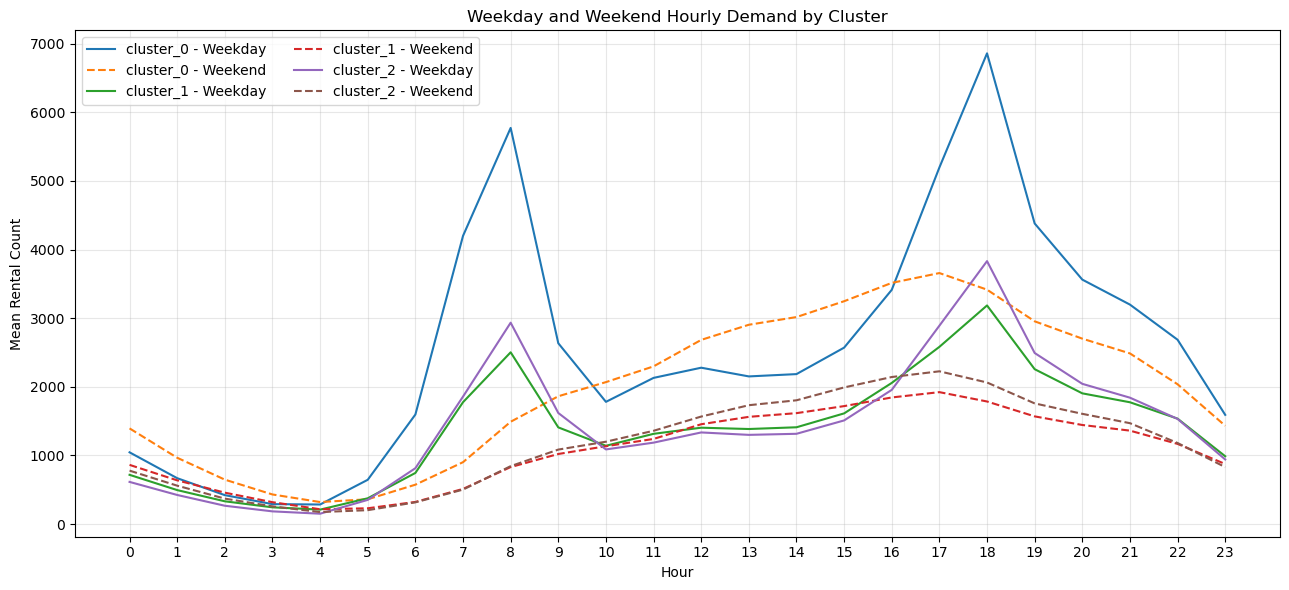

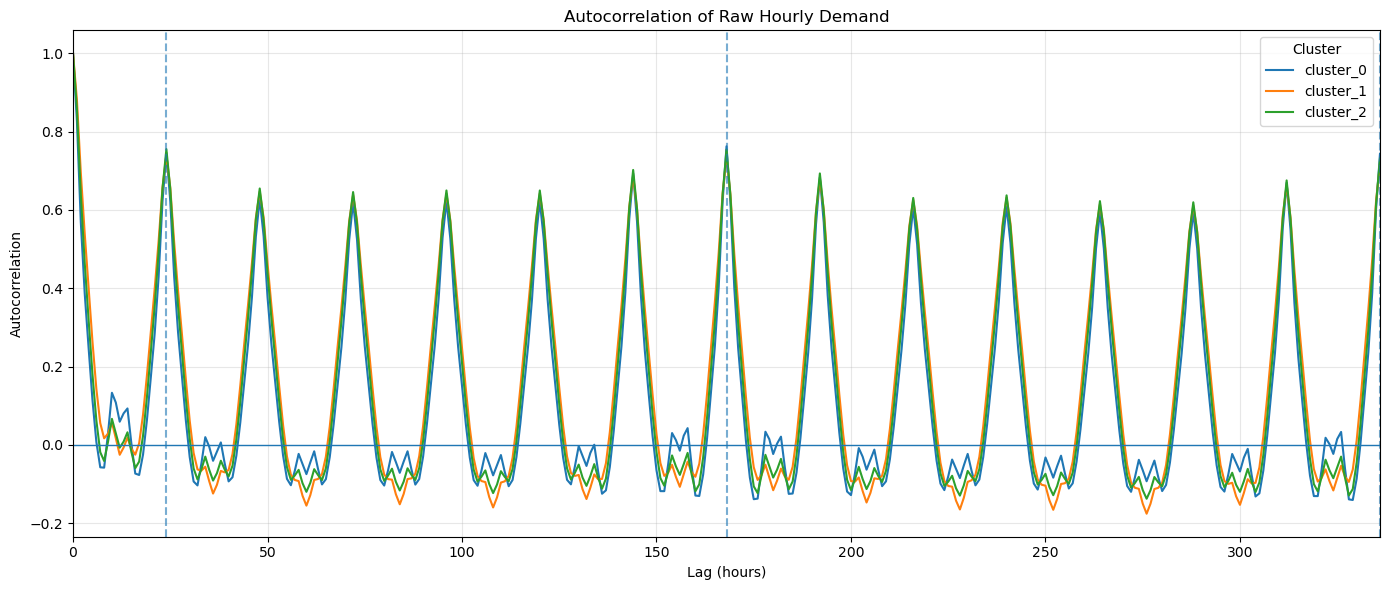

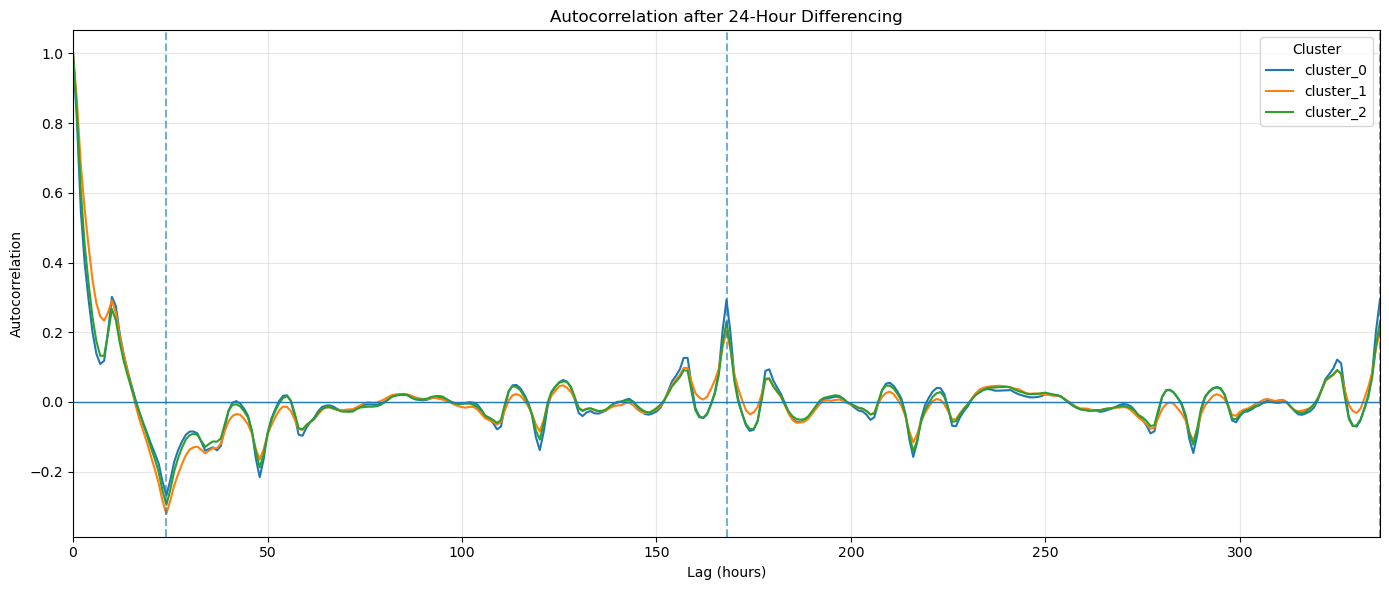

[통합 #5 데이터 검증 결과]
분석 행 수: 52,632행
전체 시간대: 17,544개
군집 수: 3개
datetime × cluster_id 중복: 0건
결측치: 0개
누락 시간대: 0개

[군집별 수요 규모]


,cluster_id,cluster_label,observation_count,total_demand,mean_hourly_demand,median_hourly_demand,standard_deviation,minimum_demand,maximum_demand,demand_share_pct
0,0,cluster_0,17544,42011493,2394.636,1940.5,2055.887,9,12325,47.359
1,1,cluster_1,17544,22855516,1302.754,1113.0,996.412,8,5629,25.765
2,2,cluster_2,17544,23841868,1358.976,1096.0,1156.870,7,6735,26.877



[군집별 계절 평균 수요]


,cluster_id,cluster_label,season_name,mean_hourly_demand,median_hourly_demand,relative_demand
0,0,cluster_0,Spring,2656.347,2313.5,1.109291
1,0,cluster_0,Summer,2745.198,2400.0,1.146395
2,0,cluster_0,Autumn,2814.858,2442.5,1.175485
3,0,cluster_0,Winter,1349.671,1139.0,0.563623
4,1,cluster_1,Spring,1497.438,1425.0,1.149440
5,1,cluster_1,Summer,1472.896,1378.0,1.130602
6,1,cluster_1,Autumn,1508.777,1435.0,1.158144
7,1,cluster_1,Winter,724.720,631.0,0.556298
8,2,cluster_2,Spring,1605.648,1428.0,1.181513
9,2,cluster_2,Summer,1528.715,1345.5,1.124902



[군집별 평균 수요 최고 시간]


...


[군집별 주요 시차 원수요 자기상관]


,lag_hours,cluster_0,cluster_1,cluster_2
0,1,0.827473,0.881299,0.857453
1,2,0.568791,0.695697,0.640035
2,3,0.387615,0.540426,0.465576
3,24,0.746591,0.741256,0.755962
4,48,0.629191,0.648142,0.655808
5,168,0.766378,0.740114,0.757953
6,336,0.751139,0.725796,0.739444



[모델링 시사점]


,analysis_result,modeling_decision
0,직전 시간 수요와 강한 연속성,"LightGBM lag_1, lag_2, lag_3 후보"
1,전일 같은 시간의 반복성,LightGBM lag_24 및 SARIMA 계절 주기 24 후보
2,전주 같은 요일·시간의 반복성,LightGBM lag_168 후보
3,평일과 주말의 시간대 패턴 차이,"hour, weekday, is_weekend 변수 후보"
4,계절에 따른 수요 수준 차이,month 변수 후보
5,단기 공통 수요 급락 구간,원본 유지 후 품질 이상 의심 구간으로 별도 기록



[저장된 핵심 그림]
- outputs\figures\integrated_monthly_demand_by_cluster.png
- outputs\figures\integrated_hourly_demand_by_cluster.png
- outputs\figures\integrated_weekday_weekend_demand_by_cluster.png
- outputs\figures\integrated_raw_demand_acf.png
- outputs\figures\integrated_daily_differenced_acf.png

[저장된 핵심 결과 파일]
- outputs\metrics\integrated_cluster_demand_summary.csv
- outputs\metrics\integrated_season_demand_summary.csv
- outputs\metrics\integrated_conditional_low_episodes.csv
- outputs\metrics\integrated_lag_autocorrelation_summary.csv

극단값은 자동 삭제하거나 보간하지 않았으며, 원본 데이터를 유지한 상태에서 품질 이상 의심 구간만 기록했다.
시차 변수와 SARIMAX 계절 주기는 탐색적 분석 결과를 바탕으로 한 후보이며, 최종 사용 여부는 시간 순서 기반 검증 성능으로 결정한다.


In [5]:
# 5. 탐색적 데이터 분석과 모델링 시사점을 통합하여 확인한다.

from statsmodels.tsa.stattools import acf


# 1) 입력 데이터와 분석 환경을 검증한다.

if "modeling_base" not in globals():
    raise NameError(
        "모델링 기초 데이터 modeling_base가 존재하지 않는다. "
        "#4 데이터 준비 단계를 먼저 실행해야 한다."
    )


required_objects = [
    "pd",
    "np",
    "plt",
    "ROOT",
    "FIGURES_DIR",
    "DATETIME_COLUMN",
    "CLUSTER_ID_COLUMN",
    "CLUSTER_LABEL_COLUMN",
    "TARGET_COLUMN",
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:
    raise NameError(
        "통합 탐색적 분석에 필요한 객체가 없다: "
        f"{missing_objects}"
    )


required_columns = {
    DATETIME_COLUMN,
    CLUSTER_ID_COLUMN,
    CLUSTER_LABEL_COLUMN,
    TARGET_COLUMN,
}


missing_columns = sorted(
    required_columns
    - set(modeling_base.columns)
)


if missing_columns:
    raise KeyError(
        "modeling_base에 필요한 컬럼이 없다: "
        f"{missing_columns}"
    )


demand_eda = (
    modeling_base[
        [
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
            TARGET_COLUMN,
        ]
    ]
    .copy()
)


demand_eda[
    DATETIME_COLUMN
] = pd.to_datetime(
    demand_eda[
        DATETIME_COLUMN
    ]
)


demand_eda = (
    demand_eda
    .sort_values(
        [
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
        ]
    )
    .reset_index(drop=True)
)


duplicate_key_count = int(
    demand_eda
    .duplicated(
        subset=[
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
        ]
    )
    .sum()
)


missing_value_count = int(
    demand_eda
    .isna()
    .sum()
    .sum()
)


cluster_count = int(
    demand_eda[
        CLUSTER_ID_COLUMN
    ]
    .nunique()
)


timestamp_count = int(
    demand_eda[
        DATETIME_COLUMN
    ]
    .nunique()
)


expected_datetime_index = pd.date_range(
    start=demand_eda[
        DATETIME_COLUMN
    ].min(),
    end=demand_eda[
        DATETIME_COLUMN
    ].max(),
    freq="h",
)


observed_datetime_index = pd.DatetimeIndex(
    demand_eda[
        DATETIME_COLUMN
    ]
    .drop_duplicates()
    .sort_values()
)


missing_timestamp_count = int(
    len(
        expected_datetime_index
        .difference(
            observed_datetime_index
        )
    )
)


if duplicate_key_count != 0:
    raise ValueError(
        "datetime × cluster_id 중복이 존재한다: "
        f"{duplicate_key_count:,}건"
    )


if missing_value_count != 0:
    raise ValueError(
        "분석 데이터에 결측치가 존재한다: "
        f"{missing_value_count:,}개"
    )


if cluster_count != 3:
    raise ValueError(
        "군집 수가 예상값 3개와 일치하지 않는다: "
        f"{cluster_count:,}개"
    )


if missing_timestamp_count != 0:
    raise ValueError(
        "시간 인덱스에 누락 시점이 존재한다: "
        f"{missing_timestamp_count:,}개"
    )


# 2) 시간 관련 파생변수를 생성한다.

demand_eda[
    "date"
] = (
    demand_eda[
        DATETIME_COLUMN
    ]
    .dt
    .normalize()
)


demand_eda[
    "year"
] = (
    demand_eda[
        DATETIME_COLUMN
    ]
    .dt
    .year
)


demand_eda[
    "month"
] = (
    demand_eda[
        DATETIME_COLUMN
    ]
    .dt
    .month
)


demand_eda[
    "hour"
] = (
    demand_eda[
        DATETIME_COLUMN
    ]
    .dt
    .hour
)


demand_eda[
    "weekday_number"
] = (
    demand_eda[
        DATETIME_COLUMN
    ]
    .dt
    .dayofweek
)


weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]


weekday_map = {
    number: name
    for number, name
    in enumerate(weekday_order)
}


demand_eda[
    "weekday_name"
] = (
    demand_eda[
        "weekday_number"
    ]
    .map(
        weekday_map
    )
)


demand_eda[
    "is_weekend"
] = (
    demand_eda[
        "weekday_number"
    ]
    .ge(5)
    .astype("int64")
)


demand_eda[
    "day_type"
] = np.where(
    demand_eda[
        "is_weekend"
    ]
    .eq(1),
    "Weekend",
    "Weekday",
)


season_order = [
    "Spring",
    "Summer",
    "Autumn",
    "Winter",
]


demand_eda[
    "season_name"
] = np.select(
    [
        demand_eda["month"].isin([3, 4, 5]),
        demand_eda["month"].isin([6, 7, 8]),
        demand_eda["month"].isin([9, 10, 11]),
    ],
    [
        "Spring",
        "Summer",
        "Autumn",
    ],
    default="Winter",
)


demand_eda[
    "season_name"
] = pd.Categorical(
    demand_eda[
        "season_name"
    ],
    categories=season_order,
    ordered=True,
)


demand_eda[
    "year_month"
] = (
    demand_eda[
        DATETIME_COLUMN
    ]
    .dt
    .to_period("M")
    .dt
    .to_timestamp()
)


# 3) 5.1 군집별 수요 규모와 시간 패턴을 요약한다.

cluster_summary = (
    demand_eda
    .groupby(
        [
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        observation_count=(
            TARGET_COLUMN,
            "size",
        ),
        total_demand=(
            TARGET_COLUMN,
            "sum",
        ),
        mean_hourly_demand=(
            TARGET_COLUMN,
            "mean",
        ),
        median_hourly_demand=(
            TARGET_COLUMN,
            "median",
        ),
        standard_deviation=(
            TARGET_COLUMN,
            "std",
        ),
        minimum_demand=(
            TARGET_COLUMN,
            "min",
        ),
        maximum_demand=(
            TARGET_COLUMN,
            "max",
        ),
    )
)


cluster_summary[
    "demand_share_pct"
] = (
    cluster_summary[
        "total_demand"
    ]
    / cluster_summary[
        "total_demand"
    ]
    .sum()
    * 100
)


cluster_summary = (
    cluster_summary
    .sort_values(
        CLUSTER_ID_COLUMN
    )
    .reset_index(drop=True)
)


monthly_summary = (
    demand_eda
    .groupby(
        [
            "year_month",
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        mean_hourly_demand=(
            TARGET_COLUMN,
            "mean",
        ),
        total_demand=(
            TARGET_COLUMN,
            "sum",
        ),
    )
)


season_summary = (
    demand_eda
    .groupby(
        [
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
            "season_name",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        mean_hourly_demand=(
            TARGET_COLUMN,
            "mean",
        ),
        median_hourly_demand=(
            TARGET_COLUMN,
            "median",
        ),
    )
)


cluster_mean_map = (
    cluster_summary
    .set_index(
        CLUSTER_LABEL_COLUMN
    )[
        "mean_hourly_demand"
    ]
)


season_summary[
    "relative_demand"
] = (
    season_summary[
        "mean_hourly_demand"
    ]
    / season_summary[
        CLUSTER_LABEL_COLUMN
    ]
    .map(
        cluster_mean_map
    )
)


hourly_summary = (
    demand_eda
    .groupby(
        [
            "hour",
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        mean_hourly_demand=(
            TARGET_COLUMN,
            "mean",
        )
    )
)


weekday_summary = (
    demand_eda
    .groupby(
        [
            "weekday_number",
            "weekday_name",
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        mean_hourly_demand=(
            TARGET_COLUMN,
            "mean",
        )
    )
    .sort_values(
        [
            CLUSTER_ID_COLUMN,
            "weekday_number",
        ]
    )
)


weekday_weekend_hourly = (
    demand_eda
    .groupby(
        [
            "day_type",
            "hour",
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        mean_hourly_demand=(
            TARGET_COLUMN,
            "mean",
        )
    )
)


peak_hour_summary = (
    hourly_summary
    .loc[
        hourly_summary
        .groupby(
            CLUSTER_ID_COLUMN
        )[
            "mean_hourly_demand"
        ]
        .idxmax()
    ]
    [
        [
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
            "hour",
            "mean_hourly_demand",
        ]
    ]
    .rename(
        columns={
            "hour": "peak_hour",
            "mean_hourly_demand": "peak_mean_demand",
        }
    )
    .sort_values(
        CLUSTER_ID_COLUMN
    )
    .reset_index(drop=True)
)


# 4) 5.1 핵심 그래프를 생성한다.

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


monthly_figure_path = (
    FIGURES_DIR
    / "integrated_monthly_demand_by_cluster.png"
)


plt.figure(
    figsize=(13, 6)
)


for (
    cluster_label,
    cluster_data,
) in (
    monthly_summary
    .groupby(
        CLUSTER_LABEL_COLUMN,
        observed=True,
    )
):

    cluster_data = (
        cluster_data
        .sort_values(
            "year_month"
        )
    )

    plt.plot(
        cluster_data[
            "year_month"
        ],
        cluster_data[
            "mean_hourly_demand"
        ],
        marker="o",
        label=cluster_label,
    )


plt.title(
    "Monthly Mean Hourly Demand by Cluster"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Mean Hourly Rental Count"
)

plt.legend(
    title="Cluster"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    monthly_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


hourly_figure_path = (
    FIGURES_DIR
    / "integrated_hourly_demand_by_cluster.png"
)


plt.figure(
    figsize=(12, 6)
)


for (
    cluster_label,
    cluster_data,
) in (
    hourly_summary
    .groupby(
        CLUSTER_LABEL_COLUMN,
        observed=True,
    )
):

    plt.plot(
        cluster_data[
            "hour"
        ],
        cluster_data[
            "mean_hourly_demand"
        ],
        marker="o",
        label=cluster_label,
    )


plt.title(
    "Mean Hourly Demand Pattern by Cluster"
)

plt.xlabel(
    "Hour"
)

plt.ylabel(
    "Mean Rental Count"
)

plt.xticks(
    range(24)
)

plt.legend(
    title="Cluster"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    hourly_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


weekday_weekend_figure_path = (
    FIGURES_DIR
    / "integrated_weekday_weekend_demand_by_cluster.png"
)


plt.figure(
    figsize=(13, 6)
)


line_style_map = {
    "Weekday": "-",
    "Weekend": "--",
}


for (
    cluster_label,
    day_type,
), group_data in (
    weekday_weekend_hourly
    .groupby(
        [
            CLUSTER_LABEL_COLUMN,
            "day_type",
        ],
        observed=True,
    )
):

    group_data = (
        group_data
        .sort_values(
            "hour"
        )
    )

    plt.plot(
        group_data[
            "hour"
        ],
        group_data[
            "mean_hourly_demand"
        ],
        linestyle=line_style_map[
            day_type
        ],
        label=(
            f"{cluster_label} - {day_type}"
        ),
    )


plt.title(
    "Weekday and Weekend Hourly Demand by Cluster"
)

plt.xlabel(
    "Hour"
)

plt.ylabel(
    "Mean Rental Count"
)

plt.xticks(
    range(24)
)

plt.legend(
    ncol=2
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    weekday_weekend_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


# 5) 5.2 조건부 저수요와 연속 이상 구간을 점검한다.

conditional_group_columns = [
    CLUSTER_ID_COLUMN,
    CLUSTER_LABEL_COLUMN,
    "season_name",
    "day_type",
    "hour",
]


conditional_baseline = (
    demand_eda
    .groupby(
        conditional_group_columns,
        as_index=False,
        observed=True,
    )
    .agg(
        reference_count=(
            TARGET_COLUMN,
            "size",
        ),
        conditional_median_demand=(
            TARGET_COLUMN,
            "median",
        ),
    )
)


expected_baseline_group_count = (
    3
    * 4
    * 2
    * 24
)


if len(conditional_baseline) != expected_baseline_group_count:
    raise ValueError(
        "조건부 기준 그룹 수가 예상값과 일치하지 않는다. "
        f"예상: {expected_baseline_group_count}, "
        f"실제: {len(conditional_baseline)}"
    )


conditional_check = (
    demand_eda
    .merge(
        conditional_baseline,
        on=conditional_group_columns,
        how="left",
        validate="many_to_one",
    )
)


conditional_check[
    "conditional_demand_ratio"
] = (
    conditional_check[
        TARGET_COLUMN
    ]
    / conditional_check[
        "conditional_median_demand"
    ]
)


conditional_check[
    "is_severe_conditional_low"
] = (
    conditional_check[
        "conditional_demand_ratio"
    ]
    .le(0.10)
)


citywide_conditional = (
    conditional_check
    .groupby(
        DATETIME_COLUMN,
        as_index=False,
        observed=True,
    )
    .agg(
        citywide_demand=(
            TARGET_COLUMN,
            "sum",
        ),
        citywide_baseline=(
            "conditional_median_demand",
            "sum",
        ),
        severe_low_cluster_count=(
            "is_severe_conditional_low",
            "sum",
        ),
    )
    .sort_values(
        DATETIME_COLUMN
    )
    .reset_index(drop=True)
)


citywide_conditional[
    "citywide_conditional_ratio"
] = (
    citywide_conditional[
        "citywide_demand"
    ]
    / citywide_conditional[
        "citywide_baseline"
    ]
)


citywide_conditional[
    "is_common_conditional_low"
] = (
    citywide_conditional[
        "severe_low_cluster_count"
    ]
    .ge(2)
)


common_low_hours = (
    citywide_conditional
    .loc[
        citywide_conditional[
            "is_common_conditional_low"
        ]
    ]
    .copy()
    .sort_values(
        DATETIME_COLUMN
    )
    .reset_index(drop=True)
)


if not common_low_hours.empty:

    common_low_hours[
        "episode_start_flag"
    ] = (
        common_low_hours[
            DATETIME_COLUMN
        ]
        .diff()
        .ne(
            pd.Timedelta(hours=1)
        )
    )

    common_low_hours[
        "episode_id"
    ] = (
        common_low_hours[
            "episode_start_flag"
        ]
        .cumsum()
        .astype("int64")
    )

else:

    common_low_hours[
        "episode_id"
    ] = pd.Series(
        dtype="int64"
    )


citywide_indexed = (
    citywide_conditional
    .set_index(
        DATETIME_COLUMN
    )
)


episode_records = []


for (
    episode_id,
    episode_data,
) in (
    common_low_hours
    .groupby(
        "episode_id",
        observed=True,
    )
):

    episode_start = (
        episode_data[
            DATETIME_COLUMN
        ]
        .min()
    )

    episode_end = (
        episode_data[
            DATETIME_COLUMN
        ]
        .max()
    )

    duration_hours = int(
        (
            episode_end
            - episode_start
        )
        / pd.Timedelta(hours=1)
    ) + 1

    minimum_row = (
        episode_data
        .loc[
            episode_data[
                "citywide_conditional_ratio"
            ]
            .idxmin()
        ]
    )

    previous_timestamp = (
        episode_start
        - pd.Timedelta(hours=1)
    )

    next_timestamp = (
        episode_end
        + pd.Timedelta(hours=1)
    )

    previous_ratio = (
        float(
            citywide_indexed
            .loc[
                previous_timestamp,
                "citywide_conditional_ratio",
            ]
        )
        if previous_timestamp
        in citywide_indexed.index
        else np.nan
    )

    next_ratio = (
        float(
            citywide_indexed
            .loc[
                next_timestamp,
                "citywide_conditional_ratio",
            ]
        )
        if next_timestamp
        in citywide_indexed.index
        else np.nan
    )

    is_short_common_shock = bool(
        duration_hours <= 6
        and float(
            minimum_row[
                "citywide_conditional_ratio"
            ]
        ) <= 0.10
        and pd.notna(
            previous_ratio
        )
        and previous_ratio >= 0.50
        and pd.notna(
            next_ratio
        )
        and next_ratio >= 0.50
    )

    episode_records.append(
        {
            "episode_id": int(
                episode_id
            ),
            "episode_start": episode_start,
            "episode_end": episode_end,
            "duration_hours": duration_hours,
            "minimum_timestamp": minimum_row[
                DATETIME_COLUMN
            ],
            "minimum_citywide_demand": minimum_row[
                "citywide_demand"
            ],
            "minimum_conditional_ratio": minimum_row[
                "citywide_conditional_ratio"
            ],
            "previous_conditional_ratio": previous_ratio,
            "next_conditional_ratio": next_ratio,
            "is_short_common_shock_candidate": (
                is_short_common_shock
            ),
        }
    )


episode_summary = (
    pd.DataFrame(
        episode_records
    )
)


if not episode_summary.empty:

    episode_summary = (
        episode_summary
        .sort_values(
            [
                "is_short_common_shock_candidate",
                "minimum_conditional_ratio",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )


priority_context = (
    conditional_check
    .loc[
        conditional_check[
            DATETIME_COLUMN
        ]
        .between(
            "2023-09-07 06:00:00",
            "2023-09-07 12:00:00",
        )
    ]
    .groupby(
        DATETIME_COLUMN,
        as_index=False,
        observed=True,
    )
    .agg(
        citywide_demand=(
            TARGET_COLUMN,
            "sum",
        ),
        citywide_baseline=(
            "conditional_median_demand",
            "sum",
        ),
        low_cluster_count=(
            "is_severe_conditional_low",
            "sum",
        ),
    )
)


priority_context[
    "conditional_ratio"
] = (
    priority_context[
        "citywide_demand"
    ]
    / priority_context[
        "citywide_baseline"
    ]
)


top_citywide_high_hours = (
    demand_eda
    .groupby(
        DATETIME_COLUMN,
        as_index=False,
        observed=True,
    )
    .agg(
        citywide_demand=(
            TARGET_COLUMN,
            "sum",
        )
    )
    .nlargest(
        10,
        "citywide_demand",
    )
    .reset_index(drop=True)
)


# 6) 5.3 자기상관과 반복 주기를 확인한다.

cluster_time_series = (
    demand_eda
    .pivot(
        index=DATETIME_COLUMN,
        columns=CLUSTER_LABEL_COLUMN,
        values=TARGET_COLUMN,
    )
    .sort_index()
)


cluster_time_series.columns.name = None


if cluster_time_series.isna().any().any():
    raise ValueError(
        "군집별 시계열 변환 후 결측치가 발생했다."
    )


selected_lags = [
    1,
    2,
    3,
    24,
    48,
    168,
    336,
]


lag_records = []


for cluster_label in cluster_time_series.columns:

    cluster_series = (
        cluster_time_series[
            cluster_label
        ]
        .astype("float64")
    )

    daily_diff_series = (
        cluster_series
        .diff(24)
        .dropna()
    )

    for lag_value in selected_lags:

        lag_records.append(
            {
                CLUSTER_LABEL_COLUMN: cluster_label,
                "lag_hours": lag_value,
                "raw_autocorrelation": float(
                    cluster_series
                    .autocorr(
                        lag=lag_value
                    )
                ),
                "daily_diff_autocorrelation": (
                    float(
                        daily_diff_series
                        .autocorr(
                            lag=lag_value
                        )
                    )
                ),
            }
        )


lag_summary = (
    pd.DataFrame(
        lag_records
    )
    .sort_values(
        [
            CLUSTER_LABEL_COLUMN,
            "lag_hours",
        ]
    )
    .reset_index(drop=True)
)


lag_summary_pivot = (
    lag_summary
    .pivot(
        index="lag_hours",
        columns=CLUSTER_LABEL_COLUMN,
        values="raw_autocorrelation",
    )
    .reset_index()
)


lag_summary_pivot.columns.name = None


max_acf_lag = 336

raw_acf_records = []
daily_diff_acf_records = []


for cluster_label in cluster_time_series.columns:

    raw_series = (
        cluster_time_series[
            cluster_label
        ]
        .astype("float64")
    )

    daily_diff_series = (
        raw_series
        .diff(24)
        .dropna()
    )

    raw_acf_values = acf(
        raw_series,
        nlags=max_acf_lag,
        fft=True,
        adjusted=False,
    )

    daily_diff_acf_values = acf(
        daily_diff_series,
        nlags=max_acf_lag,
        fft=True,
        adjusted=False,
    )

    for lag_value, acf_value in enumerate(
        raw_acf_values
    ):

        raw_acf_records.append(
            {
                CLUSTER_LABEL_COLUMN: cluster_label,
                "lag_hours": lag_value,
                "acf": float(
                    acf_value
                ),
            }
        )

    for lag_value, acf_value in enumerate(
        daily_diff_acf_values
    ):

        daily_diff_acf_records.append(
            {
                CLUSTER_LABEL_COLUMN: cluster_label,
                "lag_hours": lag_value,
                "acf": float(
                    acf_value
                ),
            }
        )


raw_acf_full = pd.DataFrame(
    raw_acf_records
)


daily_diff_acf_full = pd.DataFrame(
    daily_diff_acf_records
)


raw_acf_figure_path = (
    FIGURES_DIR
    / "integrated_raw_demand_acf.png"
)


plt.figure(
    figsize=(14, 6)
)


for (
    cluster_label,
    cluster_data,
) in (
    raw_acf_full
    .groupby(
        CLUSTER_LABEL_COLUMN,
        observed=True,
    )
):

    plt.plot(
        cluster_data[
            "lag_hours"
        ],
        cluster_data[
            "acf"
        ],
        label=cluster_label,
    )


for reference_lag in [
    24,
    168,
    336,
]:

    plt.axvline(
        reference_lag,
        linestyle="--",
        alpha=0.6,
    )


plt.axhline(
    0,
    linewidth=1,
)

plt.title(
    "Autocorrelation of Raw Hourly Demand"
)

plt.xlabel(
    "Lag (hours)"
)

plt.ylabel(
    "Autocorrelation"
)

plt.xlim(
    0,
    max_acf_lag,
)

plt.legend(
    title="Cluster"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    raw_acf_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


daily_diff_acf_figure_path = (
    FIGURES_DIR
    / "integrated_daily_differenced_acf.png"
)


plt.figure(
    figsize=(14, 6)
)


for (
    cluster_label,
    cluster_data,
) in (
    daily_diff_acf_full
    .groupby(
        CLUSTER_LABEL_COLUMN,
        observed=True,
    )
):

    plt.plot(
        cluster_data[
            "lag_hours"
        ],
        cluster_data[
            "acf"
        ],
        label=cluster_label,
    )


for reference_lag in [
    24,
    168,
    336,
]:

    plt.axvline(
        reference_lag,
        linestyle="--",
        alpha=0.6,
    )


plt.axhline(
    0,
    linewidth=1,
)

plt.title(
    "Autocorrelation after 24-Hour Differencing"
)

plt.xlabel(
    "Lag (hours)"
)

plt.ylabel(
    "Autocorrelation"
)

plt.xlim(
    0,
    max_acf_lag,
)

plt.legend(
    title="Cluster"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    daily_diff_acf_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


# 7) 핵심 결과와 모델링 시사점을 저장한다.

METRICS_DIR = (
    ROOT
    / "outputs"
    / "metrics"
)


METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


cluster_summary_path = (
    METRICS_DIR
    / "integrated_cluster_demand_summary.csv"
)


season_summary_path = (
    METRICS_DIR
    / "integrated_season_demand_summary.csv"
)


episode_summary_path = (
    METRICS_DIR
    / "integrated_conditional_low_episodes.csv"
)


lag_summary_path = (
    METRICS_DIR
    / "integrated_lag_autocorrelation_summary.csv"
)


cluster_summary.to_csv(
    cluster_summary_path,
    index=False,
    encoding="utf-8-sig",
)


season_summary.to_csv(
    season_summary_path,
    index=False,
    encoding="utf-8-sig",
)


episode_summary.to_csv(
    episode_summary_path,
    index=False,
    encoding="utf-8-sig",
)


lag_summary.to_csv(
    lag_summary_path,
    index=False,
    encoding="utf-8-sig",
)


modeling_implications = pd.DataFrame(
    {
        "analysis_result": [
            "직전 시간 수요와 강한 연속성",
            "전일 같은 시간의 반복성",
            "전주 같은 요일·시간의 반복성",
            "평일과 주말의 시간대 패턴 차이",
            "계절에 따른 수요 수준 차이",
            "단기 공통 수요 급락 구간",
        ],
        "modeling_decision": [
            "LightGBM lag_1, lag_2, lag_3 후보",
            "LightGBM lag_24 및 SARIMA 계절 주기 24 후보",
            "LightGBM lag_168 후보",
            "hour, weekday, is_weekend 변수 후보",
            "month 변수 후보",
            "원본 유지 후 품질 이상 의심 구간으로 별도 기록",
        ],
    }
)


# 8) 포트폴리오에 필요한 핵심 결과만 출력한다.

print("[통합 #5 데이터 검증 결과]")

print(
    f"분석 행 수: "
    f"{len(demand_eda):,}행"
)

print(
    f"전체 시간대: "
    f"{timestamp_count:,}개"
)

print(
    f"군집 수: "
    f"{cluster_count:,}개"
)

print(
    f"datetime × cluster_id 중복: "
    f"{duplicate_key_count:,}건"
)

print(
    f"결측치: "
    f"{missing_value_count:,}개"
)

print(
    f"누락 시간대: "
    f"{missing_timestamp_count:,}개"
)


print("\n[군집별 수요 규모]")

display(
    cluster_summary
    .round(
        {
            "mean_hourly_demand": 3,
            "median_hourly_demand": 3,
            "standard_deviation": 3,
            "demand_share_pct": 3,
        }
    )
)


print("\n[군집별 계절 평균 수요]")

display(
    season_summary
    .round(
        {
            "mean_hourly_demand": 3,
            "median_hourly_demand": 3,
            "relative_demand": 6,
        }
    )
)


print("\n[군집별 평균 수요 최고 시간]")

display(
    peak_hour_summary
    .round(
        {
            "peak_mean_demand": 3,
        }
    )
)


print("\n[서울시 전체 최고 수요 시점 상위 10개]")

display(
    top_citywide_high_hours
)


print("\n[조건부 저수요 에피소드 요약 — 상위 10개]")

display(
    episode_summary
    .head(10)
    .round(
        {
            "minimum_conditional_ratio": 6,
            "previous_conditional_ratio": 6,
            "next_conditional_ratio": 6,
        }
    )
)


print("\n[2023-09-07 06~12시 품질 이상 의심 구간]")

display(
    priority_context
    .round(
        {
            "citywide_baseline": 3,
            "conditional_ratio": 6,
        }
    )
)


print("\n[군집별 주요 시차 원수요 자기상관]")

display(
    lag_summary_pivot
    .round(6)
)


print("\n[모델링 시사점]")

display(
    modeling_implications
)


print("\n[저장된 핵심 그림]")

for path in [
    monthly_figure_path,
    hourly_figure_path,
    weekday_weekend_figure_path,
    raw_acf_figure_path,
    daily_diff_acf_figure_path,
]:

    print(
        f"- {path.relative_to(ROOT)}"
    )


print("\n[저장된 핵심 결과 파일]")

for path in [
    cluster_summary_path,
    season_summary_path,
    episode_summary_path,
    lag_summary_path,
]:

    print(
        f"- {path.relative_to(ROOT)}"
    )


print(
    "\n극단값은 자동 삭제하거나 보간하지 않았으며, "
    "원본 데이터를 유지한 상태에서 품질 이상 의심 구간만 기록했다."
)

print(
    "시차 변수와 SARIMAX 계절 주기는 "
    "탐색적 분석 결과를 바탕으로 한 후보이며, "
    "최종 사용 여부는 시간 순서 기반 검증 성능으로 결정한다."
)

## 6. 시간 순서 기반 데이터 분할과 기준모델 평가

SARIMA와 LightGBM을 공정하게 비교하기 위해 전체 데이터를 학습·검증·테스트 구간으로 나눈다. 시계열 데이터는 과거 자료를 이용해 미래를 예측해야 하므로 데이터를 무작위로 섞지 않고 시간 순서를 유지한다.

각 군집의 다음 1시간 수요를 예측하는 문제로 정의하고, 예측 시점에는 직전 시간까지 관측된 과거 수요와 예측 시점의 달력 정보를 사용할 수 있다고 가정한다.

### 데이터 분할

전체 분석 기간은 2023년 1월 1일부터 2024년 12월 31일까지이며, 다음과 같이 분할한다.

| 구분      | 기간                      | 용도       |
| ------- | ----------------------- | -------- |
| 학습 데이터  | 2023-01-01 ~ 2024-06-30 | 모델 학습    |
| 검증 데이터  | 2024-07-01 ~ 2024-09-30 | 모델 설정 선택 |
| 테스트 데이터 | 2024-10-01 ~ 2024-12-31 | 최종 성능 평가 |

학습 데이터는 약 18개월, 검증 데이터와 테스트 데이터는 각각 약 3개월로 구성한다. 검증 결과를 이용해 모델 설정을 선택하고, 테스트 데이터는 설정이 완료된 이후 최종 비교에만 사용한다.

### 기준모델

학습 모델의 성능이 실제로 의미 있는지 확인하기 위해 두 가지 단순 기준모델을 사용한다.

* 일간 나이브 모델: 전일 같은 시간의 수요인 `lag_24`를 예측값으로 사용
* 주간 나이브 모델: 전주 같은 요일·시간의 수요인 `lag_168`을 예측값으로 사용

이번 프로젝트는 한 시간씩 순차적으로 예측하는 상황을 가정하므로, 예측 시점보다 이전에 관측된 실제 수요는 사용할 수 있다. 따라서 두 기준모델은 미래값이 아닌 과거 관측값만 사용한다.

### 평가 지표

모델 성능은 다음 두 지표로 평가한다.

* RMSE: 큰 예측 오차에 더 큰 불이익을 주는 지표로, 주 평가 지표로 사용
* MAE: 평균적으로 실제 수요와 몇 건 정도 차이가 나는지 보여주는 보조 지표

평가 지표는 군집별로 계산하고, 세 군집의 결과를 동일한 비중으로 평균한 Macro Average도 함께 제시한다. 이를 통해 수요 규모가 가장 큰 군집이 전체 결과를 지나치게 지배하지 않도록 한다.

수요가 매우 낮은 시간대에서는 비율 오차가 과도하게 커질 수 있으므로 MAPE는 핵심 평가 지표에서 제외한다.

### 데이터 누출 방지 원칙

* 데이터를 무작위로 섞지 않는다.
* 모든 시차 변수는 과거 수요만 사용한다.
* 학습이 필요한 통계량은 학습 데이터에서만 계산한다.
* 검증 데이터는 모델 설정 선택에 사용한다.
* 테스트 데이터는 최종 모델 확정 후 한 번만 평가한다.
* 데이터 품질 이상 의심 구간은 임의로 삭제하거나 보정하지 않는다.


In [6]:
# 1) 입력 데이터와 필수 객체를 확인한다.

if "demand_eda" not in globals():
    raise NameError(
        "통합 탐색적 분석 데이터 demand_eda가 존재하지 않는다. "
        "#5 통합 코드 셀을 먼저 실행해야 한다."
    )


required_objects = [
    "pd",
    "np",
    "ROOT",
    "DATETIME_COLUMN",
    "CLUSTER_ID_COLUMN",
    "CLUSTER_LABEL_COLUMN",
    "TARGET_COLUMN",
]


missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]


if missing_objects:
    raise NameError(
        "데이터 분할에 필요한 객체가 없다: "
        f"{missing_objects}"
    )


required_columns = {
    DATETIME_COLUMN,
    CLUSTER_ID_COLUMN,
    CLUSTER_LABEL_COLUMN,
    TARGET_COLUMN,
}


missing_columns = sorted(
    required_columns
    - set(demand_eda.columns)
)


if missing_columns:
    raise KeyError(
        "데이터 분할에 필요한 컬럼이 없다: "
        f"{missing_columns}"
    )


# 2) 학습·검증·테스트 기간을 설정한다.

TRAIN_START = pd.Timestamp(
    "2023-01-01 00:00:00"
)

TRAIN_END = pd.Timestamp(
    "2024-06-30 23:00:00"
)

VALIDATION_START = pd.Timestamp(
    "2024-07-01 00:00:00"
)

VALIDATION_END = pd.Timestamp(
    "2024-09-30 23:00:00"
)

TEST_START = pd.Timestamp(
    "2024-10-01 00:00:00"
)

TEST_END = pd.Timestamp(
    "2024-12-31 23:00:00"
)


split_order = [
    "train",
    "validation",
    "test",
]


split_periods = {
    "train": (
        TRAIN_START,
        TRAIN_END,
    ),
    "validation": (
        VALIDATION_START,
        VALIDATION_END,
    ),
    "test": (
        TEST_START,
        TEST_END,
    ),
}


expected_split_counts = {
    "train": {
        "timestamp_count": 13128,
        "row_count": 39384,
    },
    "validation": {
        "timestamp_count": 2208,
        "row_count": 6624,
    },
    "test": {
        "timestamp_count": 2208,
        "row_count": 6624,
    },
}


# 3) 분석 데이터를 시간 순서대로 정리하고 분할한다.

modeling_split_data = (
    demand_eda[
        [
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
            TARGET_COLUMN,
        ]
    ]
    .copy()
)


modeling_split_data[
    DATETIME_COLUMN
] = pd.to_datetime(
    modeling_split_data[
        DATETIME_COLUMN
    ]
)


modeling_split_data = (
    modeling_split_data
    .sort_values(
        [
            CLUSTER_ID_COLUMN,
            DATETIME_COLUMN,
        ]
    )
    .reset_index(drop=True)
)


if (
    modeling_split_data[
        DATETIME_COLUMN
    ]
    .min()
    != TRAIN_START
):
    raise ValueError(
        "전체 데이터의 시작 시점이 예상값과 일치하지 않는다."
    )


if (
    modeling_split_data[
        DATETIME_COLUMN
    ]
    .max()
    != TEST_END
):
    raise ValueError(
        "전체 데이터의 종료 시점이 예상값과 일치하지 않는다."
    )


modeling_split_data[
    "split"
] = np.select(
    [
        modeling_split_data[
            DATETIME_COLUMN
        ]
        .between(
            TRAIN_START,
            TRAIN_END,
        ),
        modeling_split_data[
            DATETIME_COLUMN
        ]
        .between(
            VALIDATION_START,
            VALIDATION_END,
        ),
        modeling_split_data[
            DATETIME_COLUMN
        ]
        .between(
            TEST_START,
            TEST_END,
        ),
    ],
    [
        "train",
        "validation",
        "test",
    ],
    default="unassigned",
)


unassigned_count = int(
    modeling_split_data[
        "split"
    ]
    .eq("unassigned")
    .sum()
)


if unassigned_count != 0:
    raise ValueError(
        "어느 구간에도 포함되지 않은 행이 존재한다: "
        f"{unassigned_count:,}행"
    )


modeling_split_data[
    "split"
] = pd.Categorical(
    modeling_split_data[
        "split"
    ],
    categories=split_order,
    ordered=True,
)


# 4) 학습·검증·테스트 데이터를 별도 객체로 생성한다.

train_data = (
    modeling_split_data
    .loc[
        modeling_split_data[
            "split"
        ]
        .eq("train")
    ]
    .copy()
    .reset_index(drop=True)
)


validation_data = (
    modeling_split_data
    .loc[
        modeling_split_data[
            "split"
        ]
        .eq("validation")
    ]
    .copy()
    .reset_index(drop=True)
)


test_data = (
    modeling_split_data
    .loc[
        modeling_split_data[
            "split"
        ]
        .eq("test")
    ]
    .copy()
    .reset_index(drop=True)
)


# 5) 분할 결과와 시간 순서를 검증한다.

split_summary = (
    modeling_split_data
    .groupby(
        "split",
        as_index=False,
        observed=True,
    )
    .agg(
        start_datetime=(
            DATETIME_COLUMN,
            "min",
        ),
        end_datetime=(
            DATETIME_COLUMN,
            "max",
        ),
        row_count=(
            TARGET_COLUMN,
            "size",
        ),
        timestamp_count=(
            DATETIME_COLUMN,
            "nunique",
        ),
        cluster_count=(
            CLUSTER_ID_COLUMN,
            "nunique",
        ),
        total_demand=(
            TARGET_COLUMN,
            "sum",
        ),
        mean_hourly_demand=(
            TARGET_COLUMN,
            "mean",
        ),
    )
)


for split_name in split_order:

    current_split_data = (
        modeling_split_data
        .loc[
            modeling_split_data[
                "split"
            ]
            .eq(split_name)
        ]
        .copy()
    )

    expected_start, expected_end = (
        split_periods[
            split_name
        ]
    )

    observed_timestamps = pd.DatetimeIndex(
        current_split_data[
            DATETIME_COLUMN
        ]
        .drop_duplicates()
        .sort_values()
    )

    expected_timestamps = pd.date_range(
        start=expected_start,
        end=expected_end,
        freq="h",
    )


    actual_timestamp_count = int(
        current_split_data[
            DATETIME_COLUMN
        ]
        .nunique()
    )

    actual_row_count = int(
        len(
            current_split_data
        )
    )

    actual_cluster_count = int(
        current_split_data[
            CLUSTER_ID_COLUMN
        ]
        .nunique()
    )


    missing_split_timestamp_count = int(
        len(
            expected_timestamps
            .difference(
                observed_timestamps
            )
        )
    )


    if (
        actual_timestamp_count
        != expected_split_counts[
            split_name
        ][
            "timestamp_count"
        ]
    ):
        raise ValueError(
            f"{split_name} 시점 수가 예상값과 일치하지 않는다. "
            f"예상: "
            f"{expected_split_counts[split_name]['timestamp_count']:,}개, "
            f"실제: {actual_timestamp_count:,}개"
        )


    if (
        actual_row_count
        != expected_split_counts[
            split_name
        ][
            "row_count"
        ]
    ):
        raise ValueError(
            f"{split_name} 행 수가 예상값과 일치하지 않는다. "
            f"예상: "
            f"{expected_split_counts[split_name]['row_count']:,}행, "
            f"실제: {actual_row_count:,}행"
        )


    if actual_cluster_count != 3:
        raise ValueError(
            f"{split_name} 군집 수가 3개가 아니다: "
            f"{actual_cluster_count:,}개"
        )


    if missing_split_timestamp_count != 0:
        raise ValueError(
            f"{split_name} 구간에 누락된 시간대가 존재한다: "
            f"{missing_split_timestamp_count:,}개"
        )


    cluster_count_by_timestamp = (
        current_split_data
        .groupby(
            DATETIME_COLUMN,
            observed=True,
        )[
            CLUSTER_ID_COLUMN
        ]
        .nunique()
    )


    if not cluster_count_by_timestamp.eq(3).all():
        raise ValueError(
            f"{split_name} 구간의 일부 시간대에 "
            "3개 군집이 모두 존재하지 않는다."
        )


if not (
    TRAIN_END
    < VALIDATION_START
    <= VALIDATION_END
    < TEST_START
    <= TEST_END
):
    raise ValueError(
        "학습·검증·테스트 기간의 시간 순서가 올바르지 않다."
    )


train_validation_overlap_count = int(
    len(
        set(
            train_data[
                DATETIME_COLUMN
            ]
        )
        & set(
            validation_data[
                DATETIME_COLUMN
            ]
        )
    )
)


validation_test_overlap_count = int(
    len(
        set(
            validation_data[
                DATETIME_COLUMN
            ]
        )
        & set(
            test_data[
                DATETIME_COLUMN
            ]
        )
    )
)


train_test_overlap_count = int(
    len(
        set(
            train_data[
                DATETIME_COLUMN
            ]
        )
        & set(
            test_data[
                DATETIME_COLUMN
            ]
        )
    )
)


if (
    train_validation_overlap_count
    + validation_test_overlap_count
    + train_test_overlap_count
    != 0
):
    raise ValueError(
        "학습·검증·테스트 구간 사이에 중복 시간대가 존재한다."
    )


# 6) 일간·주간 나이브 기준모델 예측값을 생성한다.
# 전체 시계열에서 군집별 과거 수요를 이동시켜 생성한다.
# shift(24)는 전일 같은 시간,
# shift(168)는 전주 같은 요일·시간의 실제 수요를 의미한다.

modeling_split_data[
    "daily_naive_prediction"
] = (
    modeling_split_data
    .groupby(
        CLUSTER_ID_COLUMN,
        observed=True,
    )[
        TARGET_COLUMN
    ]
    .shift(24)
)


modeling_split_data[
    "weekly_naive_prediction"
] = (
    modeling_split_data
    .groupby(
        CLUSTER_ID_COLUMN,
        observed=True,
    )[
        TARGET_COLUMN
    ]
    .shift(168)
)


# 시차 예측값 생성 후 분할 객체를 다시 갱신한다.

train_data = (
    modeling_split_data
    .loc[
        modeling_split_data[
            "split"
        ]
        .eq("train")
    ]
    .copy()
    .reset_index(drop=True)
)


validation_data = (
    modeling_split_data
    .loc[
        modeling_split_data[
            "split"
        ]
        .eq("validation")
    ]
    .copy()
    .reset_index(drop=True)
)


test_data = (
    modeling_split_data
    .loc[
        modeling_split_data[
            "split"
        ]
        .eq("test")
    ]
    .copy()
    .reset_index(drop=True)
)


baseline_prediction_columns = [
    "daily_naive_prediction",
    "weekly_naive_prediction",
]


validation_baseline_missing_count = int(
    validation_data[
        baseline_prediction_columns
    ]
    .isna()
    .sum()
    .sum()
)


if validation_baseline_missing_count != 0:
    raise ValueError(
        "검증 구간의 기준모델 예측값에 결측치가 있다: "
        f"{validation_baseline_missing_count:,}개"
    )


# 테스트 구간에는 시차 예측값을 생성해 두지만
# 성능 지표는 최종 모델 확정 전까지 계산하지 않는다.

test_baseline_prediction_missing_count = int(
    test_data[
        baseline_prediction_columns
    ]
    .isna()
    .sum()
    .sum()
)


if test_baseline_prediction_missing_count != 0:
    raise ValueError(
        "테스트 구간의 기준모델 예측값 생성에 문제가 있다: "
        f"{test_baseline_prediction_missing_count:,}개"
    )


# 7) 검증 구간에서만 군집별 RMSE와 MAE를 계산한다.

baseline_models = {
    "Daily Naive (lag_24)": (
        "daily_naive_prediction"
    ),
    "Weekly Naive (lag_168)": (
        "weekly_naive_prediction"
    ),
}


metric_records = []


for (
    model_name,
    prediction_column,
) in baseline_models.items():

    for (
        cluster_label,
        cluster_data,
    ) in (
        validation_data
        .groupby(
            CLUSTER_LABEL_COLUMN,
            observed=True,
        )
    ):

        actual = (
            cluster_data[
                TARGET_COLUMN
            ]
            .astype("float64")
            .to_numpy()
        )

        prediction = (
            cluster_data[
                prediction_column
            ]
            .astype("float64")
            .to_numpy()
        )

        error = (
            actual
            - prediction
        )

        rmse = float(
            np.sqrt(
                np.mean(
                    error ** 2
                )
            )
        )

        mae = float(
            np.mean(
                np.abs(
                    error
                )
            )
        )


        metric_records.append(
            {
                "split": "validation",
                "model": model_name,
                "cluster_label": (
                    cluster_label
                ),
                "observation_count": int(
                    len(
                        cluster_data
                    )
                ),
                "RMSE": rmse,
                "MAE": mae,
            }
        )


baseline_cluster_metrics = pd.DataFrame(
    metric_records
)


if baseline_cluster_metrics.empty:
    raise ValueError(
        "검증 구간 기준모델 평가 결과가 생성되지 않았다."
    )


# 8) 세 군집 성능의 Macro Average를 계산한다.

baseline_macro_metrics = (
    baseline_cluster_metrics
    .groupby(
        [
            "split",
            "model",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        observation_count=(
            "observation_count",
            "sum",
        ),
        RMSE=(
            "RMSE",
            "mean",
        ),
        MAE=(
            "MAE",
            "mean",
        ),
    )
)


baseline_macro_metrics[
    "cluster_label"
] = "Macro Average"


baseline_metrics = pd.concat(
    [
        baseline_cluster_metrics,
        baseline_macro_metrics[
            baseline_cluster_metrics.columns
        ],
    ],
    ignore_index=True,
)


cluster_sort_map = {
    "cluster_0": 0,
    "cluster_1": 1,
    "cluster_2": 2,
    "Macro Average": 3,
}


baseline_metrics[
    "_cluster_order"
] = (
    baseline_metrics[
        "cluster_label"
    ]
    .map(
        cluster_sort_map
    )
)


baseline_metrics = (
    baseline_metrics
    .sort_values(
        [
            "model",
            "_cluster_order",
        ]
    )
    .drop(
        columns=[
            "_cluster_order",
        ]
    )
    .reset_index(drop=True)
)


# 9) 검증 구간의 우수 기준모델을 선정한다.

validation_macro_comparison = (
    baseline_metrics
    .loc[
        baseline_metrics[
            "cluster_label"
        ]
        .eq(
            "Macro Average"
        )
    ]
    .copy()
    .sort_values(
        [
            "RMSE",
            "MAE",
        ]
    )
    .reset_index(drop=True)
)


best_validation_baseline = (
    validation_macro_comparison
    .head(1)
    .rename(
        columns={
            "model": "best_baseline_model",
            "RMSE": "best_macro_RMSE",
            "MAE": "best_macro_MAE",
        }
    )
    [
        [
            "split",
            "best_baseline_model",
            "best_macro_RMSE",
            "best_macro_MAE",
        ]
    ]
)


# 10) 결과를 저장한다.

PROCESSED_DIR = (
    ROOT
    / "data"
    / "processed"
)


METRICS_DIR = (
    ROOT
    / "outputs"
    / "metrics"
)


PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


modeling_split_path = (
    PROCESSED_DIR
    / "modeling_split_base.csv"
)


split_summary_path = (
    METRICS_DIR
    / "time_split_summary.csv"
)


baseline_metrics_path = (
    METRICS_DIR
    / "naive_baseline_metrics.csv"
)


baseline_winner_path = (
    METRICS_DIR
    / "naive_baseline_winner_summary.csv"
)


modeling_split_data.to_csv(
    modeling_split_path,
    index=False,
    encoding="utf-8-sig",
)


split_summary.to_csv(
    split_summary_path,
    index=False,
    encoding="utf-8-sig",
)


baseline_metrics.to_csv(
    baseline_metrics_path,
    index=False,
    encoding="utf-8-sig",
)


best_validation_baseline.to_csv(
    baseline_winner_path,
    index=False,
    encoding="utf-8-sig",
)


# 11) 핵심 결과를 출력한다.

print("[통합 #6 데이터 분할 검증 결과]")

print(
    f"전체 행 수: "
    f"{len(modeling_split_data):,}행"
)

print(
    f"전체 시간대: "
    f"{modeling_split_data[DATETIME_COLUMN].nunique():,}개"
)

print(
    f"군집 수: "
    f"{modeling_split_data[CLUSTER_ID_COLUMN].nunique():,}개"
)

print(
    f"미분류 행 수: "
    f"{unassigned_count:,}행"
)

print(
    f"학습·검증 시간대 중복: "
    f"{train_validation_overlap_count:,}개"
)

print(
    f"검증·테스트 시간대 중복: "
    f"{validation_test_overlap_count:,}개"
)

print(
    f"학습·테스트 시간대 중복: "
    f"{train_test_overlap_count:,}개"
)

print(
    f"검증 구간 기준모델 예측 결측치: "
    f"{validation_baseline_missing_count:,}개"
)

print(
    "테스트 성능 평가 수행 여부: "
    "False"
)


print("\n[학습·검증·테스트 분할 요약]")

display(
    split_summary
    .round(
        {
            "mean_hourly_demand": 3,
        }
    )
)


print("\n[검증 구간 기준모델 군집별 및 Macro Average 성능]")

display(
    baseline_metrics
    .round(
        {
            "RMSE": 3,
            "MAE": 3,
        }
    )
)


print("\n[검증 구간 우수 기준모델]")

display(
    best_validation_baseline
    .round(
        {
            "best_macro_RMSE": 3,
            "best_macro_MAE": 3,
        }
    )
)


print("\n[저장된 결과 파일]")

for saved_path in [
    modeling_split_path,
    split_summary_path,
    baseline_metrics_path,
    baseline_winner_path,
]:

    print(
        f"- {saved_path.relative_to(ROOT)}"
    )


print(
    "\n모든 데이터는 시간 순서대로 분할했으며 "
    "무작위 섞기를 사용하지 않았다."
)

print(
    "기준모델은 예측 시점보다 24시간 또는 168시간 이전의 "
    "실제 관측값만 사용한다."
)

print(
    "기준모델 성능은 검증 구간에서만 계산했다."
)

print(
    "테스트 데이터는 분할과 시차 예측값 생성까지만 수행했으며, "
    "RMSE와 MAE는 최종 모델 설정 확정 후 계산한다."
)

print(
    "이후 SARIMAX와 LightGBM의 설정은 "
    "검증 구간 RMSE를 우선 기준으로 선택한다."
)


[통합 #6 데이터 분할 검증 결과]
전체 행 수: 52,632행
전체 시간대: 17,544개
군집 수: 3개
미분류 행 수: 0행
학습·검증 시간대 중복: 0개
검증·테스트 시간대 중복: 0개
학습·테스트 시간대 중복: 0개
검증 구간 기준모델 예측 결측치: 0개
테스트 성능 평가 수행 여부: False

[학습·검증·테스트 분할 요약]


,split,start_datetime,end_datetime,row_count,timestamp_count,cluster_count,total_demand,mean_hourly_demand
0,train,2023-01-01,2024-06-30 23:00:00,39384,13128,3,66275204,1682.795
1,validation,2024-07-01,2024-09-30 23:00:00,6624,2208,3,11971359,1807.270
2,test,2024-10-01,2024-12-31 23:00:00,6624,2208,3,10462314,1579.456



[검증 구간 기준모델 군집별 및 Macro Average 성능]


,split,model,cluster_label,observation_count,RMSE,MAE
0,validation,Daily Naive (lag_24),cluster_0,2208,1514.047,852.585
1,validation,Daily Naive (lag_24),cluster_1,2208,720.033,431.161
2,validation,Daily Naive (lag_24),cluster_2,2208,822.555,481.207
3,validation,Daily Naive (lag_24),Macro Average,6624,1018.878,588.318
4,validation,Weekly Naive (lag_168),cluster_0,2208,1558.665,861.961
5,validation,Weekly Naive (lag_168),cluster_1,2208,763.651,455.105
6,validation,Weekly Naive (lag_168),cluster_2,2208,855.068,495.845
7,validation,Weekly Naive (lag_168),Macro Average,6624,1059.128,604.304



[검증 구간 우수 기준모델]


,split,best_baseline_model,best_macro_RMSE,best_macro_MAE
0,validation,Daily Naive (lag_24),1018.878,588.318



[저장된 결과 파일]
- data\processed\modeling_split_base.csv
- outputs\metrics\time_split_summary.csv
- outputs\metrics\naive_baseline_metrics.csv
- outputs\metrics\naive_baseline_winner_summary.csv

모든 데이터는 시간 순서대로 분할했으며 무작위 섞기를 사용하지 않았다.
기준모델은 예측 시점보다 24시간 또는 168시간 이전의 실제 관측값만 사용한다.
기준모델 성능은 검증 구간에서만 계산했다.
테스트 데이터는 분할과 시차 예측값 생성까지만 수행했으며, RMSE와 MAE는 최종 모델 설정 확정 후 계산한다.
이후 SARIMAX와 LightGBM의 설정은 검증 구간 RMSE를 우선 기준으로 선택한다.


## 7. SARIMA 모델링 및 검증

탐색적 분석 결과 공공자전거 수요는 직전 시간과 높은 연속성을 보였으며, 전일 같은 시간의 수요와도 뚜렷한 반복 관계를 나타냈다. 이를 반영하여 24시간 계절 주기를 갖는 SARIMA 모델을 구축한다.

Python 구현에는 `statsmodels`의 `SARIMAX` 클래스를 사용한다. 이 클래스는 외생변수가 없는 SARIMA와 외생변수가 포함된 SARIMAX를 모두 지원한다. 이번 프로젝트에서는 외생변수를 입력하지 않으므로 실제 적합 모델은 SARIMA이다.

### 후보 모델

과도한 하이퍼파라미터 탐색을 피하고, 해석 가능한 두 개의 단순 후보만 비교한다.

| 후보       | 비계절 차수      | 계절 차수           | 설명                     |
| -------- | ----------- | --------------- | ---------------------- |
| SARIMA A | `(1, 0, 0)` | `(1, 1, 0, 24)` | 직전 수요와 24시간 계절 반복 반영   |
| SARIMA B | `(1, 0, 1)` | `(1, 1, 0, 24)` | 직전 수요와 단기 오차 구조를 함께 반영 |

계절 주기 `24`는 시간 단위 수요가 전일 같은 시간과 높은 자기상관을 보인다는 탐색적 분석 결과를 근거로 설정한다.

### 검증 방식

각 후보는 군집별 학습 데이터로 한 번 적합한다. 이후 검증 기간에서는 각 시점의 다음 1시간 수요를 순차적으로 예측한다.

검증 시점의 실제 수요는 해당 시점의 예측이 완료된 이후에만 다음 시점 예측을 위한 과거 관측값으로 사용한다. 검증 기간 동안 모델 파라미터를 다시 적합하지 않으며, 미래 시점의 수요를 미리 사용하지 않는다.

모델 선택에는 검증 기간의 RMSE와 MAE만 사용한다. 각 군집을 동일한 비중으로 반영한 Macro RMSE를 주 선택 기준으로 사용하고, Macro MAE를 함께 확인한다.

검증 결과 후보 B인 `(1, 0, 1) × (1, 1, 0, 24)`가 후보 A보다 우수하여 최종 SARIMA 설정으로 선택되었다.

### 평가 및 진단 기준

* 군집별 RMSE와 MAE
* 세 군집의 Macro RMSE와 Macro MAE
* 일간·주간 나이브 기준모델과의 성능 비교
* 모델 수렴 여부
* 음수 예측값 발생 여부

공공자전거 대여건수는 음수가 될 수 없으므로 음수 예측값은 0으로 조정한 뒤 평가한다. 음수 예측값의 발생 개수는 별도로 기록하여 모델의 한계도 함께 확인한다.

검증 단계에서 선택한 모델 설정은 이후 테스트 기간을 평가할 때 변경하지 않는다. 테스트 데이터는 최종 모델의 일반화 성능을 확인하는 용도로만 사용한다.



[SARIMA_A 학습 시작]
order=(1, 0, 0), seasonal_order=(1, 1, 0, 24)
- cluster_0 학습 중...
  완료: RMSE=869.998, MAE=493.881, 수렴=True, 소요시간=5.6초
- cluster_1 학습 중...
  완료: RMSE=364.105, MAE=223.784, 수렴=True, 소요시간=6.6초
- cluster_2 학습 중...
  완료: RMSE=450.948, MAE=269.286, 수렴=True, 소요시간=7.5초

[SARIMA_B 학습 시작]
order=(1, 0, 1), seasonal_order=(1, 1, 0, 24)
- cluster_0 학습 중...
  완료: RMSE=807.983, MAE=471.713, 수렴=True, 소요시간=5.3초
- cluster_1 학습 중...
  완료: RMSE=347.554, MAE=213.423, 수렴=True, 소요시간=10.2초
- cluster_2 학습 중...
  완료: RMSE=424.423, MAE=254.201, 수렴=True, 소요시간=9.5초


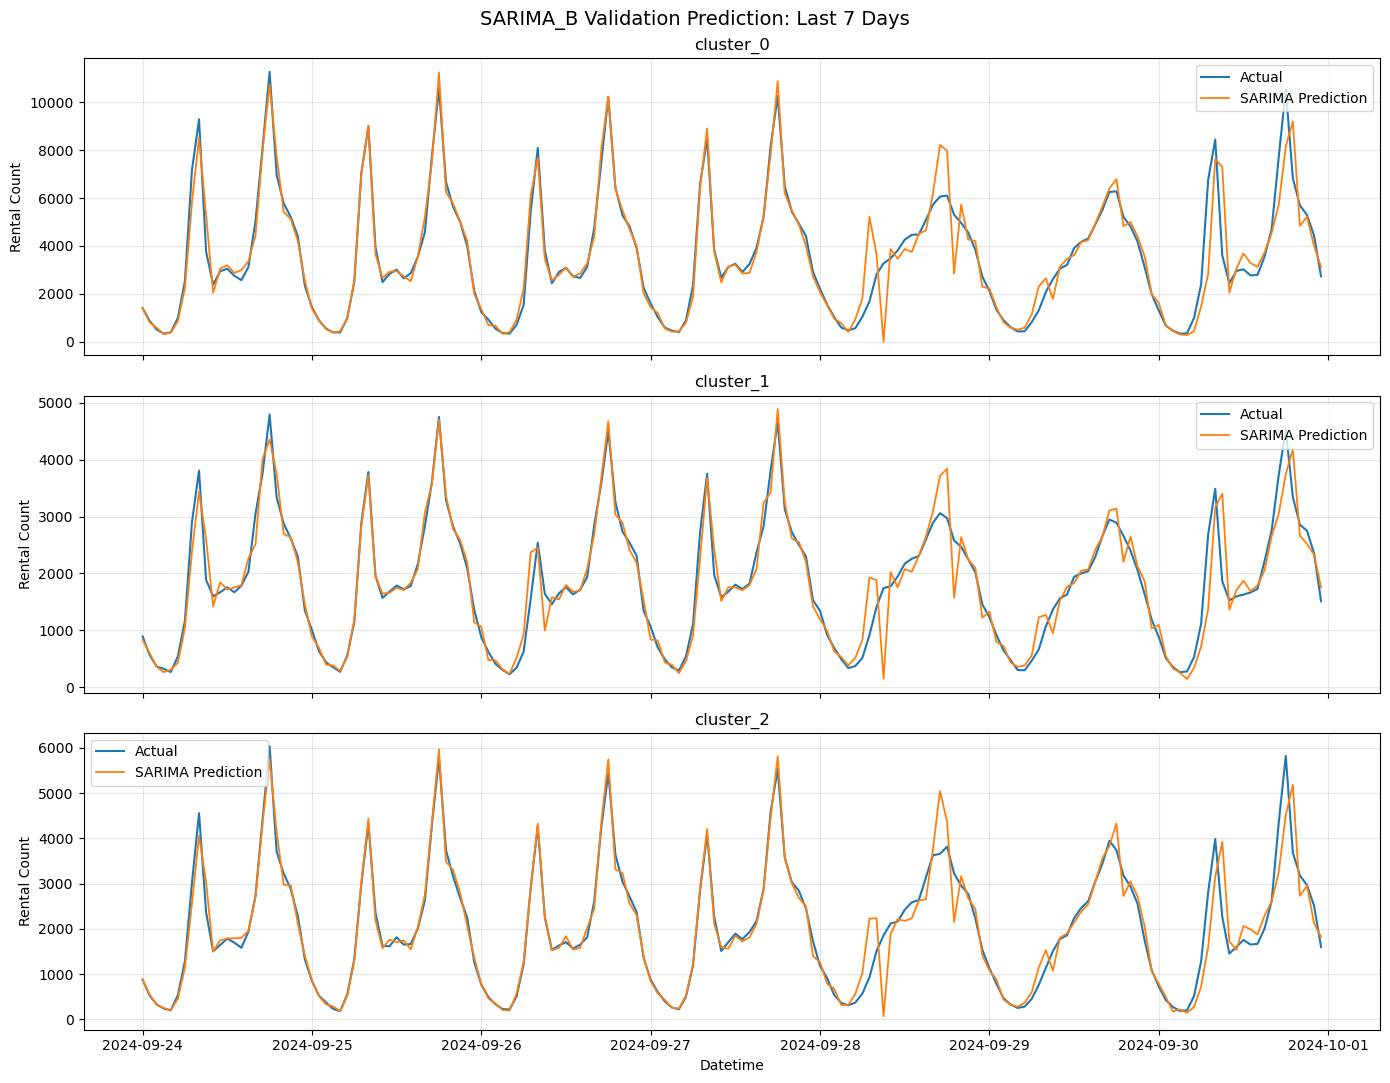


[통합 #7 SARIMA 검증 결과]
학습 구간: 2023-01-01 00:00:00 ~ 2024-06-30 23:00:00
검증 구간: 2024-07-01 00:00:00 ~ 2024-09-30 23:00:00
후보 모델 수: 2개
선택된 모델: SARIMA_B
선택된 비계절 차수: (1, 0, 1)
선택된 계절 차수: (1, 1, 0, 24)
테스트 성능 평가 수행 여부: False

[SARIMA 후보별 군집 성능]


,candidate_name,order,seasonal_order,cluster_label,fit_success,converged,fit_warning_count,fit_elapsed_seconds,negative_prediction_count,RMSE,MAE
0,SARIMA_A,"(1, 0, 0)","(1, 1, 0, 24)",cluster_0,True,True,0,5.6,40,869.998,493.881
1,SARIMA_A,"(1, 0, 0)","(1, 1, 0, 24)",cluster_1,True,True,0,6.6,31,364.105,223.784
2,SARIMA_A,"(1, 0, 0)","(1, 1, 0, 24)",cluster_2,True,True,0,7.5,36,450.948,269.286
3,SARIMA_B,"(1, 0, 1)","(1, 1, 0, 24)",cluster_0,True,True,0,5.3,34,807.983,471.713
4,SARIMA_B,"(1, 0, 1)","(1, 1, 0, 24)",cluster_1,True,True,0,10.2,24,347.554,213.423
5,SARIMA_B,"(1, 0, 1)","(1, 1, 0, 24)",cluster_2,True,True,0,9.5,29,424.423,254.201



[SARIMA 후보별 Macro Average]


,candidate_name,order,seasonal_order,successful_cluster_count,converged_cluster_count,total_warning_count,total_fit_seconds,total_negative_predictions,Macro_RMSE,Macro_MAE
1,SARIMA_B,"(1, 0, 1)","(1, 1, 0, 24)",3,3,0,25.1,87,526.653,313.112
0,SARIMA_A,"(1, 0, 0)","(1, 1, 0, 24)",3,3,0,19.7,107,561.684,328.984



[선택된 SARIMA와 기준모델 검증 성능 비교]


...


[군집별 최선 기준모델 대비 SARIMA 개선율]


,cluster_label,best_baseline_model,best_baseline_RMSE,RMSE,RMSE_improvement_pct,best_baseline_MAE,MAE,MAE_improvement_pct
0,cluster_0,Daily Naive (lag_24),1514.047,807.983,46.634,852.585,471.713,44.673
1,cluster_1,Daily Naive (lag_24),720.033,347.554,51.731,431.161,213.423,50.500
2,cluster_2,Daily Naive (lag_24),822.555,424.423,48.402,481.207,254.201,47.174



[Macro Average 기준모델 대비 SARIMA 개선율]


,selected_model,best_baseline_model,selected_macro_RMSE,best_baseline_macro_RMSE,RMSE_improvement_pct,selected_macro_MAE,best_baseline_macro_MAE,MAE_improvement_pct
0,Selected SARIMA_B,Daily Naive (lag_24),526.653,1018.878,48.31,313.112,588.318,46.778



[저장된 그림]
- outputs\figures\sarima_validation_last_week.png

[저장된 결과 파일]
- outputs\metrics\sarima_candidate_validation_metrics.csv
- outputs\metrics\sarima_candidate_macro_summary.csv
- outputs\metrics\sarima_selected_config.csv
- outputs\metrics\sarima_selected_validation_metrics.csv
- outputs\metrics\sarima_validation_model_comparison.csv
- outputs\metrics\sarima_baseline_improvement.csv
- outputs\predictions\sarima_validation_predictions.csv

SARIMA 후보는 학습 구간에서만 파라미터를 추정했다.
검증 구간에서는 실제값이 관측된 이후 다음 시점의 과거 정보로만 반영되며, 모델 파라미터는 다시 학습하지 않았다.
음수 예측값은 자전거 수요의 특성을 고려해 0으로 조정한 뒤 평가했다.
최종 SARIMA 설정은 검증 Macro RMSE를 기준으로 선택했다.


In [7]:
import time
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX


# 1) 이전 단계의 데이터와 객체를 확인한다.

required_objects = [
    "pd",
    "np",
    "plt",
    "ROOT",
    "FIGURES_DIR",
    "train_data",
    "validation_data",
    "test_data",
    "baseline_metrics",
    "DATETIME_COLUMN",
    "CLUSTER_ID_COLUMN",
    "CLUSTER_LABEL_COLUMN",
    "TARGET_COLUMN",
]


missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]


if missing_objects:
    raise NameError(
        "SARIMA 모델링에 필요한 객체가 없다: "
        f"{missing_objects}. "
        "#6 통합 코드 셀을 먼저 실행해야 한다."
    )


if len(train_data) == 0:
    raise ValueError(
        "학습 데이터가 비어 있다."
    )


if len(validation_data) == 0:
    raise ValueError(
        "검증 데이터가 비어 있다."
    )


observed_cluster_labels = (
    train_data[
        [
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
        ]
    ]
    .drop_duplicates()
    .sort_values(
        CLUSTER_ID_COLUMN
    )[
        CLUSTER_LABEL_COLUMN
    ]
    .tolist()
)


if len(observed_cluster_labels) != 3:
    raise ValueError(
        "군집 수가 예상값 3개와 일치하지 않는다."
    )


# 2) 비교할 SARIMA 후보를 설정한다.

SARIMA_CANDIDATES = {
    "SARIMA_A": {
        "order": (
            1,
            0,
            0,
        ),
        "seasonal_order": (
            1,
            1,
            0,
            24,
        ),
    },
    "SARIMA_B": {
        "order": (
            1,
            0,
            1,
        ),
        "seasonal_order": (
            1,
            1,
            0,
            24,
        ),
    },
}


SARIMA_MAX_ITERATIONS = 50


# 3) 군집별 학습·검증 시계열을 생성한다.

train_series_by_cluster = {}
validation_series_by_cluster = {}


for cluster_label in observed_cluster_labels:

    cluster_train_series = (
        train_data
        .loc[
            train_data[
                CLUSTER_LABEL_COLUMN
            ]
            .eq(cluster_label),
            [
                DATETIME_COLUMN,
                TARGET_COLUMN,
            ],
        ]
        .sort_values(
            DATETIME_COLUMN
        )
        .set_index(
            DATETIME_COLUMN
        )[
            TARGET_COLUMN
        ]
        .astype("float64")
        .asfreq("h")
    )


    cluster_validation_series = (
        validation_data
        .loc[
            validation_data[
                CLUSTER_LABEL_COLUMN
            ]
            .eq(cluster_label),
            [
                DATETIME_COLUMN,
                TARGET_COLUMN,
            ],
        ]
        .sort_values(
            DATETIME_COLUMN
        )
        .set_index(
            DATETIME_COLUMN
        )[
            TARGET_COLUMN
        ]
        .astype("float64")
        .asfreq("h")
    )


    if cluster_train_series.isna().any():
        raise ValueError(
            f"{cluster_label} 학습 시계열에 결측치가 있다."
        )


    if cluster_validation_series.isna().any():
        raise ValueError(
            f"{cluster_label} 검증 시계열에 결측치가 있다."
        )


    if (
        cluster_train_series.index.max()
        + pd.Timedelta(hours=1)
        != cluster_validation_series.index.min()
    ):
        raise ValueError(
            f"{cluster_label}의 학습 구간과 "
            "검증 구간이 연속적이지 않다."
        )


    train_series_by_cluster[
        cluster_label
    ] = cluster_train_series


    validation_series_by_cluster[
        cluster_label
    ] = cluster_validation_series


# 4) 후보별·군집별 SARIMA 모델을 학습하고 검증한다.
# 모델 파라미터는 학습 구간에서만 추정한다.
#
# 검증 구간은 append(refit=False)를 이용해 관측값을 순차적으로
# 상태 갱신에 반영하되, 모델 파라미터는 다시 학습하지 않는다.
#
# get_prediction(dynamic=False)는 각 시점에서 이전 시점까지의
# 정보만 이용하는 1시간 앞 예측값을 생성한다.

candidate_metric_records = []

candidate_fit_results = {}
candidate_prediction_series = {}


for (
    candidate_name,
    candidate_config,
) in SARIMA_CANDIDATES.items():

    print(
        f"\n[{candidate_name} 학습 시작]"
    )

    print(
        f"order={candidate_config['order']}, "
        f"seasonal_order={candidate_config['seasonal_order']}"
    )


    for cluster_label in observed_cluster_labels:

        print(
            f"- {cluster_label} 학습 중..."
        )


        train_series = (
            train_series_by_cluster[
                cluster_label
            ]
        )


        validation_series = (
            validation_series_by_cluster[
                cluster_label
            ]
        )


        fit_start_time = time.perf_counter()


        try:

            with warnings.catch_warnings(
                record=True
            ) as caught_warnings:

                warnings.simplefilter(
                    "always"
                )


                sarima_model = SARIMAX(
                    endog=train_series,
                    order=candidate_config[
                        "order"
                    ],
                    seasonal_order=candidate_config[
                        "seasonal_order"
                    ],
                    trend=None,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )


                fitted_result = sarima_model.fit(
                    disp=False,
                    maxiter=SARIMA_MAX_ITERATIONS,
                )


            fit_elapsed_seconds = (
                time.perf_counter()
                - fit_start_time
            )


            convergence_status = bool(
                fitted_result
                .mle_retvals
                .get(
                    "converged",
                    False,
                )
            )


            fit_warning_count = int(
                len(
                    caught_warnings
                )
            )


            # 검증 관측값을 순차적으로 상태 갱신에 사용하지만
            # 모델 계수는 다시 추정하지 않는다.
            extended_result = (
                fitted_result
                .append(
                    validation_series,
                    refit=False,
                )
            )


            prediction_result = (
                extended_result
                .get_prediction(
                    start=len(
                        train_series
                    ),
                    end=(
                        len(
                            train_series
                        )
                        + len(
                            validation_series
                        )
                        - 1
                    ),
                    dynamic=False,
                )
            )


            raw_prediction = np.asarray(
                prediction_result
                .predicted_mean,
                dtype="float64",
            )


            if (
                len(raw_prediction)
                != len(validation_series)
            ):
                raise ValueError(
                    "검증 예측값 수가 실제값 수와 일치하지 않는다."
                )


            negative_prediction_count = int(
                (
                    raw_prediction
                    < 0
                )
                .sum()
            )


            clipped_prediction = np.maximum(
                raw_prediction,
                0,
            )


            prediction_series = pd.Series(
                clipped_prediction,
                index=validation_series.index,
                name="prediction",
            )


            actual_values = (
                validation_series
                .to_numpy(
                    dtype="float64"
                )
            )


            error = (
                actual_values
                - clipped_prediction
            )


            rmse = float(
                np.sqrt(
                    np.mean(
                        error ** 2
                    )
                )
            )


            mae = float(
                np.mean(
                    np.abs(
                        error
                    )
                )
            )


            candidate_fit_results[
                (
                    candidate_name,
                    cluster_label,
                )
            ] = fitted_result


            candidate_prediction_series[
                (
                    candidate_name,
                    cluster_label,
                )
            ] = {
                "raw_prediction": pd.Series(
                    raw_prediction,
                    index=validation_series.index,
                ),
                "prediction": prediction_series,
            }


            candidate_metric_records.append(
                {
                    "candidate_name": (
                        candidate_name
                    ),
                    "order": str(
                        candidate_config[
                            "order"
                        ]
                    ),
                    "seasonal_order": str(
                        candidate_config[
                            "seasonal_order"
                        ]
                    ),
                    "cluster_label": (
                        cluster_label
                    ),
                    "observation_count": int(
                        len(
                            validation_series
                        )
                    ),
                    "fit_success": True,
                    "converged": (
                        convergence_status
                    ),
                    "fit_warning_count": (
                        fit_warning_count
                    ),
                    "fit_elapsed_seconds": (
                        fit_elapsed_seconds
                    ),
                    "negative_prediction_count": (
                        negative_prediction_count
                    ),
                    "AIC": float(
                        fitted_result.aic
                    ),
                    "BIC": float(
                        fitted_result.bic
                    ),
                    "RMSE": rmse,
                    "MAE": mae,
                    "error_message": "",
                }
            )


            print(
                f"  완료: RMSE={rmse:,.3f}, "
                f"MAE={mae:,.3f}, "
                f"수렴={convergence_status}, "
                f"소요시간={fit_elapsed_seconds:,.1f}초"
            )


        except Exception as error:

            fit_elapsed_seconds = (
                time.perf_counter()
                - fit_start_time
            )


            candidate_metric_records.append(
                {
                    "candidate_name": (
                        candidate_name
                    ),
                    "order": str(
                        candidate_config[
                            "order"
                        ]
                    ),
                    "seasonal_order": str(
                        candidate_config[
                            "seasonal_order"
                        ]
                    ),
                    "cluster_label": (
                        cluster_label
                    ),
                    "observation_count": int(
                        len(
                            validation_series
                        )
                    ),
                    "fit_success": False,
                    "converged": False,
                    "fit_warning_count": np.nan,
                    "fit_elapsed_seconds": (
                        fit_elapsed_seconds
                    ),
                    "negative_prediction_count": np.nan,
                    "AIC": np.nan,
                    "BIC": np.nan,
                    "RMSE": np.nan,
                    "MAE": np.nan,
                    "error_message": str(
                        error
                    ),
                }
            )


            print(
                f"  실패: {error}"
            )


candidate_validation_metrics = (
    pd.DataFrame(
        candidate_metric_records
    )
)


# 5) 후보별 Macro Average를 계산한다.

successful_candidate_metrics = (
    candidate_validation_metrics
    .loc[
        candidate_validation_metrics[
            "fit_success"
        ]
    ]
    .copy()
)


candidate_macro_summary = (
    successful_candidate_metrics
    .groupby(
        [
            "candidate_name",
            "order",
            "seasonal_order",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        successful_cluster_count=(
            "cluster_label",
            "nunique",
        ),
        converged_cluster_count=(
            "converged",
            "sum",
        ),
        total_warning_count=(
            "fit_warning_count",
            "sum",
        ),
        total_fit_seconds=(
            "fit_elapsed_seconds",
            "sum",
        ),
        total_negative_predictions=(
            "negative_prediction_count",
            "sum",
        ),
        Macro_RMSE=(
            "RMSE",
            "mean",
        ),
        Macro_MAE=(
            "MAE",
            "mean",
        ),
    )
)


eligible_candidate_summary = (
    candidate_macro_summary
    .loc[
        candidate_macro_summary[
            "successful_cluster_count"
        ]
        .eq(
            len(
                observed_cluster_labels
            )
        )
    ]
    .copy()
)


if eligible_candidate_summary.empty:
    raise RuntimeError(
        "세 군집에서 모두 정상 실행된 "
        "SARIMA 후보가 없다."
    )


fully_converged_candidates = (
    eligible_candidate_summary
    .loc[
        eligible_candidate_summary[
            "converged_cluster_count"
        ]
        .eq(
            len(
                observed_cluster_labels
            )
        )
    ]
    .copy()
)


if not fully_converged_candidates.empty:

    candidate_selection_pool = (
        fully_converged_candidates
    )

else:

    candidate_selection_pool = (
        eligible_candidate_summary
    )


selected_candidate_row = (
    candidate_selection_pool
    .sort_values(
        [
            "Macro_RMSE",
            "Macro_MAE",
        ]
    )
    .iloc[0]
)


SELECTED_SARIMA_NAME = str(
    selected_candidate_row[
        "candidate_name"
    ]
)


SELECTED_SARIMA_ORDER = (
    SARIMA_CANDIDATES[
        SELECTED_SARIMA_NAME
    ][
        "order"
    ]
)


SELECTED_SARIMA_SEASONAL_ORDER = (
    SARIMA_CANDIDATES[
        SELECTED_SARIMA_NAME
    ][
        "seasonal_order"
    ]
)


# 6) 선택된 SARIMA 모델의 예측값을 하나로 결합한다.

selected_prediction_frames = []


for cluster_label in observed_cluster_labels:

    validation_series = (
        validation_series_by_cluster[
            cluster_label
        ]
    )


    prediction_bundle = (
        candidate_prediction_series[
            (
                SELECTED_SARIMA_NAME,
                cluster_label,
            )
        ]
    )


    selected_prediction_frames.append(
        pd.DataFrame(
            {
                DATETIME_COLUMN: (
                    validation_series.index
                ),
                CLUSTER_LABEL_COLUMN: (
                    cluster_label
                ),
                "actual": (
                    validation_series
                    .to_numpy()
                ),
                "raw_prediction": (
                    prediction_bundle[
                        "raw_prediction"
                    ]
                    .to_numpy()
                ),
                "prediction": (
                    prediction_bundle[
                        "prediction"
                    ]
                    .to_numpy()
                ),
            }
        )
    )


sarima_validation_predictions = (
    pd.concat(
        selected_prediction_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            DATETIME_COLUMN,
            CLUSTER_LABEL_COLUMN,
        ]
    )
    .reset_index(drop=True)
)


sarima_validation_predictions[
    "residual"
] = (
    sarima_validation_predictions[
        "actual"
    ]
    - sarima_validation_predictions[
        "prediction"
    ]
)


# 7) 선택된 SARIMA와 기준모델을 비교한다.

selected_sarima_cluster_metrics = (
    successful_candidate_metrics
    .loc[
        successful_candidate_metrics[
            "candidate_name"
        ]
        .eq(
            SELECTED_SARIMA_NAME
        ),
        [
            "cluster_label",
            "observation_count",
            "RMSE",
            "MAE",
        ],
    ]
    .copy()
)


selected_sarima_cluster_metrics[
    "split"
] = "validation"


selected_sarima_cluster_metrics[
    "model"
] = (
    f"Selected {SELECTED_SARIMA_NAME}"
)


selected_sarima_cluster_metrics = (
    selected_sarima_cluster_metrics[
        [
            "split",
            "model",
            "cluster_label",
            "observation_count",
            "RMSE",
            "MAE",
        ]
    ]
)


selected_sarima_macro_metric = pd.DataFrame(
    {
        "split": [
            "validation"
        ],
        "model": [
            f"Selected {SELECTED_SARIMA_NAME}"
        ],
        "cluster_label": [
            "Macro Average"
        ],
        "observation_count": [
            int(
                selected_sarima_cluster_metrics[
                    "observation_count"
                ]
                .sum()
            )
        ],
        "RMSE": [
            float(
                selected_sarima_cluster_metrics[
                    "RMSE"
                ]
                .mean()
            )
        ],
        "MAE": [
            float(
                selected_sarima_cluster_metrics[
                    "MAE"
                ]
                .mean()
            )
        ],
    }
)


selected_sarima_metrics = pd.concat(
    [
        selected_sarima_cluster_metrics,
        selected_sarima_macro_metric,
    ],
    ignore_index=True,
)


validation_baseline_metrics = (
    baseline_metrics
    .loc[
        baseline_metrics[
            "split"
        ]
        .eq(
            "validation"
        )
    ]
    .copy()
)


validation_model_comparison = (
    pd.concat(
        [
            validation_baseline_metrics,
            selected_sarima_metrics,
        ],
        ignore_index=True,
    )
)


cluster_sort_map = {
    "cluster_0": 0,
    "cluster_1": 1,
    "cluster_2": 2,
    "Macro Average": 3,
}


validation_model_comparison[
    "_cluster_order"
] = (
    validation_model_comparison[
        "cluster_label"
    ]
    .map(
        cluster_sort_map
    )
)


validation_model_comparison = (
    validation_model_comparison
    .sort_values(
        [
            "_cluster_order",
            "RMSE",
        ]
    )
    .drop(
        columns=[
            "_cluster_order"
        ]
    )
    .reset_index(drop=True)
)


# 8) 기준모델 대비 SARIMA 개선율을 계산한다.

baseline_cluster_only = (
    validation_baseline_metrics
    .loc[
        validation_baseline_metrics[
            "cluster_label"
        ]
        .ne(
            "Macro Average"
        )
    ]
    .copy()
)


best_baseline_by_cluster = (
    baseline_cluster_only
    .sort_values(
        [
            "cluster_label",
            "RMSE",
        ]
    )
    .groupby(
        "cluster_label",
        as_index=False,
        observed=True,
    )
    .first()
    .rename(
        columns={
            "model": (
                "best_baseline_model"
            ),
            "RMSE": (
                "best_baseline_RMSE"
            ),
            "MAE": (
                "best_baseline_MAE"
            ),
        }
    )
)


sarima_improvement_by_cluster = (
    selected_sarima_cluster_metrics
    .merge(
        best_baseline_by_cluster[
            [
                "cluster_label",
                "best_baseline_model",
                "best_baseline_RMSE",
                "best_baseline_MAE",
            ]
        ],
        on="cluster_label",
        how="left",
        validate="one_to_one",
    )
)


sarima_improvement_by_cluster[
    "RMSE_improvement_pct"
] = (
    (
        sarima_improvement_by_cluster[
            "best_baseline_RMSE"
        ]
        - sarima_improvement_by_cluster[
            "RMSE"
        ]
    )
    / sarima_improvement_by_cluster[
        "best_baseline_RMSE"
    ]
    * 100
)


sarima_improvement_by_cluster[
    "MAE_improvement_pct"
] = (
    (
        sarima_improvement_by_cluster[
            "best_baseline_MAE"
        ]
        - sarima_improvement_by_cluster[
            "MAE"
        ]
    )
    / sarima_improvement_by_cluster[
        "best_baseline_MAE"
    ]
    * 100
)


best_baseline_macro = (
    validation_baseline_metrics
    .loc[
        validation_baseline_metrics[
            "cluster_label"
        ]
        .eq(
            "Macro Average"
        )
    ]
    .sort_values(
        "RMSE"
    )
    .iloc[0]
)


selected_sarima_macro = (
    selected_sarima_macro_metric
    .iloc[0]
)


sarima_macro_improvement = pd.DataFrame(
    {
        "selected_model": [
            f"Selected {SELECTED_SARIMA_NAME}"
        ],
        "best_baseline_model": [
            best_baseline_macro[
                "model"
            ]
        ],
        "selected_macro_RMSE": [
            selected_sarima_macro[
                "RMSE"
            ]
        ],
        "best_baseline_macro_RMSE": [
            best_baseline_macro[
                "RMSE"
            ]
        ],
        "RMSE_improvement_pct": [
            (
                (
                    best_baseline_macro[
                        "RMSE"
                    ]
                    - selected_sarima_macro[
                        "RMSE"
                    ]
                )
                / best_baseline_macro[
                    "RMSE"
                ]
                * 100
            )
        ],
        "selected_macro_MAE": [
            selected_sarima_macro[
                "MAE"
            ]
        ],
        "best_baseline_macro_MAE": [
            best_baseline_macro[
                "MAE"
            ]
        ],
        "MAE_improvement_pct": [
            (
                (
                    best_baseline_macro[
                        "MAE"
                    ]
                    - selected_sarima_macro[
                        "MAE"
                    ]
                )
                / best_baseline_macro[
                    "MAE"
                ]
                * 100
            )
        ],
    }
)


# 9) 검증 구간 마지막 1주의 실제값과 예측값을 시각화한다.

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


validation_plot_end = (
    sarima_validation_predictions[
        DATETIME_COLUMN
    ]
    .max()
)


validation_plot_start = (
    validation_plot_end
    - pd.Timedelta(
        hours=167
    )
)


validation_plot_data = (
    sarima_validation_predictions
    .loc[
        sarima_validation_predictions[
            DATETIME_COLUMN
        ]
        .between(
            validation_plot_start,
            validation_plot_end,
        )
    ]
    .copy()
)


sarima_validation_figure_path = (
    FIGURES_DIR
    / "sarima_validation_last_week.png"
)


figure, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(
        14,
        11,
    ),
    sharex=True,
)


for axis, cluster_label in zip(
    axes,
    observed_cluster_labels,
):

    cluster_plot_data = (
        validation_plot_data
        .loc[
            validation_plot_data[
                CLUSTER_LABEL_COLUMN
            ]
            .eq(
                cluster_label
            )
        ]
        .sort_values(
            DATETIME_COLUMN
        )
    )


    axis.plot(
        cluster_plot_data[
            DATETIME_COLUMN
        ],
        cluster_plot_data[
            "actual"
        ],
        label="Actual",
        linewidth=1.5,
    )


    axis.plot(
        cluster_plot_data[
            DATETIME_COLUMN
        ],
        cluster_plot_data[
            "prediction"
        ],
        label="SARIMA Prediction",
        linewidth=1.3,
    )


    axis.set_title(
        cluster_label
    )

    axis.set_ylabel(
        "Rental Count"
    )

    axis.grid(
        alpha=0.3
    )

    axis.legend()


axes[-1].set_xlabel(
    "Datetime"
)


figure.suptitle(
    (
        f"{SELECTED_SARIMA_NAME} "
        "Validation Prediction: Last 7 Days"
    ),
    fontsize=14,
)


plt.tight_layout()

plt.savefig(
    sarima_validation_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


# 10) 결과를 저장한다.

METRICS_DIR = (
    ROOT
    / "outputs"
    / "metrics"
)


PREDICTIONS_DIR = (
    ROOT
    / "outputs"
    / "predictions"
)


METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PREDICTIONS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


candidate_metrics_path = (
    METRICS_DIR
    / "sarima_candidate_validation_metrics.csv"
)


candidate_macro_path = (
    METRICS_DIR
    / "sarima_candidate_macro_summary.csv"
)


selected_config_path = (
    METRICS_DIR
    / "sarima_selected_config.csv"
)


selected_metrics_path = (
    METRICS_DIR
    / "sarima_selected_validation_metrics.csv"
)


validation_comparison_path = (
    METRICS_DIR
    / "sarima_validation_model_comparison.csv"
)


sarima_improvement_path = (
    METRICS_DIR
    / "sarima_baseline_improvement.csv"
)


sarima_prediction_path = (
    PREDICTIONS_DIR
    / "sarima_validation_predictions.csv"
)


selected_sarima_config = pd.DataFrame(
    {
        "selected_candidate": [
            SELECTED_SARIMA_NAME
        ],
        "order": [
            str(
                SELECTED_SARIMA_ORDER
            )
        ],
        "seasonal_order": [
            str(
                SELECTED_SARIMA_SEASONAL_ORDER
            )
        ],
        "selection_metric": [
            "Validation Macro RMSE"
        ],
        "test_evaluated": [
            False
        ],
    }
)


candidate_validation_metrics.to_csv(
    candidate_metrics_path,
    index=False,
    encoding="utf-8-sig",
)


candidate_macro_summary.to_csv(
    candidate_macro_path,
    index=False,
    encoding="utf-8-sig",
)


selected_sarima_config.to_csv(
    selected_config_path,
    index=False,
    encoding="utf-8-sig",
)


selected_sarima_metrics.to_csv(
    selected_metrics_path,
    index=False,
    encoding="utf-8-sig",
)


validation_model_comparison.to_csv(
    validation_comparison_path,
    index=False,
    encoding="utf-8-sig",
)


sarima_macro_improvement.to_csv(
    sarima_improvement_path,
    index=False,
    encoding="utf-8-sig",
)


sarima_validation_predictions.to_csv(
    sarima_prediction_path,
    index=False,
    encoding="utf-8-sig",
)


# 11) 핵심 결과를 출력한다.

print("\n[통합 #7 SARIMA 검증 결과]")

print(
    f"학습 구간: "
    f"{train_data[DATETIME_COLUMN].min()} "
    f"~ {train_data[DATETIME_COLUMN].max()}"
)

print(
    f"검증 구간: "
    f"{validation_data[DATETIME_COLUMN].min()} "
    f"~ {validation_data[DATETIME_COLUMN].max()}"
)

print(
    f"후보 모델 수: "
    f"{len(SARIMA_CANDIDATES):,}개"
)

print(
    f"선택된 모델: "
    f"{SELECTED_SARIMA_NAME}"
)

print(
    f"선택된 비계절 차수: "
    f"{SELECTED_SARIMA_ORDER}"
)

print(
    f"선택된 계절 차수: "
    f"{SELECTED_SARIMA_SEASONAL_ORDER}"
)

print(
    "테스트 성능 평가 수행 여부: "
    "False"
)


print("\n[SARIMA 후보별 군집 성능]")

display(
    candidate_validation_metrics[
        [
            "candidate_name",
            "order",
            "seasonal_order",
            "cluster_label",
            "fit_success",
            "converged",
            "fit_warning_count",
            "fit_elapsed_seconds",
            "negative_prediction_count",
            "RMSE",
            "MAE",
        ]
    ]
    .round(
        {
            "fit_elapsed_seconds": 1,
            "RMSE": 3,
            "MAE": 3,
        }
    )
)


print("\n[SARIMA 후보별 Macro Average]")

display(
    candidate_macro_summary
    .sort_values(
        "Macro_RMSE"
    )
    .round(
        {
            "total_fit_seconds": 1,
            "Macro_RMSE": 3,
            "Macro_MAE": 3,
        }
    )
)


print("\n[선택된 SARIMA와 기준모델 검증 성능 비교]")

display(
    validation_model_comparison
    .round(
        {
            "RMSE": 3,
            "MAE": 3,
        }
    )
)


print("\n[군집별 최선 기준모델 대비 SARIMA 개선율]")

display(
    sarima_improvement_by_cluster[
        [
            "cluster_label",
            "best_baseline_model",
            "best_baseline_RMSE",
            "RMSE",
            "RMSE_improvement_pct",
            "best_baseline_MAE",
            "MAE",
            "MAE_improvement_pct",
        ]
    ]
    .round(
        {
            "best_baseline_RMSE": 3,
            "RMSE": 3,
            "RMSE_improvement_pct": 3,
            "best_baseline_MAE": 3,
            "MAE": 3,
            "MAE_improvement_pct": 3,
        }
    )
)


print("\n[Macro Average 기준모델 대비 SARIMA 개선율]")

display(
    sarima_macro_improvement
    .round(
        {
            "selected_macro_RMSE": 3,
            "best_baseline_macro_RMSE": 3,
            "RMSE_improvement_pct": 3,
            "selected_macro_MAE": 3,
            "best_baseline_macro_MAE": 3,
            "MAE_improvement_pct": 3,
        }
    )
)


print("\n[저장된 그림]")

print(
    f"- {sarima_validation_figure_path.relative_to(ROOT)}"
)


print("\n[저장된 결과 파일]")

for saved_path in [
    candidate_metrics_path,
    candidate_macro_path,
    selected_config_path,
    selected_metrics_path,
    validation_comparison_path,
    sarima_improvement_path,
    sarima_prediction_path,
]:

    print(
        f"- {saved_path.relative_to(ROOT)}"
    )


print(
    "\nSARIMA 후보는 학습 구간에서만 파라미터를 추정했다."
)

print(
    "검증 구간에서는 실제값이 관측된 이후 "
    "다음 시점의 과거 정보로만 반영되며, "
    "모델 파라미터는 다시 학습하지 않았다."
)

print(
    "음수 예측값은 자전거 수요의 특성을 고려해 "
    "0으로 조정한 뒤 평가했다."
)

print(
    "최종 SARIMA 설정은 검증 Macro RMSE를 기준으로 선택했다."
)


## 8. LightGBM 모델링 및 검증

LightGBM은 여러 개의 의사결정나무를 순차적으로 결합하는 그래디언트 부스팅 모델이다. 시간대와 요일에 따른 반복 패턴, 군집별 수요 차이, 여러 시차 변수와 수요 사이의 비선형 관계를 함께 학습할 수 있다.

이번 프로젝트에서는 군집마다 별도의 모델을 만들지 않고, 세 군집의 데이터를 하나로 결합한 단일 LightGBM 모델을 학습한다. 입력 변수에 `cluster_id`를 포함하여 하나의 모델이 군집별 수요 규모와 패턴 차이를 함께 구분하도록 한다.

### 입력 변수

최종 LightGBM 모델은 다음 11개 변수를 사용한다.

* 군집 변수: `cluster_id`
* 달력 변수: `hour`, `weekday`, `month`, `is_weekend`
* 단기 시차 변수: `lag_1`, `lag_2`, `lag_3`
* 일간 시차 변수: `lag_24`, `lag_48`
* 주간 시차 변수: `lag_168`

시차 변수는 모두 예측 대상 시점보다 이전에 관측된 실제 수요로 생성한다. 예측 대상 시점의 수요나 그 이후 시점의 정보는 입력 변수에 포함하지 않는다.

검증 구간에서는 각 시점의 1시간 앞 수요를 예측한다. 해당 시점의 실제 수요는 예측이 완료된 이후에만 다음 시간 예측을 위한 과거 관측값으로 사용할 수 있다고 가정한다.

### 모델 설정

과도한 하이퍼파라미터 탐색은 수행하지 않고, 비교적 단순한 하나의 기본 설정을 사용한다.

주요 설정은 다음과 같다.

* 학습률: `0.05`
* 최대 트리 수: `1,000`
* 리프 수: `31`
* 최대 깊이: `8`
* 조기 종료 기준: 검증 오차가 `50`회 동안 개선되지 않는 경우

최대 1,000개의 트리를 학습할 수 있도록 설정하고, 검증 데이터의 오차가 더 이상 개선되지 않으면 학습을 조기에 종료한다.

검증 결과 최적 반복 횟수는 `921`회로 선택되었다. 이 값은 이후 학습 데이터와 검증 데이터를 합쳐 최종 모델을 다시 학습할 때 그대로 사용한다.

### 평가 방식

LightGBM은 SARIMA 및 나이브 기준모델과 동일한 검증 기간에서 평가한다.

* 군집별 RMSE와 MAE
* 세 군집의 Macro RMSE와 Macro MAE
* 일간·주간 나이브 모델과의 비교
* SARIMA와의 성능 비교
* 음수 예측값 발생 여부
* 변수 중요도 확인

공공자전거 대여건수는 음수가 될 수 없으므로, 음수 예측값이 발생하면 0으로 조정한 뒤 평가한다.

변수 중요도는 각 변수가 예측 과정에서 얼마나 많이 활용되었는지를 보여주는 예측 기여도 지표이다. 따라서 중요도가 높다는 사실만으로 해당 변수가 수요 변화를 직접 일으켰다는 인과관계를 의미하지는 않는다.

테스트 데이터는 이 단계에서 사용하지 않는다. 입력 변수와 최적 반복 횟수는 검증 결과만으로 확정하고, 모든 모델 설정이 완료된 이후 테스트 기간에서 최종 성능을 평가한다.


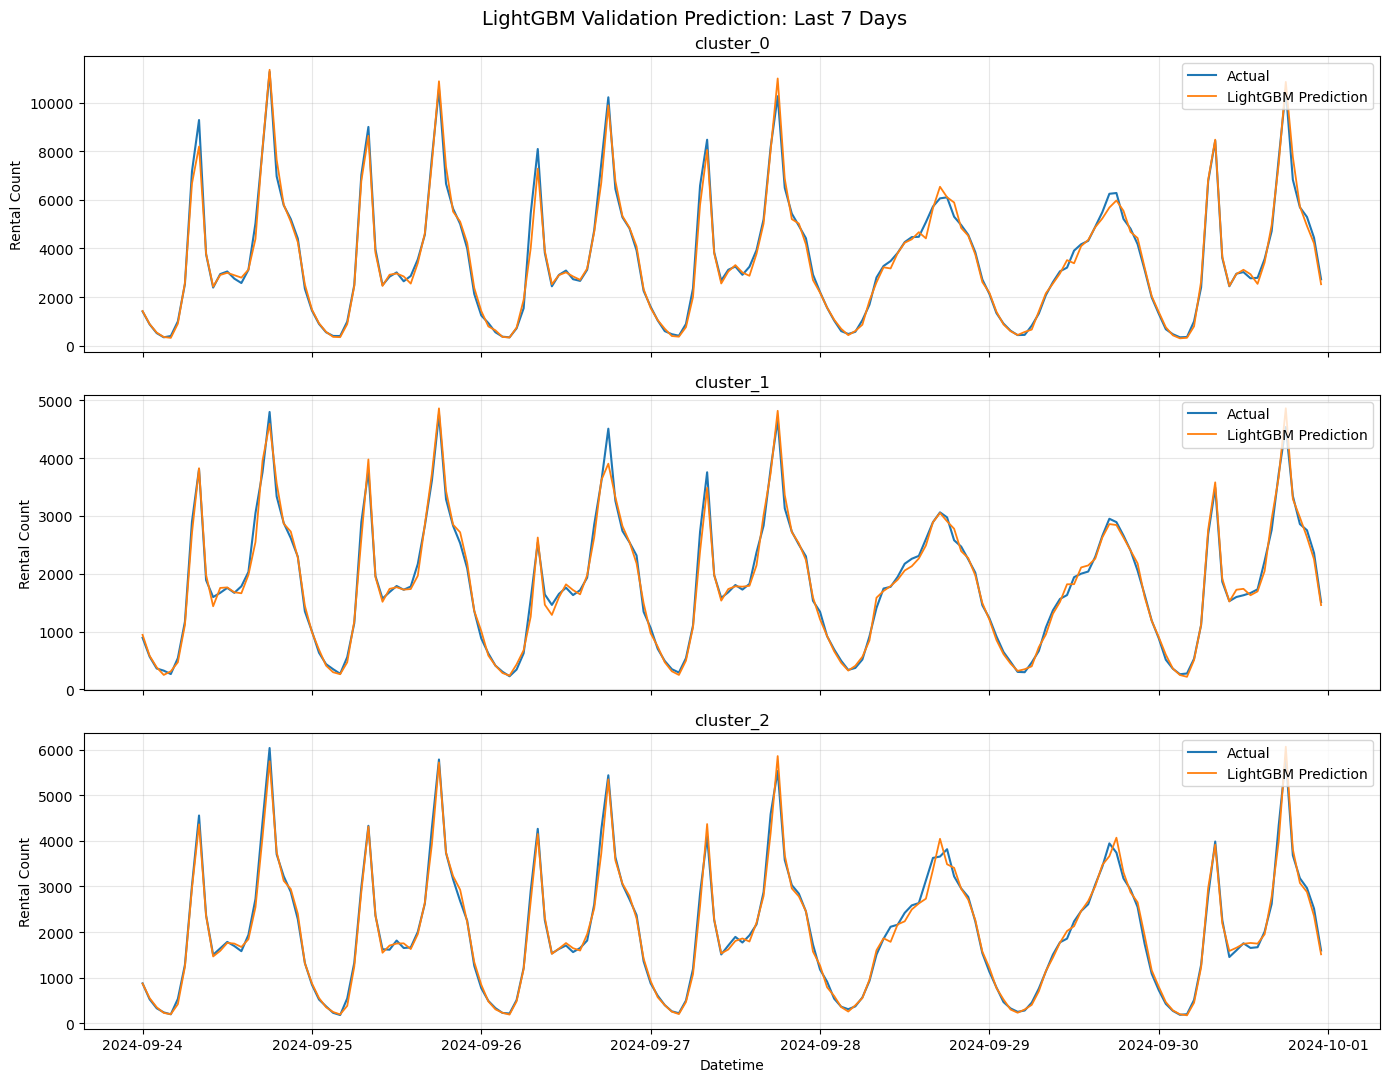

[통합 #8 LightGBM 검증 결과]
학습 행 수: 38,880행
검증 행 수: 6,624행
테스트 행 수: 6,624행
입력 변수 수: 11개
최적 반복 횟수: 921회
학습 소요시간: 0.7초
음수 예측값: 3개
테스트 성능 평가 수행 여부: False

[LightGBM 군집별 및 Macro Average 성능]


,split,model,cluster_label,observation_count,RMSE,MAE
0,validation,LightGBM,cluster_0,2208,395.894,228.426
1,validation,LightGBM,cluster_1,2208,194.226,117.269
2,validation,LightGBM,cluster_2,2208,218.660,126.364
3,validation,LightGBM,Macro Average,6624,269.593,157.353



[기준모델·SARIMA·LightGBM 검증 성능 비교]


,split,model,cluster_label,observation_count,RMSE,MAE
0,validation,LightGBM,cluster_0,2208,395.894,228.426
1,validation,Selected SARIMA_B,cluster_0,2208,807.983,471.713
2,validation,Daily Naive (lag_24),cluster_0,2208,1514.047,852.585
3,validation,Weekly Naive (lag_168),cluster_0,2208,1558.665,861.961
4,validation,LightGBM,cluster_1,2208,194.226,117.269
5,validation,Selected SARIMA_B,cluster_1,2208,347.554,213.423
6,validation,Daily Naive (lag_24),cluster_1,2208,720.033,431.161
7,validation,Weekly Naive (lag_168),cluster_1,2208,763.651,455.105
8,validation,LightGBM,cluster_2,2208,218.660,126.364
9,validation,Selected SARIMA_B,cluster_2,2208,424.423,254.201



[Macro Average 모델 순위]


...


[LightGBM 성능 개선율]


,comparison_target,target_RMSE,LightGBM_RMSE,RMSE_improvement_pct,target_MAE,LightGBM_MAE,MAE_improvement_pct
0,Daily Naive (lag_24),1018.878,269.593,73.54,588.318,157.353,73.254
1,Selected SARIMA_B,526.653,269.593,48.81,313.112,157.353,49.745



[LightGBM 변수 중요도]


,feature,gain_importance,importance_pct
0,lag_1,5.884935e+11,65.741
1,lag_168,1.671437e+11,18.672
2,lag_24,6.433475e+10,7.187
3,hour,3.529863e+10,3.943
4,lag_3,1.455320e+10,1.626
5,lag_2,1.249663e+10,1.396
6,weekday,6.632522e+09,0.741
7,lag_48,2.694329e+09,0.301
8,month,1.934310e+09,0.216
9,cluster_id,1.258410e+09,0.141



[저장된 그림]
- outputs\figures\lightgbm_validation_last_week.png

[저장된 결과 파일]
- outputs\metrics\lightgbm_validation_metrics.csv (355 bytes)
- outputs\metrics\validation_model_comparison.csv (1,375 bytes)
- outputs\metrics\lightgbm_improvement_summary.csv (375 bytes)
- outputs\metrics\lightgbm_feature_importance.csv (546 bytes)
- outputs\metrics\lightgbm_selected_config.csv (209 bytes)
- outputs\predictions\lightgbm_validation_predictions.csv (618,730 bytes)
- outputs\models\lightgbm_selected_model.txt (2,544,328 bytes)

LightGBM은 세 군집을 하나의 모델로 학습했으며 군집 번호를 입력 변수로 사용했다.
모든 시차 변수는 예측 시점보다 이전에 관측된 실제 수요만 참조한다.
검증 구간의 과거 실제 수요는 1시간 앞 예측에 사용할 수 있다고 가정했다.
최적 트리 수는 검증 RMSE 기반 조기 종료로 결정했다.


In [8]:
import time
from IPython.display import display

try:
    from lightgbm import (
        LGBMRegressor,
        early_stopping,
        log_evaluation,
    )

except ImportError as error:
    raise ImportError(
        "LightGBM이 설치되어 있지 않다. "
    ) from error


# 1) 이전 단계에서 생성된 객체를 확인한다.

required_objects = [
    "pd",
    "np",
    "plt",
    "ROOT",
    "FIGURES_DIR",
    "modeling_split_data",
    "baseline_metrics",
    "selected_sarima_metrics",
    "DATETIME_COLUMN",
    "CLUSTER_ID_COLUMN",
    "CLUSTER_LABEL_COLUMN",
    "TARGET_COLUMN",
]


missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]


if missing_objects:
    raise NameError(
        "LightGBM 모델링에 필요한 객체가 없다: "
        f"{missing_objects}. "
        "#6과 #7셀을 먼저 실행해야 한다."
    )


required_columns = {
    DATETIME_COLUMN,
    CLUSTER_ID_COLUMN,
    CLUSTER_LABEL_COLUMN,
    TARGET_COLUMN,
    "split",
}


missing_columns = sorted(
    required_columns
    - set(modeling_split_data.columns)
)


if missing_columns:
    raise KeyError(
        "LightGBM 모델링에 필요한 컬럼이 없다: "
        f"{missing_columns}"
    )


# 2) 달력 변수와 시차 변수를 생성한다.

lightgbm_data = (
    modeling_split_data[
        [
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
            TARGET_COLUMN,
            "split",
        ]
    ]
    .copy()
    .sort_values(
        [
            CLUSTER_ID_COLUMN,
            DATETIME_COLUMN,
        ]
    )
    .reset_index(drop=True)
)


lightgbm_data[
    DATETIME_COLUMN
] = pd.to_datetime(
    lightgbm_data[
        DATETIME_COLUMN
    ]
)


lightgbm_data[
    "hour"
] = (
    lightgbm_data[
        DATETIME_COLUMN
    ]
    .dt
    .hour
    .astype("int64")
)


lightgbm_data[
    "weekday"
] = (
    lightgbm_data[
        DATETIME_COLUMN
    ]
    .dt
    .dayofweek
    .astype("int64")
)


lightgbm_data[
    "month"
] = (
    lightgbm_data[
        DATETIME_COLUMN
    ]
    .dt
    .month
    .astype("int64")
)


lightgbm_data[
    "is_weekend"
] = (
    lightgbm_data[
        "weekday"
    ]
    .ge(5)
    .astype("int64")
)


LAG_HOURS = [
    1,
    2,
    3,
    24,
    48,
    168,
]


for lag_hour in LAG_HOURS:

    lightgbm_data[
        f"lag_{lag_hour}"
    ] = (
        lightgbm_data
        .groupby(
            CLUSTER_ID_COLUMN,
            observed=True,
        )[
            TARGET_COLUMN
        ]
        .shift(
            lag_hour
        )
    )


LIGHTGBM_FEATURES = [
    CLUSTER_ID_COLUMN,
    "hour",
    "weekday",
    "month",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
]


# 3) 학습·검증 데이터를 준비한다.

lightgbm_train = (
    lightgbm_data
    .loc[
        lightgbm_data[
            "split"
        ]
        .eq("train")
    ]
    .dropna(
        subset=LIGHTGBM_FEATURES
    )
    .copy()
    .reset_index(drop=True)
)


lightgbm_validation = (
    lightgbm_data
    .loc[
        lightgbm_data[
            "split"
        ]
        .eq("validation")
    ]
    .copy()
    .reset_index(drop=True)
)


lightgbm_test = (
    lightgbm_data
    .loc[
        lightgbm_data[
            "split"
        ]
        .eq("test")
    ]
    .copy()
    .reset_index(drop=True)
)


if lightgbm_train.empty:
    raise ValueError(
        "LightGBM 학습 데이터가 비어 있다."
    )


if lightgbm_validation.empty:
    raise ValueError(
        "LightGBM 검증 데이터가 비어 있다."
    )


validation_feature_missing_count = int(
    lightgbm_validation[
        LIGHTGBM_FEATURES
    ]
    .isna()
    .sum()
    .sum()
)


if validation_feature_missing_count != 0:
    raise ValueError(
        "검증 구간의 입력 변수에 결측치가 있다: "
        f"{validation_feature_missing_count:,}개"
    )


test_feature_missing_count = int(
    lightgbm_test[
        LIGHTGBM_FEATURES
    ]
    .isna()
    .sum()
    .sum()
)


if test_feature_missing_count != 0:
    raise ValueError(
        "테스트 구간의 입력 변수에 결측치가 있다: "
        f"{test_feature_missing_count:,}개"
    )


X_train = (
    lightgbm_train[
        LIGHTGBM_FEATURES
    ]
)


y_train = (
    lightgbm_train[
        TARGET_COLUMN
    ]
    .astype("float64")
)


X_validation = (
    lightgbm_validation[
        LIGHTGBM_FEATURES
    ]
)


y_validation = (
    lightgbm_validation[
        TARGET_COLUMN
    ]
    .astype("float64")
)


# 테스트 입력 변수는 생성만 하고 성능 평가는 수행하지 않는다.

X_test = (
    lightgbm_test[
        LIGHTGBM_FEATURES
    ]
)


# 4) 기본 LightGBM 모델을 학습한다.

LIGHTGBM_PARAMS = {
    "objective": "regression",
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": 8,
    "min_child_samples": 30,
    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.9,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}


lightgbm_model = LGBMRegressor(
    **LIGHTGBM_PARAMS
)


fit_start_time = time.perf_counter()


lightgbm_model.fit(
    X_train,
    y_train,
    eval_set=[
        (
            X_validation,
            y_validation,
        )
    ],
    eval_metric="rmse",
    categorical_feature=[
        CLUSTER_ID_COLUMN,
    ],
    callbacks=[
        early_stopping(
            stopping_rounds=50,
            verbose=False,
        ),
        log_evaluation(0),
    ],
)


lightgbm_fit_seconds = (
    time.perf_counter()
    - fit_start_time
)


LIGHTGBM_BEST_ITERATION = int(
    lightgbm_model.best_iteration_
)


if LIGHTGBM_BEST_ITERATION <= 0:
    raise ValueError(
        "LightGBM 최적 반복 횟수가 정상적으로 결정되지 않았다."
    )


# 5) 검증 구간의 예측값을 생성한다.

raw_validation_prediction = (
    lightgbm_model
    .predict(
        X_validation,
        num_iteration=(
            LIGHTGBM_BEST_ITERATION
        ),
    )
    .astype("float64")
)


if (
    len(raw_validation_prediction)
    != len(lightgbm_validation)
):
    raise ValueError(
        "검증 예측값 수가 검증 데이터 행 수와 일치하지 않는다."
    )


negative_prediction_count = int(
    (
        raw_validation_prediction
        < 0
    )
    .sum()
)


validation_prediction = np.maximum(
    raw_validation_prediction,
    0,
)


lightgbm_validation_predictions = (
    lightgbm_validation[
        [
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
            TARGET_COLUMN,
        ]
    ]
    .copy()
    .rename(
        columns={
            TARGET_COLUMN: "actual",
        }
    )
)


lightgbm_validation_predictions[
    "raw_prediction"
] = raw_validation_prediction


lightgbm_validation_predictions[
    "prediction"
] = validation_prediction


lightgbm_validation_predictions[
    "residual"
] = (
    lightgbm_validation_predictions[
        "actual"
    ]
    - lightgbm_validation_predictions[
        "prediction"
    ]
)


# 6) 군집별 RMSE와 MAE를 계산한다.

metric_records = []


for (
    cluster_label,
    cluster_data,
) in (
    lightgbm_validation_predictions
    .groupby(
        CLUSTER_LABEL_COLUMN,
        observed=True,
    )
):

    actual = (
        cluster_data[
            "actual"
        ]
        .to_numpy(
            dtype="float64"
        )
    )

    prediction = (
        cluster_data[
            "prediction"
        ]
        .to_numpy(
            dtype="float64"
        )
    )

    error = (
        actual
        - prediction
    )

    rmse = float(
        np.sqrt(
            np.mean(
                error ** 2
            )
        )
    )

    mae = float(
        np.mean(
            np.abs(
                error
            )
        )
    )


    metric_records.append(
        {
            "split": "validation",
            "model": "LightGBM",
            "cluster_label": (
                cluster_label
            ),
            "observation_count": int(
                len(
                    cluster_data
                )
            ),
            "RMSE": rmse,
            "MAE": mae,
        }
    )


lightgbm_cluster_metrics = pd.DataFrame(
    metric_records
)


if len(lightgbm_cluster_metrics) != 3:
    raise ValueError(
        "LightGBM 군집별 평가 결과가 3개 생성되지 않았다."
    )


lightgbm_macro_metric = pd.DataFrame(
    {
        "split": [
            "validation"
        ],
        "model": [
            "LightGBM"
        ],
        "cluster_label": [
            "Macro Average"
        ],
        "observation_count": [
            int(
                lightgbm_cluster_metrics[
                    "observation_count"
                ]
                .sum()
            )
        ],
        "RMSE": [
            float(
                lightgbm_cluster_metrics[
                    "RMSE"
                ]
                .mean()
            )
        ],
        "MAE": [
            float(
                lightgbm_cluster_metrics[
                    "MAE"
                ]
                .mean()
            )
        ],
    }
)


lightgbm_validation_metrics = pd.concat(
    [
        lightgbm_cluster_metrics,
        lightgbm_macro_metric,
    ],
    ignore_index=True,
)


# 7) 기준모델·SARIMA·LightGBM을 비교한다.

validation_baseline_metrics = (
    baseline_metrics
    .loc[
        baseline_metrics[
            "split"
        ]
        .eq("validation")
    ]
    .copy()
)


validation_model_comparison = pd.concat(
    [
        validation_baseline_metrics,
        selected_sarima_metrics,
        lightgbm_validation_metrics,
    ],
    ignore_index=True,
)


cluster_sort_map = {
    "cluster_0": 0,
    "cluster_1": 1,
    "cluster_2": 2,
    "Macro Average": 3,
}


validation_model_comparison[
    "_cluster_order"
] = (
    validation_model_comparison[
        "cluster_label"
    ]
    .map(
        cluster_sort_map
    )
)


validation_model_comparison = (
    validation_model_comparison
    .sort_values(
        [
            "_cluster_order",
            "RMSE",
        ]
    )
    .drop(
        columns=[
            "_cluster_order",
        ]
    )
    .reset_index(drop=True)
)


macro_model_comparison = (
    validation_model_comparison
    .loc[
        validation_model_comparison[
            "cluster_label"
        ]
        .eq(
            "Macro Average"
        )
    ]
    .sort_values(
        [
            "RMSE",
            "MAE",
        ]
    )
    .reset_index(drop=True)
)


best_validation_model = (
    macro_model_comparison
    .head(1)
    .copy()
)


# 8) 기준모델 및 SARIMA 대비 개선율을 계산한다.

lightgbm_macro_row = (
    lightgbm_macro_metric
    .iloc[0]
)


best_baseline_macro_row = (
    validation_baseline_metrics
    .loc[
        validation_baseline_metrics[
            "cluster_label"
        ]
        .eq(
            "Macro Average"
        )
    ]
    .sort_values(
        "RMSE"
    )
    .iloc[0]
)


sarima_macro_row = (
    selected_sarima_metrics
    .loc[
        selected_sarima_metrics[
            "cluster_label"
        ]
        .eq(
            "Macro Average"
        )
    ]
    .iloc[0]
)


lightgbm_improvement_summary = pd.DataFrame(
    {
        "comparison_target": [
            best_baseline_macro_row[
                "model"
            ],
            sarima_macro_row[
                "model"
            ],
        ],
        "target_RMSE": [
            best_baseline_macro_row[
                "RMSE"
            ],
            sarima_macro_row[
                "RMSE"
            ],
        ],
        "LightGBM_RMSE": [
            lightgbm_macro_row[
                "RMSE"
            ],
            lightgbm_macro_row[
                "RMSE"
            ],
        ],
        "RMSE_improvement_pct": [
            (
                (
                    best_baseline_macro_row[
                        "RMSE"
                    ]
                    - lightgbm_macro_row[
                        "RMSE"
                    ]
                )
                / best_baseline_macro_row[
                    "RMSE"
                ]
                * 100
            ),
            (
                (
                    sarima_macro_row[
                        "RMSE"
                    ]
                    - lightgbm_macro_row[
                        "RMSE"
                    ]
                )
                / sarima_macro_row[
                    "RMSE"
                ]
                * 100
            ),
        ],
        "target_MAE": [
            best_baseline_macro_row[
                "MAE"
            ],
            sarima_macro_row[
                "MAE"
            ],
        ],
        "LightGBM_MAE": [
            lightgbm_macro_row[
                "MAE"
            ],
            lightgbm_macro_row[
                "MAE"
            ],
        ],
        "MAE_improvement_pct": [
            (
                (
                    best_baseline_macro_row[
                        "MAE"
                    ]
                    - lightgbm_macro_row[
                        "MAE"
                    ]
                )
                / best_baseline_macro_row[
                    "MAE"
                ]
                * 100
            ),
            (
                (
                    sarima_macro_row[
                        "MAE"
                    ]
                    - lightgbm_macro_row[
                        "MAE"
                    ]
                )
                / sarima_macro_row[
                    "MAE"
                ]
                * 100
            ),
        ],
    }
)


# 9) 변수 중요도를 계산한다.

feature_importance = pd.DataFrame(
    {
        "feature": (
            LIGHTGBM_FEATURES
        ),
        "gain_importance": (
            lightgbm_model
            .booster_
            .feature_importance(
                importance_type="gain"
            )
        ),
    }
)


total_gain_importance = float(
    feature_importance[
        "gain_importance"
    ]
    .sum()
)


if total_gain_importance <= 0:
    raise ValueError(
        "LightGBM 변수 중요도가 정상적으로 계산되지 않았다."
    )


feature_importance[
    "importance_pct"
] = (
    feature_importance[
        "gain_importance"
    ]
    / total_gain_importance
    * 100
)


feature_importance = (
    feature_importance
    .sort_values(
        "gain_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


# 10) 검증 마지막 7일의 실제값과 예측값을 시각화한다.

validation_plot_end = (
    lightgbm_validation_predictions[
        DATETIME_COLUMN
    ]
    .max()
)


validation_plot_start = (
    validation_plot_end
    - pd.Timedelta(
        hours=167
    )
)


validation_plot_data = (
    lightgbm_validation_predictions
    .loc[
        lightgbm_validation_predictions[
            DATETIME_COLUMN
        ]
        .between(
            validation_plot_start,
            validation_plot_end,
        )
    ]
    .copy()
)


cluster_labels = (
    lightgbm_validation_predictions[
        [
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
        ]
    ]
    .drop_duplicates()
    .sort_values(
        CLUSTER_ID_COLUMN
    )[
        CLUSTER_LABEL_COLUMN
    ]
    .tolist()
)


FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


lightgbm_validation_figure_path = (
    FIGURES_DIR
    / "lightgbm_validation_last_week.png"
)


figure, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(
        14,
        11,
    ),
    sharex=True,
)


for axis, cluster_label in zip(
    axes,
    cluster_labels,
):

    cluster_plot_data = (
        validation_plot_data
        .loc[
            validation_plot_data[
                CLUSTER_LABEL_COLUMN
            ]
            .eq(
                cluster_label
            )
        ]
        .sort_values(
            DATETIME_COLUMN
        )
    )


    axis.plot(
        cluster_plot_data[
            DATETIME_COLUMN
        ],
        cluster_plot_data[
            "actual"
        ],
        label="Actual",
        linewidth=1.5,
    )


    axis.plot(
        cluster_plot_data[
            DATETIME_COLUMN
        ],
        cluster_plot_data[
            "prediction"
        ],
        label="LightGBM Prediction",
        linewidth=1.3,
    )


    axis.set_title(
        cluster_label
    )

    axis.set_ylabel(
        "Rental Count"
    )

    axis.grid(
        alpha=0.3
    )

    axis.legend()


axes[-1].set_xlabel(
    "Datetime"
)


figure.suptitle(
    "LightGBM Validation Prediction: Last 7 Days",
    fontsize=14,
)


plt.tight_layout()

plt.savefig(
    lightgbm_validation_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


# 11) 결과 저장 경로를 설정한다.

METRICS_DIR = (
    ROOT
    / "outputs"
    / "metrics"
)


PREDICTIONS_DIR = (
    ROOT
    / "outputs"
    / "predictions"
)


MODELS_DIR = (
    ROOT
    / "outputs"
    / "models"
)


for directory in [
    METRICS_DIR,
    PREDICTIONS_DIR,
    MODELS_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


lightgbm_metrics_path = (
    METRICS_DIR
    / "lightgbm_validation_metrics.csv"
)


model_comparison_path = (
    METRICS_DIR
    / "validation_model_comparison.csv"
)


improvement_path = (
    METRICS_DIR
    / "lightgbm_improvement_summary.csv"
)


feature_importance_path = (
    METRICS_DIR
    / "lightgbm_feature_importance.csv"
)


selected_config_path = (
    METRICS_DIR
    / "lightgbm_selected_config.csv"
)


prediction_path = (
    PREDICTIONS_DIR
    / "lightgbm_validation_predictions.csv"
)


model_path = (
    MODELS_DIR
    / "lightgbm_selected_model.txt"
)


# 12) 설정과 결과를 저장한다.

lightgbm_selected_config = pd.DataFrame(
    {
        "learning_rate": [
            LIGHTGBM_PARAMS[
                "learning_rate"
            ]
        ],
        "num_leaves": [
            LIGHTGBM_PARAMS[
                "num_leaves"
            ]
        ],
        "max_depth": [
            LIGHTGBM_PARAMS[
                "max_depth"
            ]
        ],
        "min_child_samples": [
            LIGHTGBM_PARAMS[
                "min_child_samples"
            ]
        ],
        "best_iteration": [
            LIGHTGBM_BEST_ITERATION
        ],
        "feature_count": [
            len(
                LIGHTGBM_FEATURES
            )
        ],
        "validation_macro_RMSE": [
            lightgbm_macro_row[
                "RMSE"
            ]
        ],
        "validation_macro_MAE": [
            lightgbm_macro_row[
                "MAE"
            ]
        ],
        "test_evaluated": [
            False
        ],
    }
)


lightgbm_validation_metrics.to_csv(
    lightgbm_metrics_path,
    index=False,
    encoding="utf-8-sig",
)


validation_model_comparison.to_csv(
    model_comparison_path,
    index=False,
    encoding="utf-8-sig",
)


lightgbm_improvement_summary.to_csv(
    improvement_path,
    index=False,
    encoding="utf-8-sig",
)


feature_importance.to_csv(
    feature_importance_path,
    index=False,
    encoding="utf-8-sig",
)


lightgbm_selected_config.to_csv(
    selected_config_path,
    index=False,
    encoding="utf-8-sig",
)


lightgbm_validation_predictions.to_csv(
    prediction_path,
    index=False,
    encoding="utf-8-sig",
)


# 한글 경로에서 저장 오류가 발생할 수 있어, 문자열로 변환한 뒤 Python으로 직접 저장한다.

lightgbm_model_string = (
    lightgbm_model
    .booster_
    .model_to_string(
        num_iteration=(
            LIGHTGBM_BEST_ITERATION
        )
    )
)


model_path.write_text(
    lightgbm_model_string,
    encoding="utf-8",
)


saved_result_paths = [
    lightgbm_metrics_path,
    model_comparison_path,
    improvement_path,
    feature_importance_path,
    selected_config_path,
    prediction_path,
    model_path,
    lightgbm_validation_figure_path,
]


for saved_path in saved_result_paths:

    if not saved_path.exists():
        raise FileNotFoundError(
            f"결과 파일이 저장되지 않았다: {saved_path}"
        )

    if saved_path.stat().st_size == 0:
        raise OSError(
            f"저장된 결과 파일의 크기가 0이다: {saved_path}"
        )


# 13) 핵심 결과만 출력한다.

print("[통합 #8 LightGBM 검증 결과]")

print(
    f"학습 행 수: "
    f"{len(lightgbm_train):,}행"
)

print(
    f"검증 행 수: "
    f"{len(lightgbm_validation):,}행"
)

print(
    f"테스트 행 수: "
    f"{len(lightgbm_test):,}행"
)

print(
    f"입력 변수 수: "
    f"{len(LIGHTGBM_FEATURES):,}개"
)

print(
    f"최적 반복 횟수: "
    f"{LIGHTGBM_BEST_ITERATION:,}회"
)

print(
    f"학습 소요시간: "
    f"{lightgbm_fit_seconds:,.1f}초"
)

print(
    f"음수 예측값: "
    f"{negative_prediction_count:,}개"
)

print(
    "테스트 성능 평가 수행 여부: "
    "False"
)


print("\n[LightGBM 군집별 및 Macro Average 성능]")

display(
    lightgbm_validation_metrics
    .round(
        {
            "RMSE": 3,
            "MAE": 3,
        }
    )
)


print("\n[기준모델·SARIMA·LightGBM 검증 성능 비교]")

display(
    validation_model_comparison
    .round(
        {
            "RMSE": 3,
            "MAE": 3,
        }
    )
)


print("\n[Macro Average 모델 순위]")

display(
    macro_model_comparison
    .round(
        {
            "RMSE": 3,
            "MAE": 3,
        }
    )
)


print("\n[LightGBM 성능 개선율]")

display(
    lightgbm_improvement_summary
    .round(
        {
            "target_RMSE": 3,
            "LightGBM_RMSE": 3,
            "RMSE_improvement_pct": 3,
            "target_MAE": 3,
            "LightGBM_MAE": 3,
            "MAE_improvement_pct": 3,
        }
    )
)


print("\n[LightGBM 변수 중요도]")

display(
    feature_importance
    .round(
        {
            "gain_importance": 3,
            "importance_pct": 3,
        }
    )
)


print("\n[저장된 그림]")

print(
    f"- {lightgbm_validation_figure_path.relative_to(ROOT)}"
)


print("\n[저장된 결과 파일]")

for saved_path in saved_result_paths[:-1]:

    print(
        f"- {saved_path.relative_to(ROOT)} "
        f"({saved_path.stat().st_size:,} bytes)"
    )


print(
    "\nLightGBM은 세 군집을 하나의 모델로 학습했으며 "
    "군집 번호를 입력 변수로 사용했다."
)

print(
    "모든 시차 변수는 예측 시점보다 이전에 관측된 "
    "실제 수요만 참조한다."
)

print(
    "검증 구간의 과거 실제 수요는 "
    "1시간 앞 예측에 사용할 수 있다고 가정했다."
)

print(
    "최적 트리 수는 검증 RMSE 기반 조기 종료로 결정했다."
)


## 9. 최종 테스트 평가 및 모델 비교

검증 결과를 바탕으로 SARIMA와 LightGBM의 최종 설정을 확정하였다.

* SARIMA: `(1, 0, 1) × (1, 1, 0, 24)`
* LightGBM: 검증 단계에서 확정한 11개 입력 변수와 최적 반복 횟수 `921` 사용

최종 평가에서는 학습 데이터와 검증 데이터를 합쳐 모델을 다시 학습한 뒤, 모델 선택에 사용하지 않은 테스트 기간에서 성능을 비교한다.

### 9.1 최종 평가 방법

테스트 기간은 `2024-10-01 00:00:00`부터 `2024-12-31 23:00:00`까지이며, 총 6,624개의 `datetime × cluster_id` 관측치로 구성된다.

모든 모델은 각 군집의 다음 1시간 수요를 예측한다.

* 일간 나이브: 전일 같은 시간의 실제 수요 사용
* 주간 나이브: 전주 같은 요일·시간의 실제 수요 사용
* SARIMA: 직전까지 관측된 실제 수요를 반영한 1시간 앞 순차 예측
* LightGBM: 과거 수요 시차와 예측 시점의 달력 정보를 이용한 1시간 앞 예측

SARIMA와 LightGBM은 검증 단계에서 확정한 설정을 그대로 사용하며, 테스트 결과를 확인한 이후 모델이나 입력 변수를 다시 변경하지 않는다.

### 9.2 최종 테스트 성능

세 군집의 성능을 동일한 비중으로 평균한 Macro 성능은 다음과 같다.

| 순위 | 모델       | Macro RMSE | Macro MAE |
| -: | -------- | ---------: | --------: |
|  1 | LightGBM |    190.724 |   113.054 |
|  2 | SARIMA   |    460.629 |   260.015 |
|  3 | 주간 나이브   |    776.525 |   427.048 |
|  4 | 일간 나이브   |    865.435 |   464.011 |

LightGBM은 최종 테스트에서 가장 낮은 RMSE와 MAE를 기록하였다.

SARIMA와 비교했을 때 LightGBM의 성능 개선율은 다음과 같다.

* RMSE 개선율: `58.595%`
* MAE 개선율: `56.520%`

두 나이브 기준모델보다도 큰 폭으로 낮은 오차를 기록하여, 단순히 전일 또는 전주의 수요를 반복하는 방법보다 여러 시차와 달력 패턴을 함께 학습하는 방식이 더 효과적임을 확인하였다.

### 9.3 LightGBM의 군집별 성능

LightGBM의 군집별 테스트 RMSE는 다음과 같다.

| 군집        |    RMSE |
| --------- | ------: |
| cluster_0 | 300.230 |
| cluster_1 | 131.507 |
| cluster_2 | 140.436 |

`cluster_0`은 다른 두 군집보다 RMSE가 높게 나타났다. 이는 군집별 수요 규모와 변동성이 서로 다르기 때문에 동일한 절대 오차 지표에서도 차이가 발생할 수 있음을 보여준다.

Macro Average는 세 군집을 동일한 비중으로 반영하므로 수요 규모가 큰 특정 군집이 전체 평가 결과를 지나치게 지배하는 것을 방지한다.

### 9.4 예측값과 모델 진단

최종 테스트에서 LightGBM은 음수 예측값을 생성하지 않았다.

SARIMA에서는 67개의 음수 예측값이 발생했으며, 공공자전거 대여건수는 음수가 될 수 없으므로 평가 전에 0으로 조정하였다. 이는 선형 구조를 기반으로 하는 SARIMA가 수요가 낮은 일부 시점에서 현실적으로 불가능한 값을 생성할 수 있다는 한계를 보여준다.

### 9.5 LightGBM 변수 중요도

LightGBM의 주요 변수 중요도는 다음과 같다.

| 변수        |     중요도 |
| --------- | ------: |
| `lag_1`   | 65.741% |
| `lag_168` | 18.672% |
| `lag_24`  |  7.187% |
| `hour`    |  3.943% |

직전 시간 수요인 `lag_1`의 중요도가 가장 높았으며, 전주 같은 요일·시간의 수요인 `lag_168`과 전일 같은 시간의 수요인 `lag_24`도 주요 변수로 나타났다.

이는 공공자전거 수요가 단기 연속성과 일간·주간 반복 패턴을 강하게 가진다는 탐색적 분석 결과와 일치한다. 다만 변수 중요도는 예측에 활용된 정도를 나타내며, 해당 변수가 수요 변화를 직접 일으킨다는 인과관계를 의미하지는 않는다.

### 9.6 최종 결론과 한계

최종 테스트 결과 LightGBM이 네 모델 중 가장 우수한 일반화 성능을 보였다. 특히 여러 시간 규모의 시차 변수와 달력 정보를 하나의 비선형 모델에서 함께 학습한 것이 성능 향상에 기여한 것으로 해석할 수 있다.

다만 이번 결과에는 다음과 같은 한계가 있다.

* 예측 단위는 개별 대여소가 아니라 GPS 기반 공간 군집이다.
* 미래 기상예보, 공휴일, 행사와 같은 외부 정보는 사용하지 않았다.
* 테스트 기간은 2024년 4분기로 제한되어 있다.
* `2023-09-07 08:00~10:00`의 데이터 품질 이상 의심 구간은 원본 그대로 유지하였다.
* 변수 중요도는 예측 기여도이며 인과관계의 근거가 아니다.

따라서 본 결과는 과거 수요와 달력 정보만 사용한 군집 단위 1시간 앞 수요예측의 기본 성능으로 해석한다.


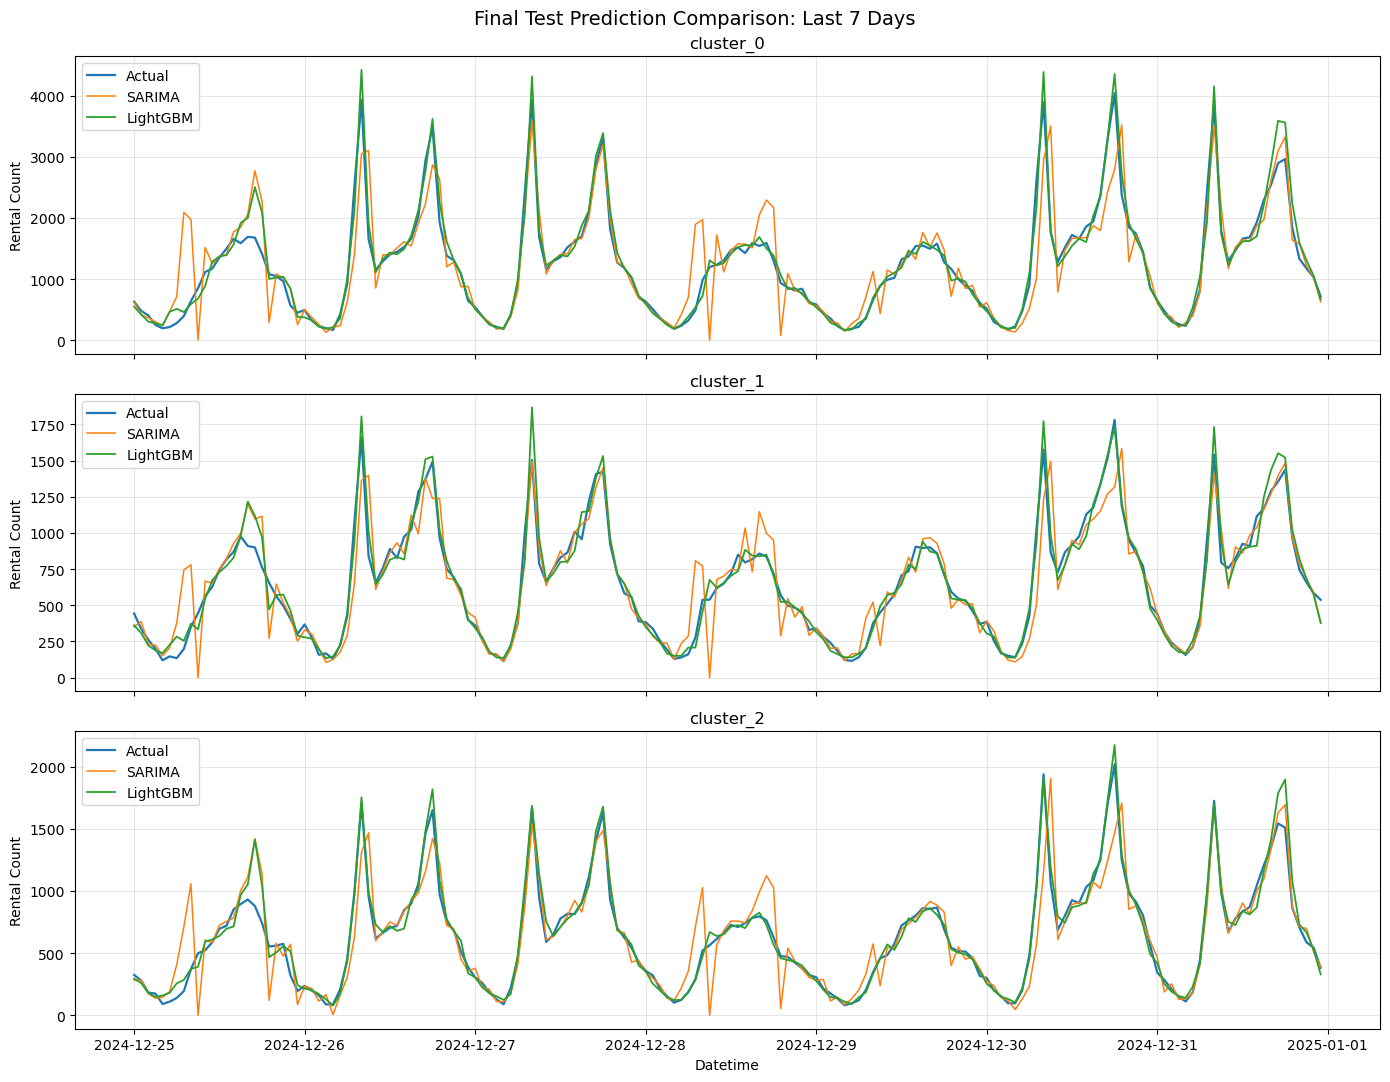

[통합 #9 최종 테스트 평가 결과]
최종 학습 행 수: 45,504행
테스트 행 수: 6,624행
테스트 기간: 2024-10-01 00:00:00 ~ 2024-12-31 23:00:00
LightGBM 학습 시간: 0.9초
LightGBM 음수 예측값: 0개
SARIMA 음수 예측값: 67개
테스트 성능 평가 수행 여부: True

[최종 테스트 군집별 및 Macro Average 성능]


,split,model,cluster_label,observation_count,RMSE,MAE
0,test,LightGBM,cluster_0,2208,300.230,174.359
1,test,SARIMA,cluster_0,2208,735.527,409.268
2,test,Weekly Naive (lag_168),cluster_0,2208,1160.094,630.913
3,test,Hourly Naive (lag_1),cluster_0,2208,1181.281,724.249
4,test,Daily Naive (lag_24),cluster_0,2208,1339.346,709.451
5,test,LightGBM,cluster_1,2208,131.507,82.274
6,test,SARIMA,cluster_1,2208,283.169,166.606
7,test,Hourly Naive (lag_1),cluster_1,2208,435.022,285.590
8,test,Weekly Naive (lag_168),cluster_1,2208,535.804,300.107
9,test,Daily Naive (lag_24),cluster_1,2208,573.190,311.430



[최종 테스트 Macro Average 순위]


,split,model,cluster_label,observation_count,RMSE,MAE
0,test,LightGBM,Macro Average,6624,190.724,113.054
1,test,SARIMA,Macro Average,6624,460.629,260.015
2,test,Hourly Naive (lag_1),Macro Average,6624,725.571,456.731
3,test,Weekly Naive (lag_168),Macro Average,6624,776.525,427.048
4,test,Daily Naive (lag_24),Macro Average,6624,865.435,464.011



[LightGBM 최종 성능 개선율]


,comparison_target,target_RMSE,LightGBM_RMSE,RMSE_improvement_pct,target_MAE,LightGBM_MAE,MAE_improvement_pct
0,SARIMA,460.629,190.724,58.595,260.015,113.054,56.520
1,Hourly Naive (lag_1),725.571,190.724,73.714,456.731,113.054,75.247
2,Weekly Naive (lag_168),776.525,190.724,75.439,427.048,113.054,73.527
3,Daily Naive (lag_24),865.435,190.724,77.962,464.011,113.054,75.636



[최종 SARIMA 학습 상태]


,cluster_label,converged,warning_count,fit_seconds,negative_prediction_count
0,cluster_0,True,0,12.9,27
1,cluster_1,True,0,12.4,18
2,cluster_2,True,0,10.7,22



[저장된 그림]
- outputs\figures\final_test_model_comparison_last_week.png

[저장된 최종 결과 파일]
- outputs\metrics\final_test_metrics.csv (1,549 bytes)
- outputs\metrics\final_test_macro_ranking.csv (444 bytes)
- outputs\metrics\final_test_improvement_summary.csv (626 bytes)
- outputs\metrics\final_sarima_fit_summary.csv (198 bytes)
- outputs\metrics\final_model_config.csv (248 bytes)
- outputs\predictions\final_test_predictions.csv (866,140 bytes)
- outputs\models\lightgbm_final_model.txt (2,555,562 bytes)

모델 설정은 검증 단계에서 확정했으며 테스트 결과를 이용해 다시 변경하지 않았다.
최종 모델은 학습 데이터와 검증 데이터를 합쳐 다시 학습했다.
모든 모델은 직전까지 관측된 실제 수요를 사용하는 1시간 앞 예측 조건으로 비교했다.

03_modeling_evaluation.ipynb 실행이 완료되었다.


In [9]:
import time
import warnings

from IPython.display import display
from lightgbm import LGBMRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX


# 1) 이전 단계에서 생성된 객체를 확인한다.

required_objects = [
    "pd",
    "np",
    "plt",
    "ROOT",
    "FIGURES_DIR",
    "modeling_split_data",
    "SELECTED_SARIMA_ORDER",
    "SELECTED_SARIMA_SEASONAL_ORDER",
    "LIGHTGBM_PARAMS",
    "LIGHTGBM_BEST_ITERATION",
    "LIGHTGBM_FEATURES",
    "DATETIME_COLUMN",
    "CLUSTER_ID_COLUMN",
    "CLUSTER_LABEL_COLUMN",
    "TARGET_COLUMN",
]


missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]


if missing_objects:
    raise NameError(
        "최종 테스트 평가에 필요한 객체가 없다: "
        f"{missing_objects}. "
        "#6, #7, #8 셀을 먼저 실행해야 한다."
    )


# 2) 최종 평가용 달력 변수와 시차 변수를 생성한다.

final_model_data = (
    modeling_split_data[
        [
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
            TARGET_COLUMN,
            "split",
        ]
    ]
    .copy()
    .sort_values(
        [
            CLUSTER_ID_COLUMN,
            DATETIME_COLUMN,
        ]
    )
    .reset_index(drop=True)
)


final_model_data[
    DATETIME_COLUMN
] = pd.to_datetime(
    final_model_data[
        DATETIME_COLUMN
    ]
)


final_model_data[
    "hour"
] = (
    final_model_data[
        DATETIME_COLUMN
    ]
    .dt
    .hour
    .astype("int64")
)


final_model_data[
    "weekday"
] = (
    final_model_data[
        DATETIME_COLUMN
    ]
    .dt
    .dayofweek
    .astype("int64")
)


final_model_data[
    "month"
] = (
    final_model_data[
        DATETIME_COLUMN
    ]
    .dt
    .month
    .astype("int64")
)


final_model_data[
    "is_weekend"
] = (
    final_model_data[
        "weekday"
    ]
    .ge(5)
    .astype("int64")
)


FINAL_LAG_HOURS = [
    1,
    2,
    3,
    24,
    48,
    168,
]


for lag_hour in FINAL_LAG_HOURS:

    final_model_data[
        f"lag_{lag_hour}"
    ] = (
        final_model_data
        .groupby(
            CLUSTER_ID_COLUMN,
            observed=True,
        )[
            TARGET_COLUMN
        ]
        .shift(
            lag_hour
        )
    )


# 기준모델 예측값도 같은 데이터에서 생성한다.

final_model_data[
    "daily_naive_prediction"
] = (
    final_model_data[
        "lag_24"
    ]
)


final_model_data[
    "weekly_naive_prediction"
] = (
    final_model_data[
        "lag_168"
    ]
)


final_model_data[
    "hourly_naive_prediction"
] = (
    final_model_data[
        "lag_1"
    ]
)


# 3) 최종 학습 데이터와 테스트 데이터를 준비한다.

final_train_data = (
    final_model_data
    .loc[
        final_model_data[
            "split"
        ]
        .isin(
            [
                "train",
                "validation",
            ]
        )
    ]
    .dropna(
        subset=LIGHTGBM_FEATURES
    )
    .copy()
    .reset_index(drop=True)
)


final_test_data = (
    final_model_data
    .loc[
        final_model_data[
            "split"
        ]
        .eq("test")
    ]
    .copy()
    .reset_index(drop=True)
)


if final_train_data.empty:
    raise ValueError(
        "최종 학습 데이터가 비어 있다."
    )


if final_test_data.empty:
    raise ValueError(
        "테스트 데이터가 비어 있다."
    )


test_required_columns = (
    LIGHTGBM_FEATURES
    + [
        "hourly_naive_prediction",
        "daily_naive_prediction",
        "weekly_naive_prediction",
    ]
)


test_missing_count = int(
    final_test_data[
        test_required_columns
    ]
    .isna()
    .sum()
    .sum()
)


if test_missing_count != 0:
    raise ValueError(
        "테스트 입력 변수 또는 기준모델 예측값에 결측치가 있다: "
        f"{test_missing_count:,}개"
    )


X_final_train = (
    final_train_data[
        LIGHTGBM_FEATURES
    ]
)


y_final_train = (
    final_train_data[
        TARGET_COLUMN
    ]
    .astype("float64")
)


X_final_test = (
    final_test_data[
        LIGHTGBM_FEATURES
    ]
)


# 4) LightGBM을 학습+검증 데이터로 다시 학습한다.
# 검증 단계에서 확정한 최적 반복 횟수를 그대로 사용한다.
# 테스트 데이터는 모델 학습이나 설정 선택에 사용하지 않는다.

FINAL_LIGHTGBM_PARAMS = (
    LIGHTGBM_PARAMS.copy()
)


FINAL_LIGHTGBM_PARAMS[
    "n_estimators"
] = LIGHTGBM_BEST_ITERATION


final_lightgbm_model = LGBMRegressor(
    **FINAL_LIGHTGBM_PARAMS
)


lightgbm_fit_start = time.perf_counter()


final_lightgbm_model.fit(
    X_final_train,
    y_final_train,
    categorical_feature=[
        CLUSTER_ID_COLUMN,
    ],
)


final_lightgbm_fit_seconds = (
    time.perf_counter()
    - lightgbm_fit_start
)


raw_lightgbm_test_prediction = (
    final_lightgbm_model
    .predict(
        X_final_test,
        num_iteration=(
            LIGHTGBM_BEST_ITERATION
        ),
    )
    .astype("float64")
)


lightgbm_negative_count = int(
    (
        raw_lightgbm_test_prediction
        < 0
    )
    .sum()
)


lightgbm_test_prediction = np.maximum(
    raw_lightgbm_test_prediction,
    0,
)


# 5) SARIMA를 학습+검증 데이터로 다시 학습한다.

cluster_information = (
    final_model_data[
        [
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
        ]
    ]
    .drop_duplicates()
    .sort_values(
        CLUSTER_ID_COLUMN
    )
)


cluster_labels = (
    cluster_information[
        CLUSTER_LABEL_COLUMN
    ]
    .tolist()
)


sarima_prediction_frames = []
sarima_fit_records = []


for cluster_label in cluster_labels:

    cluster_train_series = (
        final_model_data
        .loc[
            (
                final_model_data[
                    CLUSTER_LABEL_COLUMN
                ]
                .eq(cluster_label)
            )
            & (
                final_model_data[
                    "split"
                ]
                .isin(
                    [
                        "train",
                        "validation",
                    ]
                )
            ),
            [
                DATETIME_COLUMN,
                TARGET_COLUMN,
            ],
        ]
        .sort_values(
            DATETIME_COLUMN
        )
        .set_index(
            DATETIME_COLUMN
        )[
            TARGET_COLUMN
        ]
        .astype("float64")
        .asfreq("h")
    )


    cluster_test_series = (
        final_model_data
        .loc[
            (
                final_model_data[
                    CLUSTER_LABEL_COLUMN
                ]
                .eq(cluster_label)
            )
            & (
                final_model_data[
                    "split"
                ]
                .eq("test")
            ),
            [
                DATETIME_COLUMN,
                TARGET_COLUMN,
            ],
        ]
        .sort_values(
            DATETIME_COLUMN
        )
        .set_index(
            DATETIME_COLUMN
        )[
            TARGET_COLUMN
        ]
        .astype("float64")
        .asfreq("h")
    )


    if cluster_train_series.isna().any():
        raise ValueError(
            f"{cluster_label} 최종 SARIMA 학습 시계열에 결측치가 있다."
        )


    if cluster_test_series.isna().any():
        raise ValueError(
            f"{cluster_label} SARIMA 테스트 시계열에 결측치가 있다."
        )


    fit_start = time.perf_counter()


    with warnings.catch_warnings(
        record=True
    ) as caught_warnings:

        warnings.simplefilter(
            "always"
        )


        sarima_model = SARIMAX(
            endog=cluster_train_series,
            order=SELECTED_SARIMA_ORDER,
            seasonal_order=(
                SELECTED_SARIMA_SEASONAL_ORDER
            ),
            trend=None,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )


        fitted_sarima = sarima_model.fit(
            disp=False,
            maxiter=50,
        )


    fit_seconds = (
        time.perf_counter()
        - fit_start
    )


    extended_sarima = (
        fitted_sarima
        .append(
            cluster_test_series,
            refit=False,
        )
    )


    test_prediction_result = (
        extended_sarima
        .get_prediction(
            start=len(
                cluster_train_series
            ),
            end=(
                len(
                    cluster_train_series
                )
                + len(
                    cluster_test_series
                )
                - 1
            ),
            dynamic=False,
        )
    )


    raw_sarima_prediction = np.asarray(
        test_prediction_result
        .predicted_mean,
        dtype="float64",
    )


    sarima_negative_count = int(
        (
            raw_sarima_prediction
            < 0
        )
        .sum()
    )


    sarima_test_prediction = np.maximum(
        raw_sarima_prediction,
        0,
    )


    sarima_prediction_frames.append(
        pd.DataFrame(
            {
                DATETIME_COLUMN: (
                    cluster_test_series.index
                ),
                CLUSTER_LABEL_COLUMN: (
                    cluster_label
                ),
                "sarima_raw_prediction": (
                    raw_sarima_prediction
                ),
                "sarima_prediction": (
                    sarima_test_prediction
                ),
            }
        )
    )


    sarima_fit_records.append(
        {
            "cluster_label": (
                cluster_label
            ),
            "converged": bool(
                fitted_sarima
                .mle_retvals
                .get(
                    "converged",
                    False,
                )
            ),
            "warning_count": int(
                len(
                    caught_warnings
                )
            ),
            "fit_seconds": (
                fit_seconds
            ),
            "negative_prediction_count": (
                sarima_negative_count
            ),
        }
    )


sarima_test_predictions = (
    pd.concat(
        sarima_prediction_frames,
        ignore_index=True,
    )
)


sarima_final_fit_summary = pd.DataFrame(
    sarima_fit_records
)


if not sarima_final_fit_summary[
    "converged"
].all():
    raise RuntimeError(
        "일부 최종 SARIMA 모델이 정상적으로 수렴하지 않았다."
    )


# 6) 모든 테스트 예측값을 하나의 데이터로 결합한다.

final_test_predictions = (
    final_test_data[
        [
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
            CLUSTER_LABEL_COLUMN,
            TARGET_COLUMN,
            "hourly_naive_prediction",
            "daily_naive_prediction",
            "weekly_naive_prediction",
        ]
    ]
    .copy()
    .rename(
        columns={
            TARGET_COLUMN: "actual",
        }
    )
)


final_test_predictions[
    "lightgbm_raw_prediction"
] = raw_lightgbm_test_prediction


final_test_predictions[
    "lightgbm_prediction"
] = lightgbm_test_prediction


final_test_predictions = (
    final_test_predictions
    .merge(
        sarima_test_predictions,
        on=[
            DATETIME_COLUMN,
            CLUSTER_LABEL_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            DATETIME_COLUMN,
            CLUSTER_ID_COLUMN,
        ]
    )
    .reset_index(drop=True)
)


prediction_columns = [
    "hourly_naive_prediction",
    "daily_naive_prediction",
    "weekly_naive_prediction",
    "sarima_prediction",
    "lightgbm_prediction",
]


prediction_missing_count = int(
    final_test_predictions[
        prediction_columns
    ]
    .isna()
    .sum()
    .sum()
)


if prediction_missing_count != 0:
    raise ValueError(
        "최종 테스트 예측값 결합 후 결측치가 발생했다: "
        f"{prediction_missing_count:,}개"
    )


# 7) 모델별 군집 RMSE와 MAE를 계산한다.

FINAL_MODELS = {
    "Hourly Naive (lag_1)": (
        "hourly_naive_prediction"
    ),
    "Daily Naive (lag_24)": (
        "daily_naive_prediction"
    ),
    "Weekly Naive (lag_168)": (
        "weekly_naive_prediction"
    ),
    "SARIMA": (
        "sarima_prediction"
    ),
    "LightGBM": (
        "lightgbm_prediction"
    ),
}


metric_records = []


for (
    model_name,
    prediction_column,
) in FINAL_MODELS.items():

    for (
        cluster_label,
        cluster_data,
    ) in (
        final_test_predictions
        .groupby(
            CLUSTER_LABEL_COLUMN,
            observed=True,
        )
    ):

        actual = (
            cluster_data[
                "actual"
            ]
            .to_numpy(
                dtype="float64"
            )
        )

        prediction = (
            cluster_data[
                prediction_column
            ]
            .to_numpy(
                dtype="float64"
            )
        )

        error = (
            actual
            - prediction
        )

        metric_records.append(
            {
                "split": "test",
                "model": model_name,
                "cluster_label": (
                    cluster_label
                ),
                "observation_count": int(
                    len(
                        cluster_data
                    )
                ),
                "RMSE": float(
                    np.sqrt(
                        np.mean(
                            error ** 2
                        )
                    )
                ),
                "MAE": float(
                    np.mean(
                        np.abs(
                            error
                        )
                    )
                ),
            }
        )


final_cluster_metrics = pd.DataFrame(
    metric_records
)


final_macro_metrics = (
    final_cluster_metrics
    .groupby(
        [
            "split",
            "model",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        observation_count=(
            "observation_count",
            "sum",
        ),
        RMSE=(
            "RMSE",
            "mean",
        ),
        MAE=(
            "MAE",
            "mean",
        ),
    )
)


final_macro_metrics[
    "cluster_label"
] = "Macro Average"


final_test_metrics = pd.concat(
    [
        final_cluster_metrics,
        final_macro_metrics[
            final_cluster_metrics.columns
        ],
    ],
    ignore_index=True,
)


cluster_sort_map = {
    "cluster_0": 0,
    "cluster_1": 1,
    "cluster_2": 2,
    "Macro Average": 3,
}


final_test_metrics[
    "_cluster_order"
] = (
    final_test_metrics[
        "cluster_label"
    ]
    .map(
        cluster_sort_map
    )
)


final_test_metrics = (
    final_test_metrics
    .sort_values(
        [
            "_cluster_order",
            "RMSE",
        ]
    )
    .drop(
        columns=[
            "_cluster_order",
        ]
    )
    .reset_index(drop=True)
)


final_macro_ranking = (
    final_test_metrics
    .loc[
        final_test_metrics[
            "cluster_label"
        ]
        .eq(
            "Macro Average"
        )
    ]
    .sort_values(
        [
            "RMSE",
            "MAE",
        ]
    )
    .reset_index(drop=True)
)


# 8) LightGBM의 최종 성능 개선율을 계산한다.

lightgbm_macro_row = (
    final_macro_ranking
    .loc[
        final_macro_ranking[
            "model"
        ]
        .eq("LightGBM")
    ]
    .iloc[0]
)


comparison_targets = (
    final_macro_ranking
    .loc[
        final_macro_ranking[
            "model"
        ]
        .ne("LightGBM")
    ]
)


improvement_records = []


for _, target_row in comparison_targets.iterrows():

    improvement_records.append(
        {
            "comparison_target": (
                target_row[
                    "model"
                ]
            ),
            "target_RMSE": (
                target_row[
                    "RMSE"
                ]
            ),
            "LightGBM_RMSE": (
                lightgbm_macro_row[
                    "RMSE"
                ]
            ),
            "RMSE_improvement_pct": (
                (
                    target_row[
                        "RMSE"
                    ]
                    - lightgbm_macro_row[
                        "RMSE"
                    ]
                )
                / target_row[
                    "RMSE"
                ]
                * 100
            ),
            "target_MAE": (
                target_row[
                    "MAE"
                ]
            ),
            "LightGBM_MAE": (
                lightgbm_macro_row[
                    "MAE"
                ]
            ),
            "MAE_improvement_pct": (
                (
                    target_row[
                        "MAE"
                    ]
                    - lightgbm_macro_row[
                        "MAE"
                    ]
                )
                / target_row[
                    "MAE"
                ]
                * 100
            ),
        }
    )


final_improvement_summary = pd.DataFrame(
    improvement_records
)


# 9) 테스트 마지막 7일의 예측 결과를 시각화한다.

test_plot_end = (
    final_test_predictions[
        DATETIME_COLUMN
    ]
    .max()
)


test_plot_start = (
    test_plot_end
    - pd.Timedelta(
        hours=167
    )
)


test_plot_data = (
    final_test_predictions
    .loc[
        final_test_predictions[
            DATETIME_COLUMN
        ]
        .between(
            test_plot_start,
            test_plot_end,
        )
    ]
    .copy()
)


FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


final_test_figure_path = (
    FIGURES_DIR
    / "final_test_model_comparison_last_week.png"
)


figure, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(
        14,
        11,
    ),
    sharex=True,
)


for axis, cluster_label in zip(
    axes,
    cluster_labels,
):

    cluster_plot_data = (
        test_plot_data
        .loc[
            test_plot_data[
                CLUSTER_LABEL_COLUMN
            ]
            .eq(
                cluster_label
            )
        ]
        .sort_values(
            DATETIME_COLUMN
        )
    )


    axis.plot(
        cluster_plot_data[
            DATETIME_COLUMN
        ],
        cluster_plot_data[
            "actual"
        ],
        label="Actual",
        linewidth=1.6,
    )


    axis.plot(
        cluster_plot_data[
            DATETIME_COLUMN
        ],
        cluster_plot_data[
            "sarima_prediction"
        ],
        label="SARIMA",
        linewidth=1.1,
    )


    axis.plot(
        cluster_plot_data[
            DATETIME_COLUMN
        ],
        cluster_plot_data[
            "lightgbm_prediction"
        ],
        label="LightGBM",
        linewidth=1.3,
    )


    axis.set_title(
        cluster_label
    )

    axis.set_ylabel(
        "Rental Count"
    )

    axis.grid(
        alpha=0.3
    )

    axis.legend()


axes[-1].set_xlabel(
    "Datetime"
)


figure.suptitle(
    "Final Test Prediction Comparison: Last 7 Days",
    fontsize=14,
)


plt.tight_layout()

plt.savefig(
    final_test_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close()


# 10) 최종 결과와 모델을 저장한다.

METRICS_DIR = (
    ROOT
    / "outputs"
    / "metrics"
)


PREDICTIONS_DIR = (
    ROOT
    / "outputs"
    / "predictions"
)


MODELS_DIR = (
    ROOT
    / "outputs"
    / "models"
)


for directory in [
    METRICS_DIR,
    PREDICTIONS_DIR,
    MODELS_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


final_metrics_path = (
    METRICS_DIR
    / "final_test_metrics.csv"
)


final_ranking_path = (
    METRICS_DIR
    / "final_test_macro_ranking.csv"
)


final_improvement_path = (
    METRICS_DIR
    / "final_test_improvement_summary.csv"
)


sarima_fit_summary_path = (
    METRICS_DIR
    / "final_sarima_fit_summary.csv"
)


final_config_path = (
    METRICS_DIR
    / "final_model_config.csv"
)


final_predictions_path = (
    PREDICTIONS_DIR
    / "final_test_predictions.csv"
)


final_lightgbm_model_path = (
    MODELS_DIR
    / "lightgbm_final_model.txt"
)


final_model_config = pd.DataFrame(
    {
        "model": [
            "SARIMA",
            "LightGBM",
        ],
        "configuration": [
            (
                f"order={SELECTED_SARIMA_ORDER}, "
                f"seasonal_order="
                f"{SELECTED_SARIMA_SEASONAL_ORDER}"
            ),
            (
                f"best_iteration="
                f"{LIGHTGBM_BEST_ITERATION}, "
                f"features={len(LIGHTGBM_FEATURES)}"
            ),
        ],
        "training_period": [
            "2023-01-01 ~ 2024-09-30",
            "2023-01-01 ~ 2024-09-30",
        ],
        "test_period": [
            "2024-10-01 ~ 2024-12-31",
            "2024-10-01 ~ 2024-12-31",
        ],
    }
)


final_test_metrics.to_csv(
    final_metrics_path,
    index=False,
    encoding="utf-8-sig",
)


final_macro_ranking.to_csv(
    final_ranking_path,
    index=False,
    encoding="utf-8-sig",
)


final_improvement_summary.to_csv(
    final_improvement_path,
    index=False,
    encoding="utf-8-sig",
)


sarima_final_fit_summary.to_csv(
    sarima_fit_summary_path,
    index=False,
    encoding="utf-8-sig",
)


final_model_config.to_csv(
    final_config_path,
    index=False,
    encoding="utf-8-sig",
)


final_test_predictions.to_csv(
    final_predictions_path,
    index=False,
    encoding="utf-8-sig",
)


final_lightgbm_model_string = (
    final_lightgbm_model
    .booster_
    .model_to_string(
        num_iteration=(
            LIGHTGBM_BEST_ITERATION
        )
    )
)


final_lightgbm_model_path.write_text(
    final_lightgbm_model_string,
    encoding="utf-8",
)


saved_paths = [
    final_metrics_path,
    final_ranking_path,
    final_improvement_path,
    sarima_fit_summary_path,
    final_config_path,
    final_predictions_path,
    final_lightgbm_model_path,
    final_test_figure_path,
]


for saved_path in saved_paths:

    if not saved_path.exists():
        raise FileNotFoundError(
            f"최종 결과 파일이 저장되지 않았다: {saved_path}"
        )

    if saved_path.stat().st_size == 0:
        raise OSError(
            f"저장 파일의 크기가 0이다: {saved_path}"
        )


# 11) 핵심 결과를 출력한다.

print("[통합 #9 최종 테스트 평가 결과]")

print(
    f"최종 학습 행 수: "
    f"{len(final_train_data):,}행"
)

print(
    f"테스트 행 수: "
    f"{len(final_test_data):,}행"
)

print(
    f"테스트 기간: "
    f"{final_test_data[DATETIME_COLUMN].min()} "
    f"~ {final_test_data[DATETIME_COLUMN].max()}"
)

print(
    f"LightGBM 학습 시간: "
    f"{final_lightgbm_fit_seconds:,.1f}초"
)

print(
    f"LightGBM 음수 예측값: "
    f"{lightgbm_negative_count:,}개"
)

print(
    f"SARIMA 음수 예측값: "
    f"{int(sarima_final_fit_summary['negative_prediction_count'].sum()):,}개"
)

print(
    "테스트 성능 평가 수행 여부: "
    "True"
)


print("\n[최종 테스트 군집별 및 Macro Average 성능]")

display(
    final_test_metrics
    .round(
        {
            "RMSE": 3,
            "MAE": 3,
        }
    )
)


print("\n[최종 테스트 Macro Average 순위]")

display(
    final_macro_ranking
    .round(
        {
            "RMSE": 3,
            "MAE": 3,
        }
    )
)


print("\n[LightGBM 최종 성능 개선율]")

display(
    final_improvement_summary
    .round(
        {
            "target_RMSE": 3,
            "LightGBM_RMSE": 3,
            "RMSE_improvement_pct": 3,
            "target_MAE": 3,
            "LightGBM_MAE": 3,
            "MAE_improvement_pct": 3,
        }
    )
)


print("\n[최종 SARIMA 학습 상태]")

display(
    sarima_final_fit_summary
    .round(
        {
            "fit_seconds": 1,
        }
    )
)


print("\n[저장된 그림]")

print(
    f"- {final_test_figure_path.relative_to(ROOT)}"
)


print("\n[저장된 최종 결과 파일]")

for saved_path in saved_paths[:-1]:

    print(
        f"- {saved_path.relative_to(ROOT)} "
        f"({saved_path.stat().st_size:,} bytes)"
    )


print(
    "\n모델 설정은 검증 단계에서 확정했으며 "
    "테스트 결과를 이용해 다시 변경하지 않았다."
)

print(
    "최종 모델은 학습 데이터와 검증 데이터를 합쳐 다시 학습했다."
)

print(
    "모든 모델은 직전까지 관측된 실제 수요를 사용하는 "
    "1시간 앞 예측 조건으로 비교했다."
)

print("\n03_modeling_evaluation.ipynb 실행이 완료되었다.")